# **Part 2: Project**

=== Enhanced Planetary Rover Simulation (Part 2) ===

Starting simulation with Weighted Euclidean heuristic...
🔋 Recharged at (9, 8)
📦 Sample collected at (9, 13) (Total: 1)
📦 Sample collected at (9, 13) (Total: 2)
📦 Sample collected at (9, 13) (Total: 3)
📦 Sample collected at (9, 13) (Total: 4)
📦 Sample collected at (9, 13) (Total: 5)
📦 Sample collected at (9, 13) (Total: 6)
📦 Sample collected at (9, 13) (Total: 7)
📦 Sample collected at (9, 13) (Total: 8)
📦 Sample collected at (9, 13) (Total: 9)
📦 Sample collected at (9, 13) (Total: 10)
📦 Sample collected at (9, 13) (Total: 11)
📦 Sample collected at (9, 13) (Total: 12)
📦 Sample collected at (9, 13) (Total: 13)
📦 Sample collected at (9, 13) (Total: 14)
📦 Sample collected at (9, 13) (Total: 15)
📦 Sample collected at (9, 13) (Total: 16)
📦 Sample collected at (9, 13) (Total: 17)
📦 Sample collected at (9, 13) (Total: 18)
📦 Sample collected at (9, 13) (Total: 19)
📦 Sample collected at (9, 13) (Total: 20)
📦 Sample collected at (9, 13) (Total

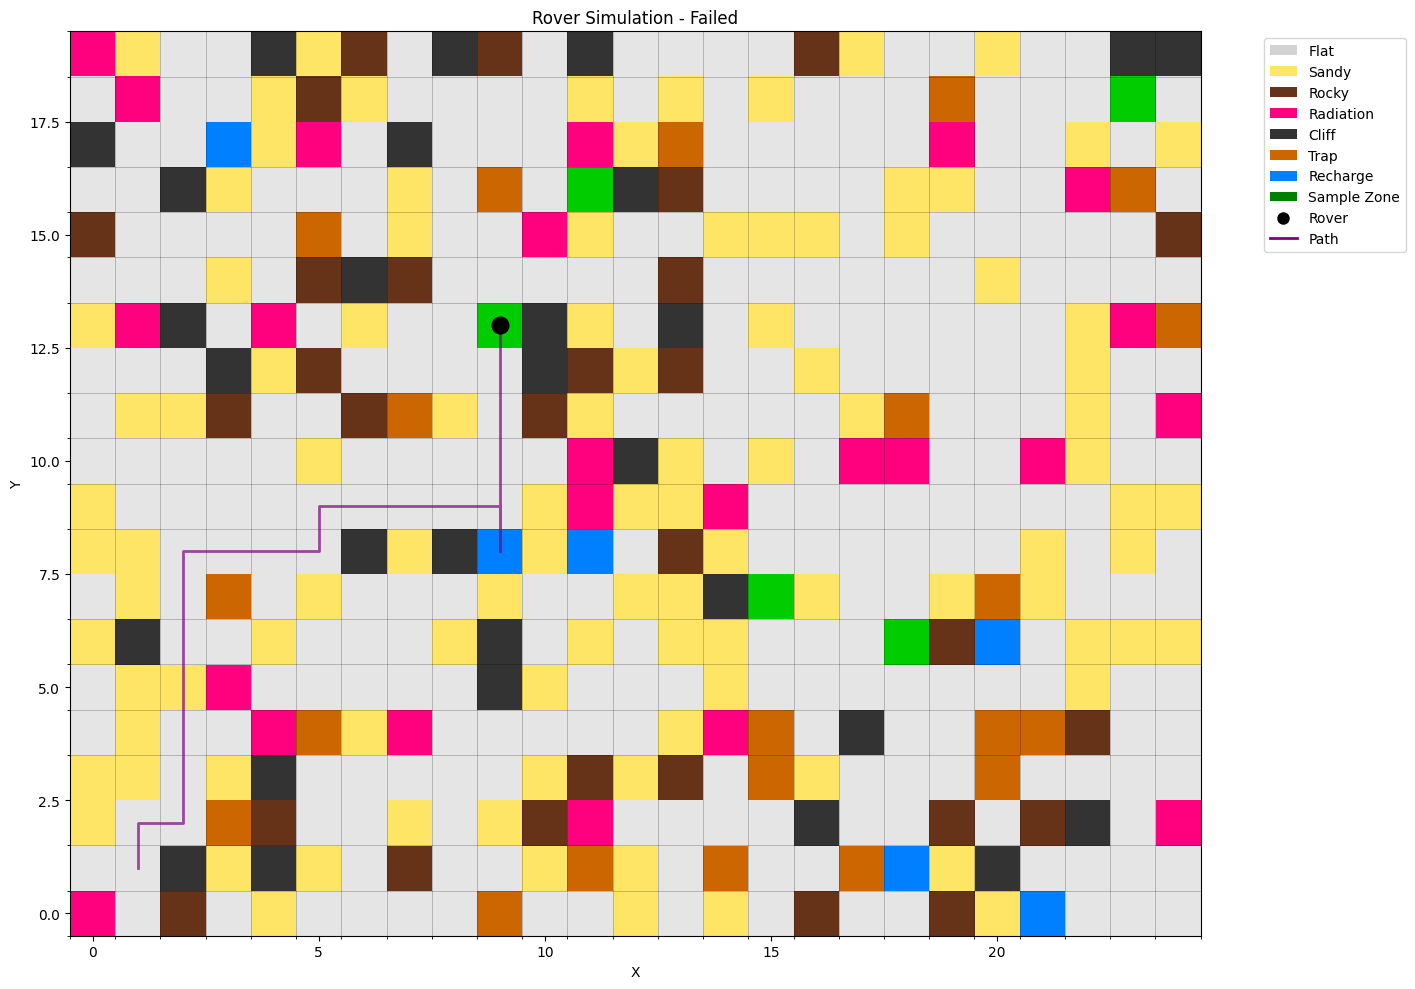

In [1]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional
import math

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # NEW: Impassable terrain
    TRAP = 7   # NEW: Dangerous terrain requiring backtracking

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.terrain = np.zeros((height, width), dtype=int)
        self.recharge_stations = []
        self.sample_zones = []

        # Enhanced movement costs
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,  # Impassable
            TerrainType.TRAP: 20  # High cost, triggers backtrack
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                self.sample_zones.append((x, y))

    def get_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.terrain[y, x])
        return TerrainType.CLIFF  # Out of bounds treated as cliff

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_terrain(x, y)
        # Cliffs and rocky terrain are impassable
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_terrain(x, y)
        return self.movement_costs[terrain]

    def generate_random_terrain(self):
        """Generate random terrain with new hazards"""
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:  # 8% rocky
                    self.set_terrain(x, y, TerrainType.ROCKY)
                elif rand < 0.12:  # 4% cliff
                    self.set_terrain(x, y, TerrainType.CLIFF)
                elif rand < 0.17:  # 5% trap
                    self.set_terrain(x, y, TerrainType.TRAP)
                elif rand < 0.22:  # 5% radiation
                    self.set_terrain(x, y, TerrainType.RADIATION)
                elif rand < 0.42:  # 20% sandy
                    self.set_terrain(x, y, TerrainType.SANDY)
                else:  # ~58% flat
                    self.set_terrain(x, y, TerrainType.FLAT)

        # Add recharge stations
        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        # Add sample zones
        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid
        self.state = None

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        terrain = self.grid.get_terrain(*position)

        # Find nearest recharge station
        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, goal: Tuple[int, int], visited_traps: set) -> str:
        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # Rule 1: If at hazardous terrain (radiation or trap), backtrack
        if terrain == TerrainType.RADIATION:
            return "backtrack_radiation"

        if terrain == TerrainType.TRAP and position not in visited_traps:
            return "backtrack_trap"

        # Rule 2: Critical battery - must recharge immediately
        if battery < 15:
            return "critical_recharge"

        # Rule 3: Low battery with station nearby
        if battery < 25 and station_distance <= 2:
            return "seek_recharge"

        # Rule 4: At recharge station and not full battery
        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        # Rule 5: At sample zone
        if terrain == TerrainType.SAMPLE_ZONE:
            return "collect_sample"

        # Default: continue exploration
        return "explore"

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        self.goal = None
        self.current_path = []
        self.path_index = 0

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0
        }

    def set_goal(self, goal: Tuple[int, int]):
        self.goal = goal

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target):
            return False

        cost = self.grid.get_movement_cost(*target)
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1:
            safe_pos = self.state.safe_positions[-2]
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                print(f"⚠️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position)
                print(f"⚠️  Trap detected! Backtracking to {safe_pos}")

    def recharge(self):
        terrain = self.grid.get_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"🔋 Recharged at {self.state.position}")

    def collect_sample(self):
        self.state.samples_collected += 1
        print(f"📦 Sample collected at {self.state.position} (Total: {self.state.samples_collected})")

    def simulate_step(self, heuristic_func) -> bool:
        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)
        action = self.reflex_agent.decide_action(percepts, self.goal, self.state.visited_traps)

        if action == "backtrack_radiation":
            self.backtrack("radiation")
            self.current_path = []  # Invalidate current path
            return True

        elif action == "backtrack_trap":
            self.backtrack("trap")
            self.current_path = []
            return True

        elif action == "recharge" or action == "critical_recharge":
            self.recharge()
            return True

        elif action == "collect_sample":
            self.collect_sample()
            if self.state.position == self.goal:
                return False  # Mission complete
            return True

        elif action == "seek_recharge":
            nearest_station = percepts['nearest_station']
            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])
            return False

        elif action == "explore":
            if not self.current_path or self.path_index >= len(self.current_path) - 1:
                self.current_path = self.plan_path(heuristic_func, self.state.position, self.goal)
                self.path_index = 0

            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

        return False

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        while steps < max_steps and self.state.position != self.goal:
            if not self.simulate_step(heuristic_func):
                if self.state.position == self.goal:
                    break
                return False
            steps += 1

            if self.state.position == self.goal:
                print(f"✅ Goal reached in {steps} steps!")
                return True

        if self.state.position != self.goal:
            print(f"❌ Simulation ended after {steps} steps. Goal not reached.")
        return self.state.position == self.goal

def create_sample_grid(width=25, height=20):
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and goal are accessible
    grid.set_terrain(1, 1, TerrainType.FLAT)
    grid.set_terrain(width-2, height-2, TerrainType.SAMPLE_ZONE)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid"):
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0]
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type = grid.terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type, [0.9, 0.9, 0.9])

    ax.imshow(color_array, origin='lower')

    if path:
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        ax.plot(path_x, path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    print("=== Enhanced Planetary Rover Simulation (Part 2) ===\n")

    grid = create_sample_grid()
    start_pos = (1, 1)
    goal_pos = (23, 18)

    rover = PlanetaryRover(grid, start_pos)
    rover.set_goal(goal_pos)

    print(f"Starting simulation with Weighted Euclidean heuristic...")
    success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=800)

    print(f"\n{'='*50}")
    print(f"Simulation Statistics:")
    print(f"{'='*50}")
    print(f"Success: {success}")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']:.2f}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Radiation encounters: {rover.stats['radiation_encounters']}")
    print(f"Trap encounters: {rover.stats['trap_encounters']}")
    print(f"Samples collected: {rover.state.samples_collected}")
    print(f"Nodes expanded: {rover.stats['nodes_expanded']}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"{'='*50}\n")

    visualize_grid(grid, rover.state.position, rover.state.path_history,
                  f"Rover Simulation - {'Success' if success else 'Failed'}")

**A_star Heuristics Comparison Report**


🚀 PLANETARY ROVER: A* HEURISTICS COMPARISON
Running 30 epochs for each of 4 heuristics...

📊 Testing: Manhattan
----------------------------------------------------------------------
❌ Simulation ended after 1000 steps. Goal not reached.
🔋 Recharged at (3, 8)
📦 Sample collected at (7, 11) (Total: 1)
📦 Sample collected at (7, 11) (Total: 2)
📦 Sample collected at (7, 11) (Total: 3)
📦 Sample collected at (7, 11) (Total: 4)
📦 Sample collected at (7, 11) (Total: 5)
📦 Sample collected at (7, 11) (Total: 6)
📦 Sample collected at (7, 11) (Total: 7)
📦 Sample collected at (7, 11) (Total: 8)
📦 Sample collected at (7, 11) (Total: 9)
📦 Sample collected at (7, 11) (Total: 10)
📦 Sample collected at (7, 11) (Total: 11)
📦 Sample collected at (7, 11) (Total: 12)
📦 Sample collected at (7, 11) (Total: 13)
📦 Sample collected at (7, 11) (Total: 14)
📦 Sample collected at (7, 11) (Total: 15)
📦 Sample collected at (7, 11) (Total: 16)
📦 Sample collected at (7, 11) (Total: 17)
📦 Sample collected at (7, 11) (Tot

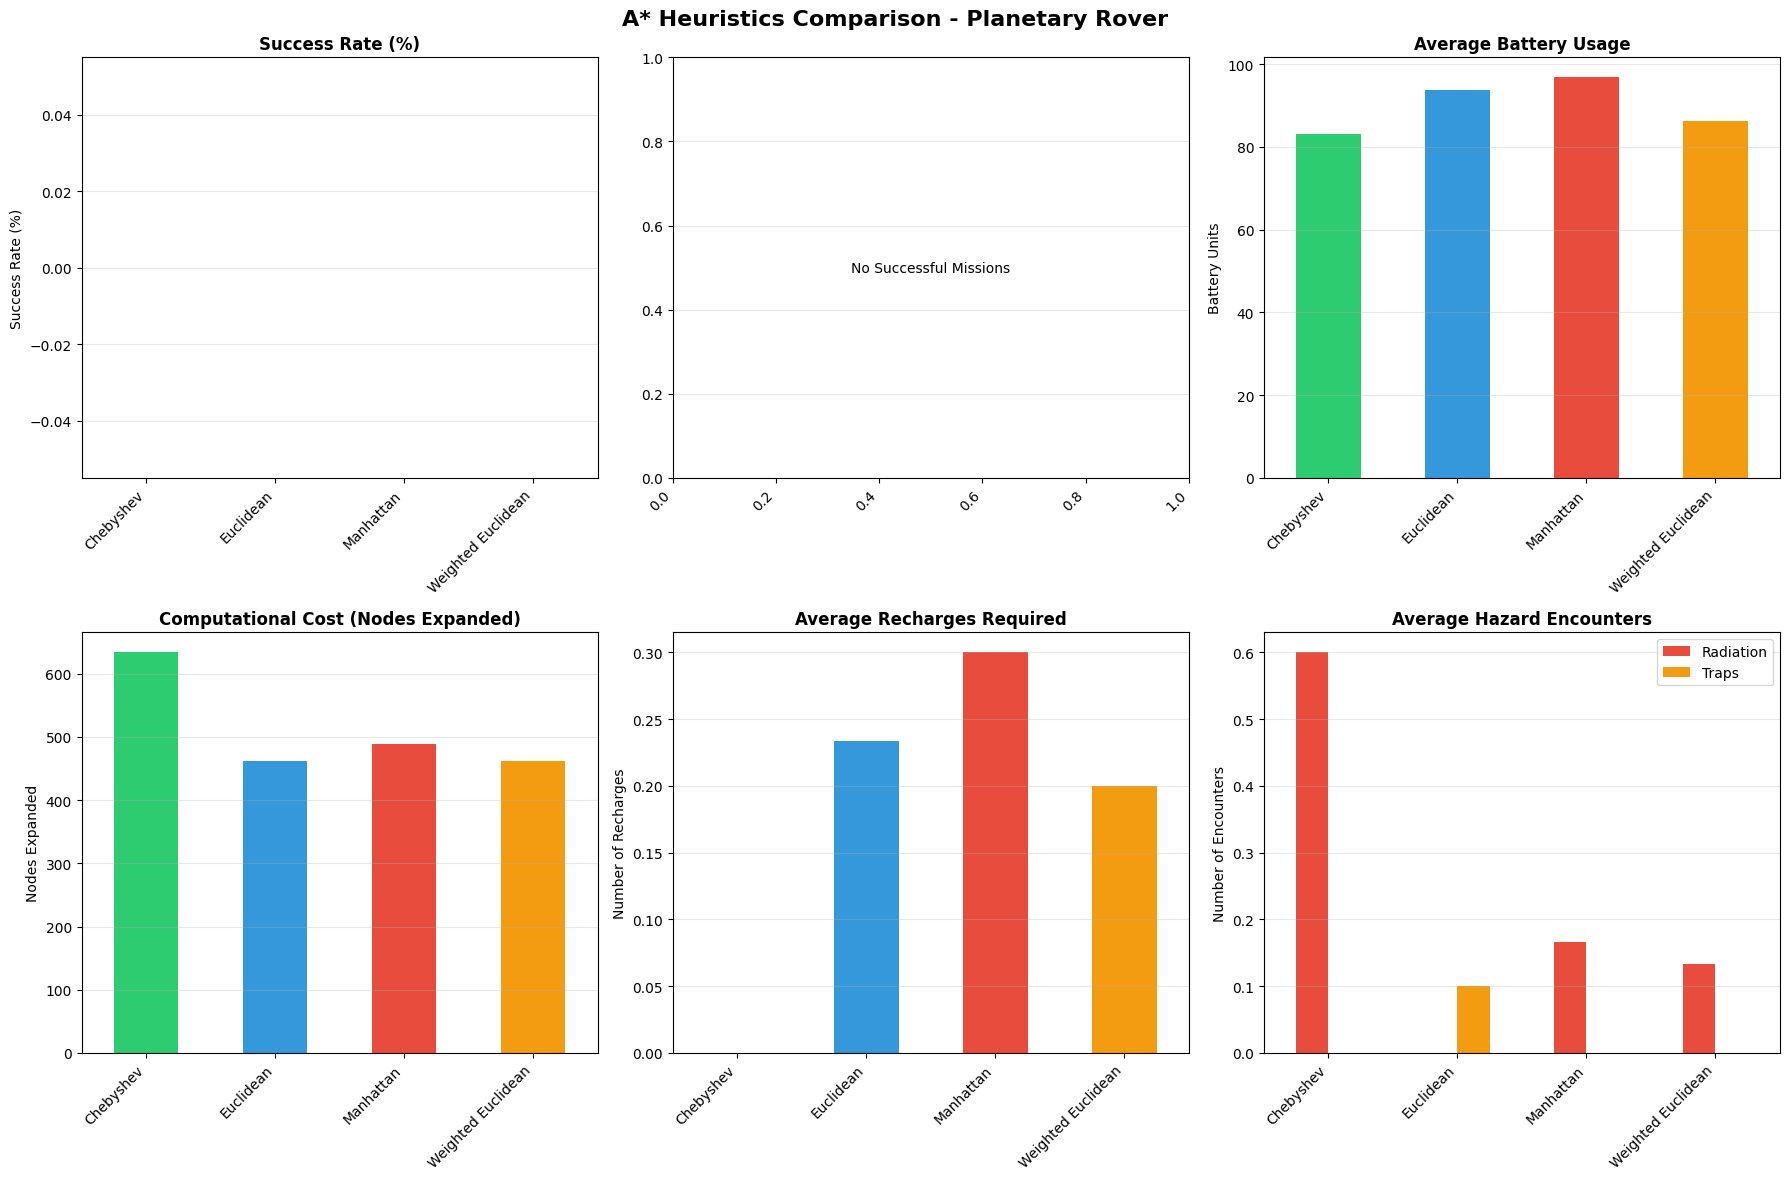


✅ Results saved to 'heuristic_comparison_results.csv'

📊 SUMMARY STATISTICS TABLE
                   Success  Moves  Battery_Used  Nodes_Expanded  Recharges  \
Heuristic                                                                    
Chebyshev             0.0%  13.97         83.17          633.97       0.00   
Euclidean             0.0%  16.83         93.67          462.47       0.23   
Manhattan             0.0%  17.67         96.83          488.60       0.30   
Weighted Euclidean    0.0%  15.57         86.17          462.47       0.20   

                    Backtracks  
Heuristic                       
Chebyshev                 0.60  
Euclidean                 0.10  
Manhattan                 0.17  
Weighted Euclidean        0.13  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Import from main implementation

def run_comparative_analysis(num_epochs=30, grid_size=(25, 20)):
    """
    Run comprehensive comparison of all four heuristics
    """
    heuristics = {
        "Manhattan": AStarHeuristics.manhattan_distance,
        "Euclidean": AStarHeuristics.euclidean_distance,
        "Chebyshev": AStarHeuristics.chebyshev_distance,
        "Weighted Euclidean": AStarHeuristics.weighted_euclidean
    }

    results = []

    print(f"Running {num_epochs} epochs for each of {len(heuristics)} heuristics...")
    print("="*70)

    for h_name, h_func in heuristics.items():
        print(f"\n📊 Testing: {h_name}")
        print("-"*70)

        for epoch in range(num_epochs):
            # Create fresh environment
            grid = create_sample_grid(*grid_size)
            start_pos = (1, 1)
            goal_pos = (grid_size[0]-2, grid_size[1]-2)

            grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
            grid.set_terrain(goal_pos[0], goal_pos[1], TerrainType.SAMPLE_ZONE)

            rover = PlanetaryRover(grid, start_pos)
            rover.set_goal(goal_pos)

            success = rover.run_simulation(h_func, max_steps=1000)

            results.append({
                'Heuristic': h_name,
                'Epoch': epoch + 1,
                'Success': success,
                'Moves': rover.stats['total_moves'],
                'Battery_Used': rover.stats['battery_used'],
                'Recharges': rover.stats['recharges'],
                'Backtracks': rover.stats['backtracks'],
                'Radiation_Encounters': rover.stats['radiation_encounters'],
                'Trap_Encounters': rover.stats['trap_encounters'],
                'Nodes_Expanded': rover.stats['nodes_expanded'],
                'Final_Battery': rover.state.battery,
                'Samples_Collected': rover.state.samples_collected
            })

            if (epoch + 1) % 10 == 0:
                print(f"  Completed {epoch + 1}/{num_epochs} epochs")

    return pd.DataFrame(results)

def generate_comparison_report(df: pd.DataFrame):
    """
    Generate comprehensive comparison statistics
    """
    print("\n" + "="*80)
    print("COMPARATIVE ANALYSIS REPORT")
    print("="*80)

    # Group by heuristic
    grouped = df.groupby('Heuristic')

    # Success rate
    print("\n1. SUCCESS RATE")
    print("-"*80)
    success_rates = grouped['Success'].mean() * 100
    for h_name, rate in success_rates.items():
        print(f"  {h_name:25s}: {rate:6.2f}%")

    # Average moves (for successful missions only)
    print("\n2. AVERAGE MOVES (Successful Missions Only)")
    print("-"*80)
    successful = df[df['Success'] == True]
    if len(successful) > 0:
        avg_moves = successful.groupby('Heuristic')['Moves'].mean()
        for h_name, moves in avg_moves.items():
            print(f"  {h_name:25s}: {moves:6.2f}")
    else:
        print("  No successful missions to analyze")

    # Battery efficiency
    print("\n3. BATTERY EFFICIENCY")
    print("-"*80)
    avg_battery = grouped['Battery_Used'].mean()
    for h_name, battery in avg_battery.items():
        print(f"  {h_name:25s}: {battery:6.2f} units")

    # Computational efficiency (nodes expanded)
    print("\n4. COMPUTATIONAL EFFICIENCY (Nodes Expanded)")
    print("-"*80)
    avg_nodes = grouped['Nodes_Expanded'].mean()
    for h_name, nodes in avg_nodes.items():
        print(f"  {h_name:25s}: {nodes:8.2f}")

    # Recharge frequency
    print("\n5. RECHARGE FREQUENCY")
    print("-"*80)
    avg_recharges = grouped['Recharges'].mean()
    for h_name, recharges in avg_recharges.items():
        print(f"  {h_name:25s}: {recharges:6.2f}")

    # Hazard encounters
    print("\n6. HAZARD ENCOUNTERS")
    print("-"*80)
    avg_radiation = grouped['Radiation_Encounters'].mean()
    avg_traps = grouped['Trap_Encounters'].mean()
    avg_backtracks = grouped['Backtracks'].mean()

    for h_name in df['Heuristic'].unique():
        print(f"  {h_name:25s}:")
        print(f"    Radiation: {avg_radiation[h_name]:6.2f}, Traps: {avg_traps[h_name]:6.2f}, Backtracks: {avg_backtracks[h_name]:6.2f}")

    print("\n" + "="*80)

    return {
        'success_rates': success_rates,
        'avg_moves': avg_moves if len(successful) > 0 else None,
        'avg_battery': avg_battery,
        'avg_nodes': avg_nodes,
        'avg_recharges': avg_recharges
    }

def plot_comparison_charts(df: pd.DataFrame, stats: Dict):
    """
    Create visualization plots
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('A* Heuristics Comparison - Planetary Rover', fontsize=16, fontweight='bold')

    # 1. Success Rate
    ax = axes[0, 0]
    stats['success_rates'].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    ax.set_title('Success Rate (%)', fontweight='bold')
    ax.set_ylabel('Success Rate (%)')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # 2. Average Moves
    ax = axes[0, 1]
    if stats['avg_moves'] is not None:
        stats['avg_moves'].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
        ax.set_title('Average Moves (Successful)', fontweight='bold')
        ax.set_ylabel('Number of Moves')
    else:
        ax.text(0.5, 0.5, 'No Successful Missions', ha='center', va='center', transform=ax.transAxes)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # 3. Battery Usage
    ax = axes[0, 2]
    stats['avg_battery'].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    ax.set_title('Average Battery Usage', fontweight='bold')
    ax.set_ylabel('Battery Units')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # 4. Nodes Expanded
    ax = axes[1, 0]
    stats['avg_nodes'].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    ax.set_title('Computational Cost (Nodes Expanded)', fontweight='bold')
    ax.set_ylabel('Nodes Expanded')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # 5. Recharge Frequency
    ax = axes[1, 1]
    stats['avg_recharges'].plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    ax.set_title('Average Recharges Required', fontweight='bold')
    ax.set_ylabel('Number of Recharges')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # 6. Hazard Encounters
    ax = axes[1, 2]
    hazard_data = df.groupby('Heuristic')[['Radiation_Encounters', 'Trap_Encounters']].mean()
    hazard_data.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12'])
    ax.set_title('Average Hazard Encounters', fontweight='bold')
    ax.set_ylabel('Number of Encounters')
    ax.set_xlabel('')
    ax.legend(['Radiation', 'Traps'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    """
    Main execution function
    """
    print("\n🚀 PLANETARY ROVER: A* HEURISTICS COMPARISON")
    print("="*80)

    # Run analysis
    df = run_comparative_analysis(num_epochs=30)

    # Generate report
    stats = generate_comparison_report(df)

    # Create visualizations
    plot_comparison_charts(df, stats)

    # Save results
    df.to_csv('heuristic_comparison_results.csv', index=False)
    print("\n✅ Results saved to 'heuristic_comparison_results.csv'")

    # Summary statistics
    print("\n📊 SUMMARY STATISTICS TABLE")
    print("="*80)
    summary = df.groupby('Heuristic').agg({
        'Success': lambda x: f"{x.mean()*100:.1f}%",
        'Moves': 'mean',
        'Battery_Used': 'mean',
        'Nodes_Expanded': 'mean',
        'Recharges': 'mean',
        'Backtracks': 'mean'
    }).round(2)
    print(summary)

    return df, stats

if __name__ == "__main__":
    df, stats = main()

# **Tried doing Reinforcement Learning on the rover**

# Task
Implement a "fog of war" mechanic in the planetary rover simulation, where the rover initially only knows its immediate surroundings. The rover should actively explore and map the terrain as it moves, gradually revealing unknown areas, and adapt its pathfinding based on its ever-expanding knowledge of the map.

## Dynamic Terrain and Unknown Areas

### Subtask:
Implement a 'fog of war' mechanic where the rover reveals terrain as it explores, and pathfinding adapts to the known map. The 'dynamic terrain' aspect (terrain types changing over time) is not covered in this subtask but can be added later.


**Reasoning**:
The subtask requires extensive modifications to multiple classes (`TerrainType`, `Grid`, `AStar`, `PlanetaryRover`) and the `visualize_grid` function to implement the 'fog of war' mechanic. I will provide a single code block with all the necessary changes, ensuring logical consistency and proper integration of the new features.



**Trying Reinforcement Learning**

=== Enhanced Planetary Rover Simulation (Part 2) ===

Starting simulation with Weighted Euclidean heuristic...
❌ Simulation ended after 800 steps. Goal not reached.

Simulation Statistics:
Success: False
Total moves: 18
Battery used: 90.00
Recharges: 0
Backtracks: 0
Radiation encounters: 0
Trap encounters: 0
Samples collected: 0
Nodes expanded: 418
Final battery: 10.00%



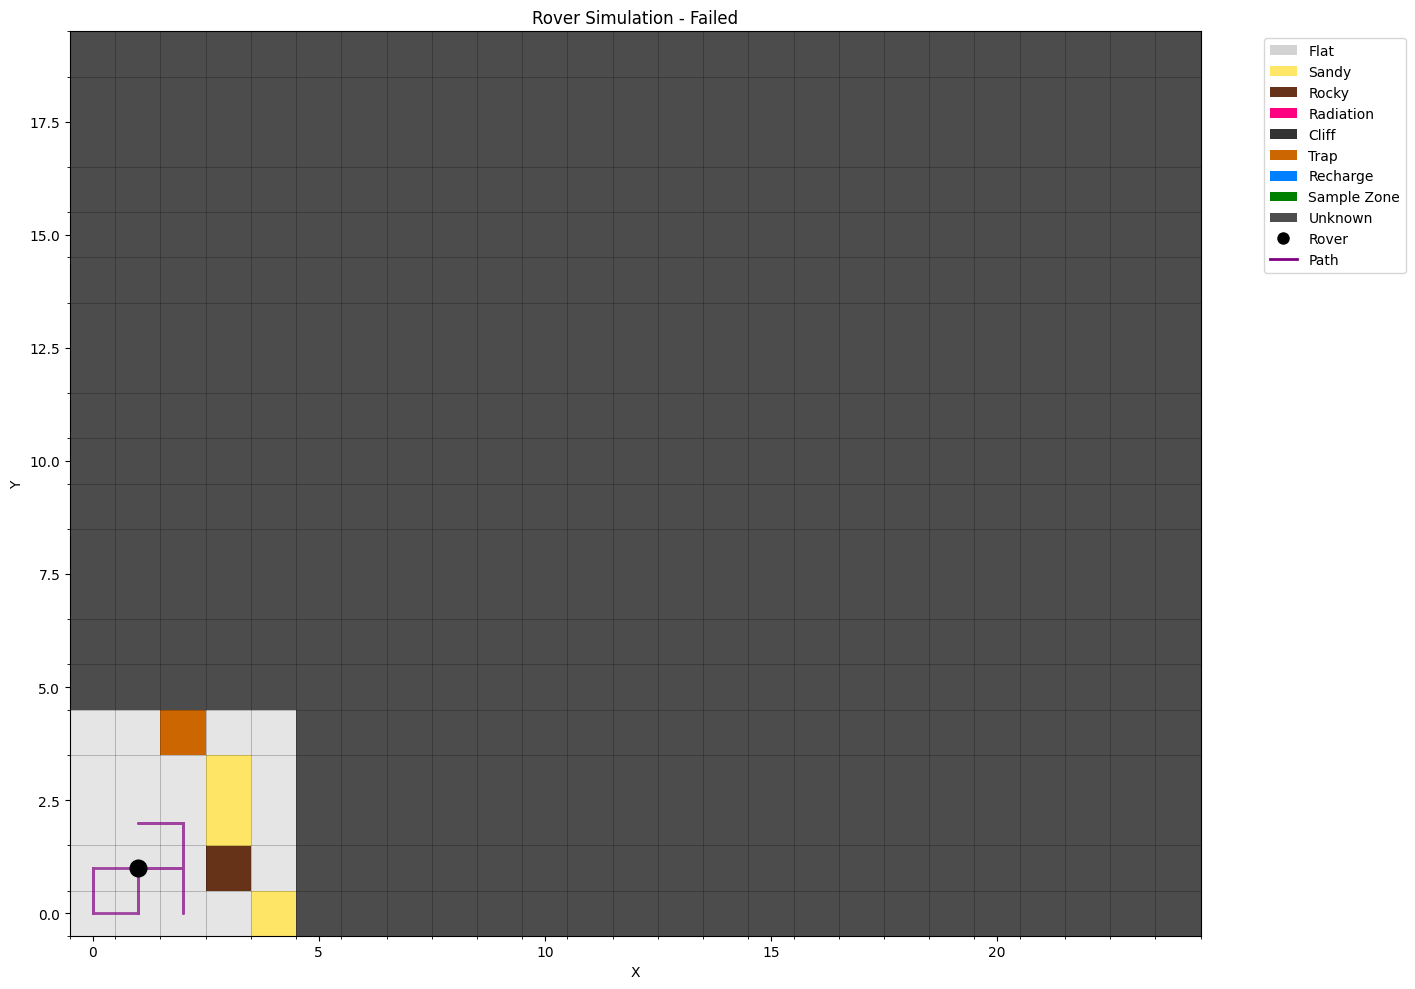

In [3]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional
import math

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # NEW: Impassable terrain
    TRAP = 7   # NEW: Dangerous terrain requiring backtracking
    UNKNOWN = 8 # NEW: Unobserved terrain

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int) # Renamed to actual_terrain
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int) # New: known terrain

        self.recharge_stations = []
        self.sample_zones = []

        # Enhanced movement costs
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,  # Impassable
            TerrainType.TRAP: 20,  # High cost, triggers backtrack
            TerrainType.UNKNOWN: 50 # Assume a higher cost for unknown to discourage random exploration
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value # Update actual_terrain
            if terrain_type == TerrainType.RECHARGE_STATION:
                self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                self.sample_zones.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType: # Renamed method
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF  # Out of bounds treated as cliff

    def get_known_terrain(self, x: int, y: int) -> TerrainType: # New method
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF # Out of bounds also a cliff in known terrain

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y) # Check actual terrain
        # Cliffs and rocky terrain are impassable
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool: # New method
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y) # Check known terrain
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y) # Use known terrain for cost calculation
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int): # New method
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        """Generate random terrain with new hazards"""
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:  # 8% rocky
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value # Populate actual_terrain
                elif rand < 0.12:  # 4% cliff
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value # Populate actual_terrain
                elif rand < 0.17:  # 5% trap
                    self.actual_terrain[y, x] = TerrainType.TRAP.value # Populate actual_terrain
                elif rand < 0.22:  # 5% radiation
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value # Populate actual_terrain
                elif rand < 0.42:  # 20% sandy
                    self.actual_terrain[y, x] = TerrainType.SANDY.value # Populate actual_terrain
                else:  # ~58% flat
                    self.actual_terrain[y, x] = TerrainType.FLAT.value # Populate actual_terrain

        # Add recharge stations
        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        # Add sample zones
        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y): # Use is_valid_for_planning
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        # Ensure start and goal are valid for planning in the known map
        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None
        # Note: goal might be unknown, but the path should lead *towards* it.
        # A* will only find paths through known terrain.
        # If the goal itself is UNKNOWN, A* will not reach it directly until it's revealed.
        # The exploration logic in Rover handles this by trying to find unknown cells.


        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid
        self.state = None

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        terrain = self.grid.get_actual_terrain(*position) # Percepts report actual terrain

        # Find nearest recharge station from the actual list
        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, goal: Tuple[int, int], visited_traps: set) -> str:
        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # Rule 1: If at hazardous terrain (radiation or trap), backtrack
        if terrain == TerrainType.RADIATION:
            return "backtrack_radiation"

        if terrain == TerrainType.TRAP and position not in visited_traps:
            return "backtrack_trap"

        # Rule 2: Critical battery - must recharge immediately
        if battery < 15:
            return "critical_recharge"

        # Rule 3: Low battery with station nearby
        if battery < 25 and station_distance <= 2:
            return "seek_recharge"

        # Rule 4: At recharge station and not full battery
        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        # Rule 5: At sample zone
        if terrain == TerrainType.SAMPLE_ZONE and position == goal: # Only collect if it's the goal sample zone
            return "collect_sample"

        # Default: continue exploration
        return "explore"

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        self.goal = None
        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2 # New attribute for fog of war

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0
        }

    def set_goal(self, goal: Tuple[int, int]):
        self.goal = goal

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        # First, ensure target is within actual bounds and not an actual impassable terrain
        if not self.grid.is_valid_position(*target):
            return False

        # Use actual terrain to determine cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target) # Check actual terrain for safety
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1:
            # Move to the previous safe position (not the current one)
            safe_pos = self.state.safe_positions.pop() # Remove current (hazardous) position
            safe_pos = self.state.safe_positions[-1] # Go to the truly last safe position

            # Simulate moving back without cost check, as it's an emergency
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                print(f"⚠️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
                print(f"⚠️  Trap detected! Backtracking to {safe_pos}")

    def recharge(self):
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"🔋 Recharged at {self.state.position}")

    def collect_sample(self):
        # Only collect a sample if it's the goal (as per reflex agent logic)
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE and self.state.position == self.goal:
            self.state.samples_collected += 1
            print(f"📦 Sample collected at {self.state.position} (Total: {self.state.samples_collected})")

    def simulate_step(self, heuristic_func) -> bool:
        # Reveal area around current position at the start of each step
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)
        action = self.reflex_agent.decide_action(percepts, self.goal, self.state.visited_traps)

        if action == "backtrack_radiation":
            self.backtrack("radiation")
            self.current_path = []  # Invalidate current path, replan needed
            return True

        elif action == "backtrack_trap":
            self.backtrack("trap")
            self.current_path = [] # Invalidate current path, replan needed
            return True

        elif action == "recharge" or action == "critical_recharge":
            self.recharge()
            return True

        elif action == "collect_sample":
            self.collect_sample()
            if self.state.position == self.goal:
                return False  # Mission complete
            return True # In case samples are collected in intermediate sample zones (not the final goal)

        elif action == "seek_recharge":
            nearest_station = percepts['nearest_station']
            if nearest_station: # If a station is known (it would be in actual_terrain, thus revealed)
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])
            return False # No path to recharge or cannot move

        elif action == "explore":
            # Check if current path is exhausted or needs replanning (e.g., due to newly revealed obstacles)
            if not self.current_path or self.path_index >= len(self.current_path) - 1 or \
               (self.current_path[self.path_index] != self.state.position):

                # Try to plan a path to the goal using currently known terrain
                planned_path = self.plan_path(heuristic_func, self.state.position, self.goal)
                if planned_path and len(planned_path) > 1:
                    self.current_path = planned_path
                    self.path_index = 0 # Start from the next step in the new path
                else:
                    # No path to goal on known terrain, explore unknown areas
                    return self._explore_unknown_area()

            # If a valid path exists and is not exhausted, follow it
            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

            # If path exhausted and goal not reached, explore unknown
            return self._explore_unknown_area()

        return False # No action taken or move failed

    def _explore_unknown_area(self) -> bool:
        # Prioritize moving to an adjacent UNKNOWN cell that is actually valid
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y): # Check actual validity before moving into UNKNOWN
                    possible_moves.append((new_x, new_y))

        # If unknown cells are available, pick one randomly
        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        # If no unknown cells to explore, try any known valid adjacent cell (fallback exploration)
        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y): # Check actual validity
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            # Filter out positions marked as visited traps for this exploration step
            filtered_fallback_moves = [move for move in fallback_moves if move not in self.state.visited_traps]
            if filtered_fallback_moves:
                target = random.choice(filtered_fallback_moves)
                return self.move_to_position(target)

        return False # No valid moves left for exploration

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        # Initial reveal at starting position
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.position != self.goal:
            if not self.simulate_step(heuristic_func):
                # If simulate_step returns False, it means either:
                #   1. Goal was reached (handled within simulate_step for 'collect_sample' action)
                #   2. No action could be taken (e.g., no path, no moves left, out of battery)
                # We need to explicitly check if the goal is reached after simulate_step
                if self.state.position == self.goal:
                    break # Goal reached successfully
                print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}.")
                return False # Indicate failure if stuck before goal
            steps += 1

            if self.state.position == self.goal:
                print(f"✅ Goal reached in {steps} steps!")
                return True

        if self.state.position != self.goal:
            print(f"❌ Simulation ended after {steps} steps. Goal not reached.")
        return self.state.position == self.goal

def create_sample_grid(width=25, height=20): # Adjusted default size for more complexity
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and goal are accessible and visible initially for the rover
    grid.set_terrain(1, 1, TerrainType.FLAT)
    grid.set_terrain(width-2, height-2, TerrainType.SAMPLE_ZONE)

    # Also ensure surrounding area of start and goal are flat to prevent immediate blockades
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            grid.set_terrain(1+dx, 1+dy, TerrainType.FLAT)
            grid.set_terrain(width-2+dx, height-2+dy, TerrainType.FLAT)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid"):
    """Visualize the grid with rover position and path, respecting fog of war"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9], # Light gray
        TerrainType.SANDY.value: [1.0, 0.9, 0.4], # Yellowish
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1], # Brown
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5], # Magenta
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0], # Blue
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0], # Green
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2], # Dark Gray
        TerrainType.TRAP.value: [0.8, 0.4, 0.0], # Orange-brown
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3] # Dark grey for unrevealed areas
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            # Use known_terrain for visualization
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5]) # Default to medium gray if unknown type

    ax.imshow(color_array, origin='lower')

    if path:
        # Draw path only if it's within known terrain (optional, for clearer visualization)
        known_path_x, known_path_y = [], []
        for p_x, p_y in path:
            if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN:
                known_path_x.append(p_x)
                known_path_y.append(p_y)
            else:
                # Stop drawing path if it goes into unknown area
                break
        ax.plot(known_path_x, known_path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown') # Added Unknown to legend
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    print("=== Enhanced Planetary Rover Simulation (Part 2) ===\n")

    grid = create_sample_grid()
    start_pos = (1, 1)
    goal_pos = (grid.width - 2, grid.height - 2) # Updated to use grid dimensions

    rover = PlanetaryRover(grid, start_pos)
    rover.set_goal(goal_pos)

    print(f"Starting simulation with Weighted Euclidean heuristic...")
    success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=800)

    print(f"\n{'='*50}")
    print(f"Simulation Statistics:")
    print(f"{'='*50}")
    print(f"Success: {success}")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']:.2f}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Radiation encounters: {rover.stats['radiation_encounters']}")
    print(f"Trap encounters: {rover.stats['trap_encounters']}")
    print(f"Samples collected: {rover.state.samples_collected}")
    print(f"Nodes expanded: {rover.stats['nodes_expanded']}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"{'='*50}\n")

    visualize_grid(grid, rover.state.position, rover.state.path_history,
                  f"Rover Simulation - {'Success' if success else 'Failed'}")


## Advanced Resource Management

### Subtask:
Expand beyond just battery to include consumable resources like 'repair kits' for traps and 'radiation shields' for radiation, adding a strategic layer to resource allocation and path planning.


**Reasoning**:
The subtask requires modifications to `RoverState`, `PlanetaryRover`, and `ReflexAgent` classes to implement the new resource management (repair kits and radiation shields). I will include these changes in a single code block, along with the updated `visualize_grid` function and the main execution block, to ensure logical consistency and proper integration of the new features.



=== Enhanced Planetary Rover Simulation (Part 2) ===

Starting simulation with Weighted Euclidean heuristic...
❌ Simulation ended after 800 steps. Goal not reached.

Simulation Statistics:
Success: False
Total moves: 16
Battery used: 90.00
Recharges: 0
Backtracks: 0
Radiation encounters: 0
Trap encounters: 0
Repair kits used: 0
Radiation shields used: 0
Samples collected: 0
Nodes expanded: 315
Final battery: 10.00%
Remaining repair kits: 2
Remaining radiation shields: 1



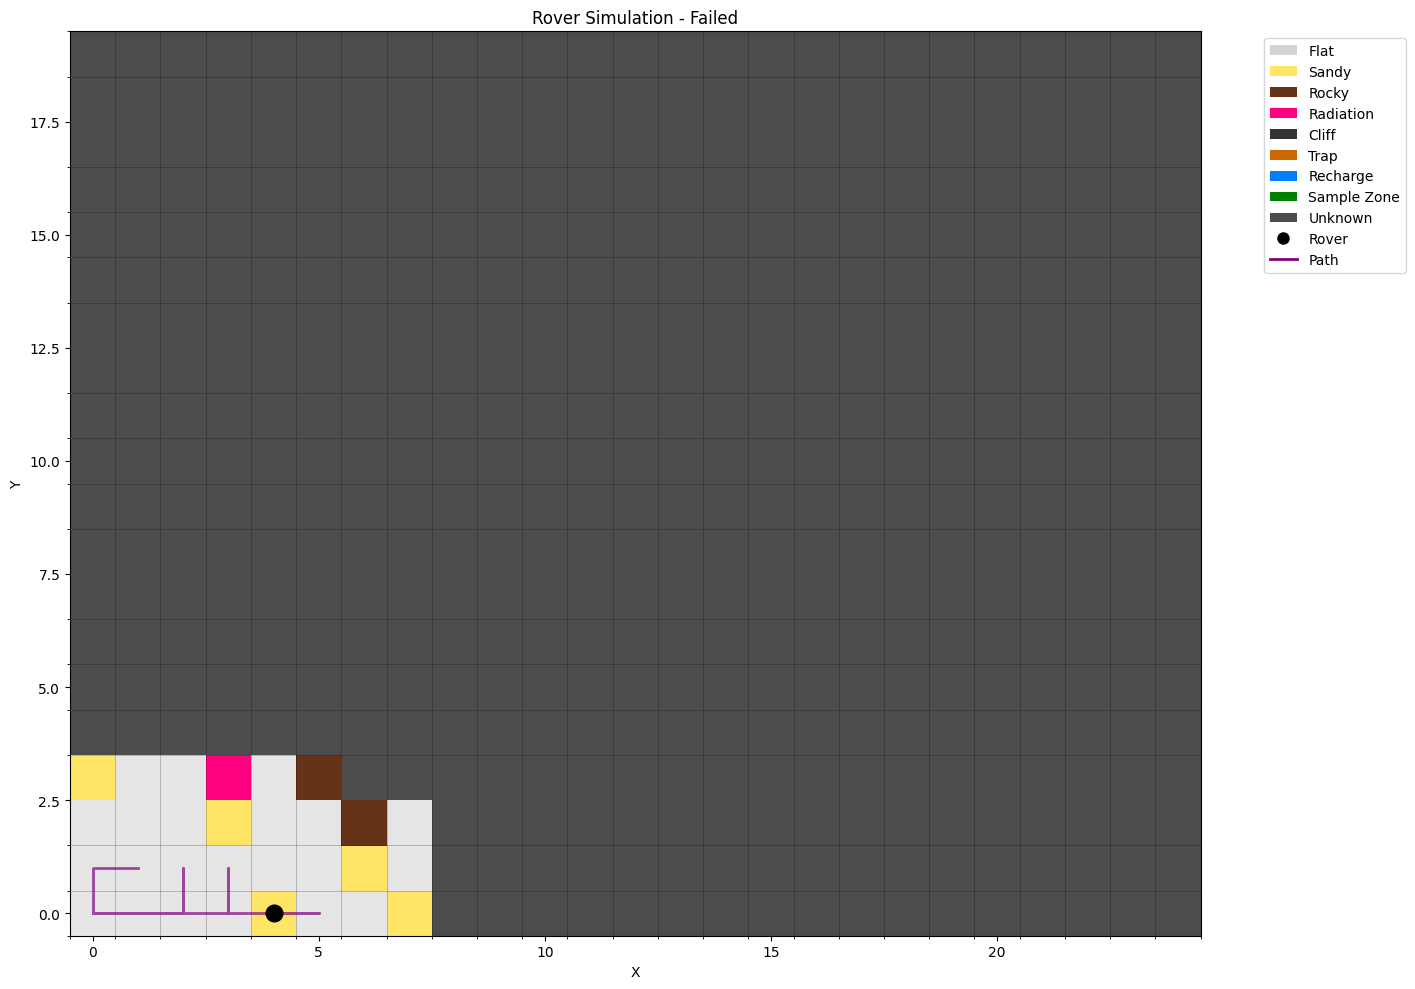

In [4]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional
import math

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # NEW: Impassable terrain
    TRAP = 7   # NEW: Dangerous terrain requiring backtracking
    UNKNOWN = 8 # NEW: Unobserved terrain

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2  # NEW: Repair kits
        self.radiation_shields: int = 1 # NEW: Radiation shields

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int) # Renamed to actual_terrain
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int) # New: known terrain

        self.recharge_stations = []
        self.sample_zones = []

        # Enhanced movement costs
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,  # Impassable
            TerrainType.TRAP: 20,  # High cost, triggers backtrack
            TerrainType.UNKNOWN: 50 # Assume a higher cost for unknown to discourage random exploration
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value # Update actual_terrain
            if terrain_type == TerrainType.RECHARGE_STATION:
                self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                self.sample_zones.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType: # Renamed method
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF  # Out of bounds treated as cliff

    def get_known_terrain(self, x: int, y: int) -> TerrainType: # New method
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF # Out of bounds also a cliff in known terrain

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y) # Check actual terrain
        # Cliffs and rocky terrain are impassable
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool: # New method
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y) # Check known terrain
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y) # Use known terrain for cost calculation
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int): # New method
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        """Generate random terrain with new hazards"""
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:  # 8% rocky
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value # Populate actual_terrain
                elif rand < 0.12:  # 4% cliff
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value # Populate actual_terrain
                elif rand < 0.17:  # 5% trap
                    self.actual_terrain[y, x] = TerrainType.TRAP.value # Populate actual_terrain
                elif rand < 0.22:  # 5% radiation
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value # Populate actual_terrain
                elif rand < 0.42:  # 20% sandy
                    self.actual_terrain[y, x] = TerrainType.SANDY.value # Populate actual_terrain
                else:  # ~58% flat
                    self.actual_terrain[y, x] = TerrainType.FLAT.value # Populate actual_terrain

        # Add recharge stations
        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        # Add sample zones
        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y): # Use is_valid_for_planning
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        # Ensure start and goal are valid for planning in the known map
        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None
        # Note: goal might be unknown, but the path should lead *towards* it.
        # A* will only find paths through known terrain.
        # If the goal itself is UNKNOWN, A* will not reach it directly until it's revealed.
        # The exploration logic in Rover handles this by trying to find unknown cells.


        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid
        self.state = None

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        terrain = self.grid.get_actual_terrain(*position) # Percepts report actual terrain

        # Find nearest recharge station from the actual list
        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, goal: Tuple[int, int], visited_traps: set,
                      repair_kits: int, radiation_shields: int) -> str: # UPDATED signature
        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # Rule 1a: If at Radiation and has a shield, use it
        if terrain == TerrainType.RADIATION:
            if radiation_shields > 0:
                return "use_radiation_shield"
            else:
                return "backtrack_radiation"

        # Rule 1b: If at a new Trap and has a repair kit, use it
        if terrain == TerrainType.TRAP and position not in visited_traps:
            if repair_kits > 0:
                return "use_repair_kit"
            else:
                return "backtrack_trap"

        # Rule 2: Critical battery - must recharge immediately
        if battery < 15:
            return "critical_recharge"

        # Rule 3: Low battery with station nearby
        if battery < 25 and station_distance <= 2:
            return "seek_recharge"

        # Rule 4: At recharge station and not full battery
        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        # Rule 5: At sample zone
        if terrain == TerrainType.SAMPLE_ZONE and position == goal: # Only collect if it's the goal sample zone
            return "collect_sample"

        # Default: continue exploration
        return "explore"

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        self.goal = None
        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2 # New attribute for fog of war

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0, # NEW stat
            'radiation_shields_used': 0 # NEW stat
        }

    def set_goal(self, goal: Tuple[int, int]):
        self.goal = goal

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        # First, ensure target is within actual bounds and not an actual impassable terrain
        if not self.grid.is_valid_position(*target):
            return False

        # Use actual terrain to determine cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target) # Check actual terrain for safety
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1:
            # Move to the previous safe position (not the current one)
            # Pop the current, hazardous position from safe_positions if it was added there somehow
            if self.state.safe_positions[-1] == self.state.position: # Only pop if current is at the end
                self.state.safe_positions.pop()

            safe_pos = self.state.safe_positions[-1] # Go to the truly last safe position

            # Simulate moving back without cost check, as it's an emergency
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                print(f"⚠️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
                print(f"⚠️  Trap detected! Backtracking to {safe_pos}")

    def recharge(self):
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"🔋 Recharged at {self.state.position}")

    def collect_sample(self):
        # Only collect a sample if it's the goal (as per reflex agent logic)
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE and self.state.position == self.goal:
            self.state.samples_collected += 1
            print(f"📦 Sample collected at {self.state.position} (Total: {self.state.samples_collected})")

    def use_radiation_shield(self):
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            print(f"🛡️ Used radiation shield at {self.state.position}. {self.state.radiation_shields} shields remaining.")
            # The rover can now effectively move through this radiation tile without penalty for this step/turn
            # The terrain itself doesn't change, but the rover's state allows passage.
            # We prevent backtracking in this specific simulate_step call by returning True.

    def use_repair_kit(self):
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            print(f"🔧 Used repair kit at {self.state.position}. {self.state.repair_kits} kits remaining.")
            # Neutralize the trap by updating the known terrain and removing it from visited_traps
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)


    def simulate_step(self, heuristic_func) -> bool:
        # Reveal area around current position at the start of each step
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)
        action = self.reflex_agent.decide_action(percepts, self.goal, self.state.visited_traps,
                                                  self.state.repair_kits, self.state.radiation_shields) # UPDATED call

        if action == "backtrack_radiation":
            self.backtrack("radiation")
            self.current_path = []  # Invalidate current path, replan needed
            return True

        elif action == "backtrack_trap":
            self.backtrack("trap")
            self.current_path = [] # Invalidate current path, replan needed
            return True

        elif action == "use_radiation_shield": # NEW action
            self.use_radiation_shield()
            # After using a shield, the rover effectively bypasses the hazard for this step.
            # It should then re-evaluate its next move, perhaps trying to move through the radiation.
            # For simplicity, we just return True and let the next simulate_step decide or proceed.
            # If it's still in the path, it might try to traverse it next.
            return True

        elif action == "use_repair_kit": # NEW action
            self.use_repair_kit()
            # After repairing, the cell is now flat and safe. The rover can now attempt to re-plan or move.
            return True

        elif action == "recharge" or action == "critical_recharge":
            self.recharge()
            return True

        elif action == "collect_sample":
            self.collect_sample()
            if self.state.position == self.goal:
                return False  # Mission complete
            return True # In case samples are collected in intermediate sample zones (not the final goal)

        elif action == "seek_recharge":
            nearest_station = percepts['nearest_station']
            if nearest_station: # If a station is known (it would be in actual_terrain, thus revealed)
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])
            return False # No path to recharge or cannot move

        elif action == "explore":
            # Check if current path is exhausted or needs replanning (e.g., due to newly revealed obstacles)
            if not self.current_path or self.path_index >= len(self.current_path) - 1 or \
               (self.current_path and self.current_path[self.path_index] != self.state.position):

                # Try to plan a path to the goal using currently known terrain
                planned_path = self.plan_path(heuristic_func, self.state.position, self.goal)
                if planned_path and len(planned_path) > 1:
                    self.current_path = planned_path
                    self.path_index = 0 # Start from the next step in the new path
                else:
                    # No path to goal on known terrain, explore unknown areas
                    return self._explore_unknown_area()

            # If a valid path exists and is not exhausted, follow it
            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

            # If path exhausted and goal not reached, explore unknown
            return self._explore_unknown_area()

        return False # No action taken or move failed

    def _explore_unknown_area(self) -> bool:
        # Prioritize moving to an adjacent UNKNOWN cell that is actually valid
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y): # Check actual validity before moving into UNKNOWN
                    possible_moves.append((new_x, new_y))

        # If unknown cells are available, pick one randomly
        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        # If no unknown cells to explore, try any known valid adjacent cell (fallback exploration)
        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y): # Check actual validity
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            # Filter out positions marked as visited traps for this exploration step
            filtered_fallback_moves = [move for move in fallback_moves if move not in self.state.visited_traps]
            if filtered_fallback_moves:
                target = random.choice(filtered_fallback_moves)
                return self.move_to_position(target)

        return False # No valid moves left for exploration

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        # Initial reveal at starting position
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.position != self.goal:
            if not self.simulate_step(heuristic_func):
                # If simulate_step returns False, it means either:
                #   1. Goal was reached (handled within simulate_step for 'collect_sample' action)
                #   2. No action could be taken (e.g., no path, no moves left, out of battery)
                # We need to explicitly check if the goal is reached after simulate_step
                if self.state.position == self.goal:
                    break # Goal reached successfully
                print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}.")
                return False # Indicate failure if stuck before goal
            steps += 1

            if self.state.position == self.goal:
                print(f"✅ Goal reached in {steps} steps!")
                return True

        if self.state.position != self.goal:
            print(f"❌ Simulation ended after {steps} steps. Goal not reached.")
        return self.state.position == self.goal

def create_sample_grid(width=25, height=20):
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and goal are accessible and visible initially for the rover
    grid.set_terrain(1, 1, TerrainType.FLAT)
    grid.set_terrain(width-2, height-2, TerrainType.SAMPLE_ZONE)

    # Also ensure surrounding area of start and goal are flat to prevent immediate blockades
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= 1+dx < grid.width and 0 <= 1+dy < grid.height:
                grid.set_terrain(1+dx, 1+dy, TerrainType.FLAT)
            if 0 <= width-2+dx < grid.width and 0 <= height-2+dy < grid.height:
                grid.set_terrain(width-2+dx, height-2+dy, TerrainType.FLAT)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid"):
    """Visualize the grid with rover position and path, respecting fog of war"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9], # Light gray
        TerrainType.SANDY.value: [1.0, 0.9, 0.4], # Yellowish
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1], # Brown
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5], # Magenta
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0], # Blue
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0], # Green
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2], # Dark Gray
        TerrainType.TRAP.value: [0.8, 0.4, 0.0], # Orange-brown
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3] # Dark grey for unrevealed areas
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            # Use known_terrain for visualization
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5]) # Default to medium gray if unknown type

    ax.imshow(color_array, origin='lower')

    if path:
        # Draw path only if it's within known terrain (optional, for clearer visualization)
        known_path_x, known_path_y = [], []
        for p_x, p_y in path:
            # Only add path points if they are within the known map OR if it's the rover's current position
            if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                known_path_x.append(p_x)
                known_path_y.append(p_y)
            else:
                # Stop drawing path if it goes into unknown area, to emphasize current knowledge
                break
        ax.plot(known_path_x, known_path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown') # Added Unknown to legend
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    print("=== Enhanced Planetary Rover Simulation (Part 2) ===\n")

    grid = create_sample_grid()
    start_pos = (1, 1)
    goal_pos = (grid.width - 2, grid.height - 2) # Updated to use grid dimensions

    rover = PlanetaryRover(grid, start_pos)
    rover.set_goal(goal_pos)

    print(f"Starting simulation with Weighted Euclidean heuristic...")
    success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=800)

    print(f"\n{'='*50}")
    print(f"Simulation Statistics:")
    print(f"{'='*50}")
    print(f"Success: {success}")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']:.2f}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Radiation encounters: {rover.stats['radiation_encounters']}")
    print(f"Trap encounters: {rover.stats['trap_encounters']}")
    print(f"Repair kits used: {rover.stats['repair_kits_used']}") # NEW stat
    print(f"Radiation shields used: {rover.stats['radiation_shields_used']}") # NEW stat
    print(f"Samples collected: {rover.state.samples_collected}")
    print(f"Nodes expanded: {rover.stats['nodes_expanded']}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}") # NEW stat
    print(f"Remaining radiation shields: {rover.state.radiation_shields}") # NEW stat
    print(f"{'='*50}\n")

    visualize_grid(grid, rover.state.position, rover.state.path_history,
                  f"Rover Simulation - {'Success' if success else 'Failed'}")


## Multi-Objective Mission Planning

### Subtask:
Design missions with multiple objectives (e.g., collect N samples, visit K points, then return to base, all within a time limit). The rover needs to prioritize tasks and optimize its route for efficiency across multiple goals.


**Reasoning**:
The subtask requires extensive modifications to multiple classes and functions to implement multi-objective mission planning and a base station. A single, comprehensive code block is necessary to ensure all changes are integrated correctly and logically consistent, avoiding fragmentation and potential errors.



**Reasoning**:
The previous code block failed due to an incomplete f-string in the `visualize_grid` function. I need to complete the f-string to properly display the objective position in the plot legend.



=== Enhanced Planetary Rover Simulation (Part 2) ===

Starting simulation with Weighted Euclidean heuristic...
❌ Simulation ended after 1500 steps. Mission not completed.

Simulation Statistics:
Mission Success: False
Total objectives completed: 0
Total moves: 17
Battery used: 90.00
Recharges: 0
Backtracks: 0
Radiation encounters: 0
Trap encounters: 0
Repair kits used: 0
Radiation shields used: 0
Samples collected: 0
Nodes expanded: 353
Final battery: 10.00%
Remaining repair kits: 2
Remaining radiation shields: 1



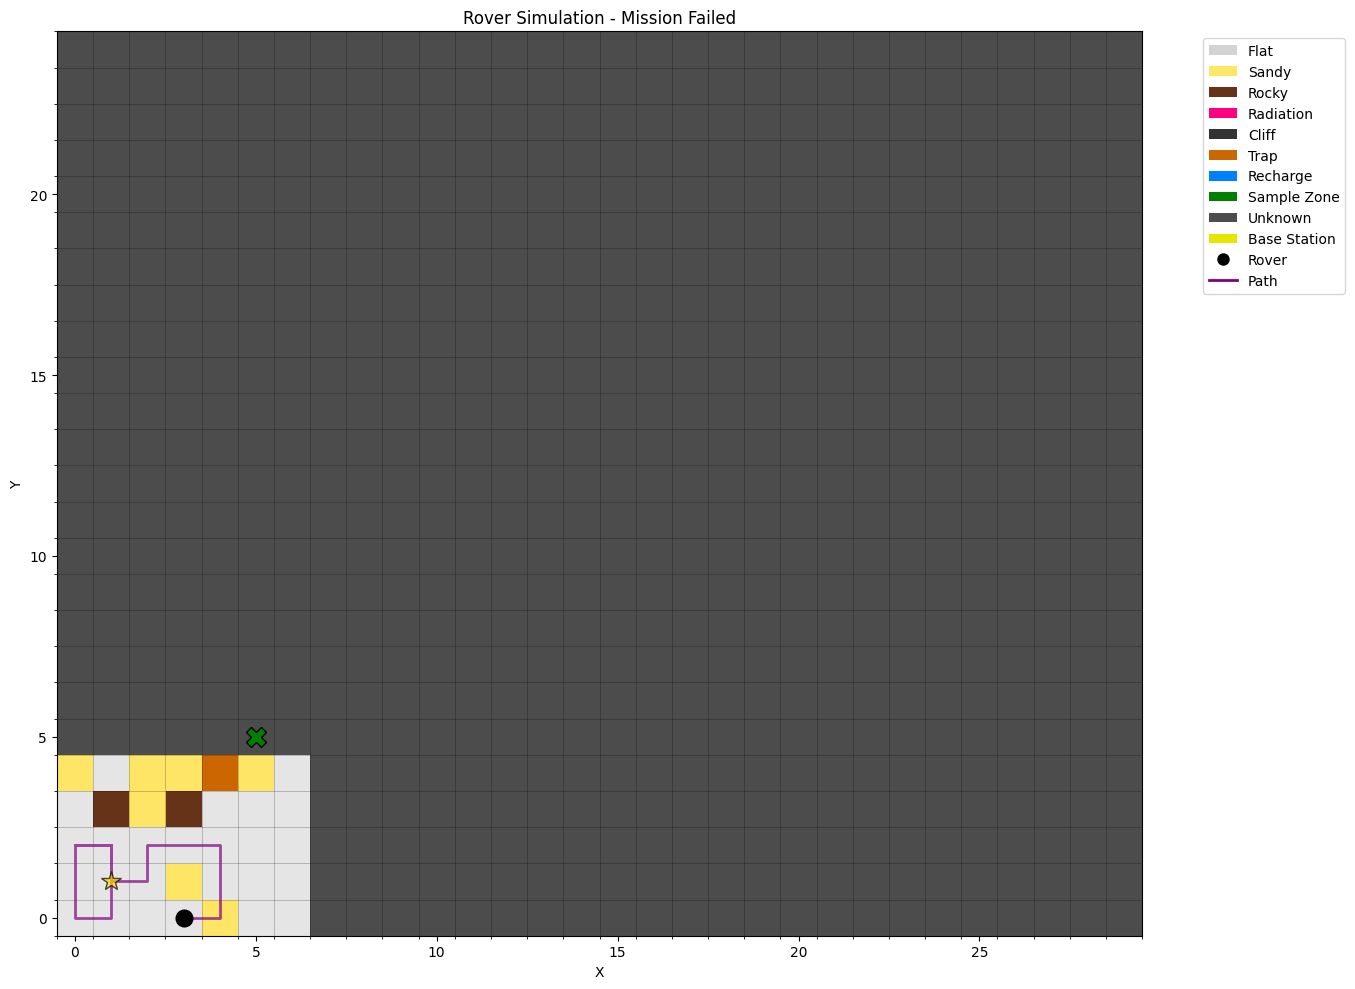

In [5]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set
import math

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # NEW: Impassable terrain
    TRAP = 7   # NEW: Dangerous terrain requiring backtracking
    UNKNOWN = 8 # NEW: Unobserved terrain
    BASE_STATION = 9 # NEW: Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        # NEW: Multi-objective mission planning attributes
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set() # Track visited generic points

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = [] # NEW: List to store base stations

        # Enhanced movement costs
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5 # NEW: Movement cost for base station
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations: # Avoid duplicates
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones: # Avoid duplicates
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION: # NEW: Handle base station
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        # Rover cannot plan through unknown, rocky, or cliff areas
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        terrain = self.grid.get_actual_terrain(*position)

        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, current_objective_pos: Tuple[int, int], # MODIFIED signature
                      current_objective_type: TerrainType, visited_traps: Set[Tuple[int, int]],
                      repair_kits: int, radiation_shields: int) -> str: # MODIFIED signature

        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # NEW: Check if current position is the current objective
        if position == current_objective_pos:
            if current_objective_type == TerrainType.SAMPLE_ZONE:
                return "collect_sample"
            elif current_objective_type == TerrainType.BASE_STATION:
                return "mission_completed" # Signal for mission end
            else: # Generic visit point (TerrainType.FLAT)
                return "objective_completed"

        # Existing hazard handling with resource management
        if terrain == TerrainType.RADIATION:
            if radiation_shields > 0:
                return "use_radiation_shield"
            else:
                return "backtrack_radiation"

        if terrain == TerrainType.TRAP and position not in visited_traps:
            if repair_kits > 0:
                return "use_repair_kit"
            else:
                return "backtrack_trap"

        if battery < 15:
            return "critical_recharge"

        if battery < 25 and station_distance <= 2:
            return "seek_recharge"

        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        return "explore"

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        # self.goal = None # REMOVED: Mission driven by objectives list
        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0, # NEW: Track total samples collected
            'objectives_completed': 0 # NEW: Track objectives completed
        }

    # MODIFIED: Renamed and changed signature
    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        # Ensure the mission ends at the base station (initial position)
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target):
            return False

        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]: # Safe positions should not include radiation/trap squares
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1:
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            safe_pos = self.state.safe_positions[-1] # Go to the truly last safe position
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                print(f"⚠️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position)
                print(f"⚠️  Trap detected! Backtracking to {safe_pos}")

    def recharge(self):
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"🔋 Recharged at {self.state.position}")

    def collect_sample(self):
        self.stats['samples_collected'] += 1 # NEW: Use stats for samples
        print(f"📦 Sample collected at {self.state.position} (Total: {self.stats['samples_collected']})")

    def use_radiation_shield(self):
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            print(f"🛡️ Used radiation shield at {self.state.position}. {self.state.radiation_shields} shields remaining.")

    def use_repair_kit(self):
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            print(f"🔧 Used repair kit at {self.state.position}. {self.state.repair_kits} kits remaining.")
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)


    def simulate_step(self, heuristic_func) -> bool:
        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False # Mission completed

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)
        action = self.reflex_agent.decide_action(percepts, current_objective_pos, current_objective_type,
                                                  self.state.visited_traps, self.state.repair_kits, self.state.radiation_shields)

        if action == "mission_completed": # NEW: Handle mission completion
            self.stats['objectives_completed'] += 1
            self.state.current_objective_index += 1
            print(f"🏠 Arrived at Base Station: Mission Complete!")
            return False # Signal mission completion

        if action == "objective_completed": # NEW: Handle generic visit points
            if current_objective_pos not in self.state.visit_points_visited:
                self.state.visit_points_visited.add(current_objective_pos)
                self.stats['objectives_completed'] += 1
                print(f"🎯 Visited point {current_objective_pos}. Moving to next objective.")
            self.state.current_objective_index += 1
            self.current_path = [] # Force replan
            return True

        if action == "collect_sample": # NEW: Handle sample collection objective
            self.collect_sample()
            self.stats['objectives_completed'] += 1
            self.state.current_objective_index += 1
            self.current_path = [] # Force replan
            print(f"📦 Collected sample at {current_objective_pos}. Moving to next objective.")
            return True

        elif action == "backtrack_radiation":
            self.backtrack("radiation")
            self.current_path = []
            return True

        elif action == "backtrack_trap":
            self.backtrack("trap")
            self.current_path = []
            return True

        elif action == "use_radiation_shield":
            self.use_radiation_shield()
            # After using shield, the rover is still on the radiation tile, but can proceed. Re-evaluate action.
            # For now, we return True and the next step will decide if it can move through.
            # A more sophisticated agent might re-plan immediately through this now-mitigated tile.
            return True

        elif action == "use_repair_kit":
            self.use_repair_kit()
            # After repairing, the tile is safe (flat). The rover should now be able to plan through it.
            self.current_path = [] # Force replan with updated terrain knowledge
            return True

        elif action == "recharge" or action == "critical_recharge":
            self.recharge()
            return True

        elif action == "seek_recharge":
            nearest_station = percepts['nearest_station']
            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])
            return False

        elif action == "explore":
            # Plan path to current objective
            if not self.current_path or self.path_index >= len(self.current_path) - 1 or \
               self.current_path[self.path_index] != self.state.position:

                planned_path = self.plan_path(heuristic_func, self.state.position, current_objective_pos)
                if planned_path and len(planned_path) > 1: # Path exists and is more than just current position
                    self.current_path = planned_path
                    self.path_index = 0
                else:
                    # No clear path to objective, try to explore unknown areas
                    return self._explore_unknown_area()

            # If a valid path exists and is not exhausted, follow it
            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

            # If path exhausted (or it was just current pos) and goal not reached, explore unknown
            return self._explore_unknown_area()

        return False

    def _explore_unknown_area(self) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y):
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y):
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            # Filter out positions marked as visited traps for this exploration step
            # Also avoid radiation if no shield available
            filtered_fallback_moves = []
            for move in fallback_moves:
                actual_terrain = self.grid.get_actual_terrain(*move)
                if move in self.state.visited_traps: # Don't go back into known traps unless repaired
                    continue
                if actual_terrain == TerrainType.RADIATION and self.state.radiation_shields == 0: # Avoid unshielded radiation
                    continue
                filtered_fallback_moves.append(move)

            if filtered_fallback_moves:
                target = random.choice(filtered_fallback_moves)
                return self.move_to_position(target)

        return False

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives): # MODIFIED loop condition
            if not self.simulate_step(heuristic_func):
                if self.state.current_objective_index >= len(self.state.mission_objectives):
                    break # Mission completed
                print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}.")
                return False
            steps += 1

        mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)
        if mission_success:
            print(f"✅ Mission completed in {steps} steps!")
        else:
            print(f"❌ Simulation ended after {steps} steps. Mission not completed.")
        return mission_success

def create_sample_grid(width=25, height=20):
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    start_pos = (1, 1)
    base_pos = (width - 2, height - 2) # Base station position

    grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION) # NEW: Place base station

    # Also ensure surrounding area of start and base are flat to prevent immediate blockades
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= start_pos[0] + dx < grid.width and 0 <= start_pos[1] + dy < grid.height:
                grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # Ensure at least one sample zone and a generic visit point for the mission
    # (These might be overwritten by random terrain gen, so we place them after)
    sample_zone_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))
    generic_visit_point_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))

    grid.set_terrain(sample_zone_1[0], sample_zone_1[1], TerrainType.SAMPLE_ZONE)
    grid.set_terrain(generic_visit_point_1[0], generic_visit_point_1[1], TerrainType.FLAT)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid",
                  mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = None,
                  current_objective_idx: int = 0, visit_points_visited: Set[Tuple[int, int]] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0] # NEW: Gold for Base Station
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    # Draw path
    if path:
        known_path_x, known_path_y = [], []
        for p_x, p_y in path:
            if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                known_path_x.append(p_x)
                known_path_y.append(p_y)
            else:
                break
        ax.plot(known_path_x, known_path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    # Draw mission objectives
    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's' # Square for generic
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1 # Draw behind current/pending
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3 # Draw on top
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            # Only draw if objective position is known or it's the current one
            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    print("=== Enhanced Planetary Rover Simulation (Part 2) ===\n")

    grid = create_sample_grid(width=30, height=25) # Increased grid size for more complex missions
    start_pos = (1, 1)
    base_pos = (grid.width - 2, grid.height - 2) # Base station is also the 'return to base' goal

    rover = PlanetaryRover(grid, start_pos)

    # Define a multi-objective mission
    mission_objectives_list = [
        (TerrainType.SAMPLE_ZONE, (5, 5)),
        (TerrainType.FLAT, (10, 15)), # Generic visit point
        (TerrainType.SAMPLE_ZONE, (20, 8)),
        (TerrainType.RECHARGE_STATION, (grid.recharge_stations[0] if grid.recharge_stations else (1,1))), # Visit first available recharge station
        (TerrainType.FLAT, (grid.width // 2, grid.height // 2)) # Another generic visit point
    ]
    rover.set_mission_objectives(mission_objectives_list)

    print(f"Starting simulation with Weighted Euclidean heuristic...")
    mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=1500) # Increased max_steps

    print(f"\n{'='*50}")
    print(f"Simulation Statistics:")
    print(f"{'='*50}")
    print(f"Mission Success: {mission_success}")
    print(f"Total objectives completed: {rover.stats['objectives_completed']}")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']:.2f}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Radiation encounters: {rover.stats['radiation_encounters']}")
    print(f"Trap encounters: {rover.stats['trap_encounters']}")
    print(f"Repair kits used: {rover.stats['repair_kits_used']}")
    print(f"Radiation shields used: {rover.stats['radiation_shields_used']}")
    print(f"Samples collected: {rover.stats['samples_collected']}")
    print(f"Nodes expanded: {rover.stats['nodes_expanded']}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}")
    print(f"Remaining radiation shields: {rover.state.radiation_shields}")
    print(f"{'='*50}\n")

    visualize_grid(grid, rover.state.position, rover.state.path_history,
                  f"Rover Simulation - {'Mission Success' if mission_success else 'Mission Failed'}",
                  mission_objectives=rover.state.mission_objectives,
                  current_objective_idx=rover.state.current_objective_index,
                  visit_points_visited=rover.state.visit_points_visited)


**Reasoning**:
The previous code block had an incomplete f-string in the `visualize_grid` function's label, leading to a `SyntaxError`. I need to complete this f-string to ensure the code executes correctly and the visualization appears as expected. After fixing the `SyntaxError`, I will make sure the visualization is properly displayed.



=== Enhanced Planetary Rover Simulation (Part 2) ===

Starting simulation with Weighted Euclidean heuristic...
🛡️ Used radiation shield at (0, 3). 0 shields remaining.
⚠️  Radiation detected! Backtracking to (1, 3)
❌ Simulation ended after 1500 steps. Mission not completed.

Simulation Statistics:
Mission Success: False
Total objectives completed: 0
Total moves: 11
Battery used: 90.00
Recharges: 0
Backtracks: 1
Radiation encounters: 1
Trap encounters: 0
Repair kits used: 0
Radiation shields used: 1
Samples collected: 0
Nodes expanded: 269
Final battery: 10.00%
Remaining repair kits: 2
Remaining radiation shields: 0



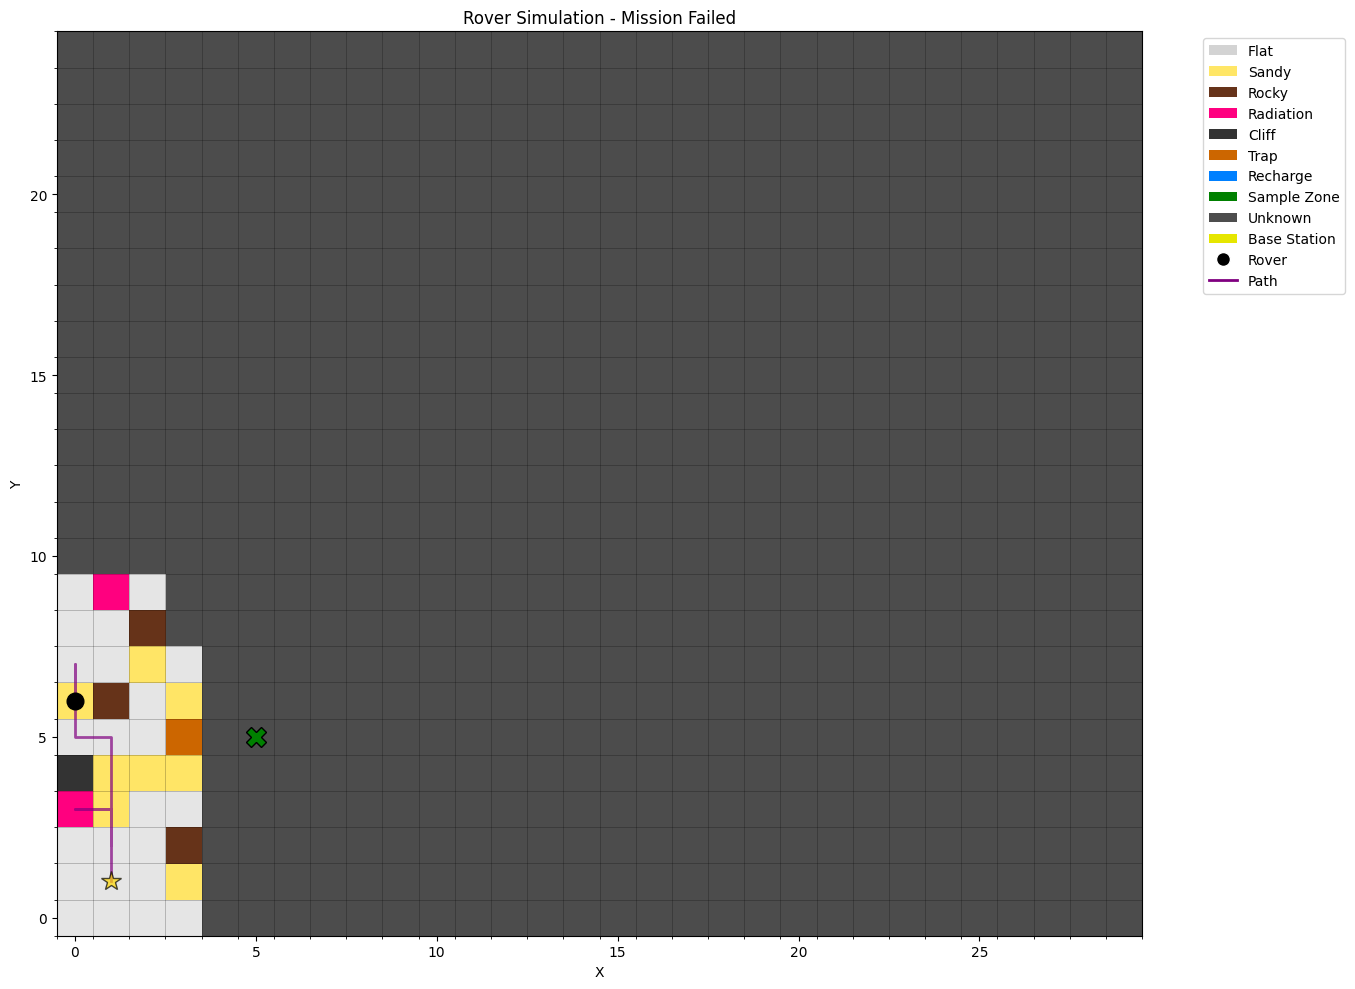

In [6]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set
import math

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # NEW: Impassable terrain
    TRAP = 7   # NEW: Dangerous terrain requiring backtracking
    UNKNOWN = 8 # NEW: Unobserved terrain
    BASE_STATION = 9 # NEW: Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        # NEW: Multi-objective mission planning attributes
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set() # Track visited generic points

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = [] # NEW: List to store base stations

        # Enhanced movement costs
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5 # NEW: Movement cost for base station
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations: # Avoid duplicates
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones: # Avoid duplicates
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION: # NEW: Handle base station
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        # Rover cannot plan through unknown, rocky, or cliff areas
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        terrain = self.grid.get_actual_terrain(*position)

        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, current_objective_pos: Tuple[int, int], # MODIFIED signature
                      current_objective_type: TerrainType, visited_traps: Set[Tuple[int, int]],
                      repair_kits: int, radiation_shields: int) -> str: # MODIFIED signature

        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # NEW: Check if current position is the current objective
        if position == current_objective_pos:
            if current_objective_type == TerrainType.SAMPLE_ZONE:
                return "collect_sample"
            elif current_objective_type == TerrainType.BASE_STATION:
                return "mission_completed" # Signal for mission end
            else: # Generic visit point (TerrainType.FLAT)
                return "objective_completed"

        # Existing hazard handling with resource management
        if terrain == TerrainType.RADIATION:
            if radiation_shields > 0:
                return "use_radiation_shield"
            else:
                return "backtrack_radiation"

        if terrain == TerrainType.TRAP and position not in visited_traps:
            if repair_kits > 0:
                return "use_repair_kit"
            else:
                return "backtrack_trap"

        if battery < 15:
            return "critical_recharge"

        if battery < 25 and station_distance <= 2:
            return "seek_recharge"

        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        return "explore"

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        # self.goal = None # REMOVED: Mission driven by objectives list
        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0, # NEW: Track total samples collected
            'objectives_completed': 0 # NEW: Track objectives completed
        }

    # MODIFIED: Renamed and changed signature
    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        # Ensure the mission ends at the base station (initial position)
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target):
            return False

        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]: # Safe positions should not include radiation/trap squares
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1:
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            safe_pos = self.state.safe_positions[-1] # Go to the truly last safe position
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                print(f"⚠️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position)
                print(f"⚠️  Trap detected! Backtracking to {safe_pos}")

    def recharge(self):
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"🔋 Recharged at {self.state.position}")

    def collect_sample(self):
        self.stats['samples_collected'] += 1 # NEW: Use stats for samples
        print(f"📦 Sample collected at {self.state.position} (Total: {self.stats['samples_collected']})")

    def use_radiation_shield(self):
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            print(f"🛡️ Used radiation shield at {self.state.position}. {self.state.radiation_shields} shields remaining.")

    def use_repair_kit(self):
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            print(f"🔧 Used repair kit at {self.state.position}. {self.state.repair_kits} kits remaining.")
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)


    def simulate_step(self, heuristic_func) -> bool:
        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False # Mission completed

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)
        action = self.reflex_agent.decide_action(percepts, current_objective_pos, current_objective_type,
                                                  self.state.visited_traps, self.state.repair_kits, self.state.radiation_shields)

        if action == "mission_completed": # NEW: Handle mission completion
            self.stats['objectives_completed'] += 1
            self.state.current_objective_index += 1
            print(f"🏠 Arrived at Base Station: Mission Complete!")
            return False # Signal mission completion

        if action == "objective_completed": # NEW: Handle generic visit points
            if current_objective_pos not in self.state.visit_points_visited:
                self.state.visit_points_visited.add(current_objective_pos)
                self.stats['objectives_completed'] += 1
                print(f"🎯 Visited point {current_objective_pos}. Moving to next objective.")
            self.state.current_objective_index += 1
            self.current_path = [] # Force replan
            return True

        if action == "collect_sample": # NEW: Handle sample collection objective
            self.collect_sample()
            self.stats['objectives_completed'] += 1
            self.state.current_objective_index += 1
            self.current_path = [] # Force replan
            print(f"📦 Collected sample at {current_objective_pos}. Moving to next objective.")
            return True

        elif action == "backtrack_radiation":
            self.backtrack("radiation")
            self.current_path = []
            return True

        elif action == "backtrack_trap":
            self.backtrack("trap")
            self.current_path = []
            return True

        elif action == "use_radiation_shield":
            self.use_radiation_shield()
            # After using shield, the rover is still on the radiation tile, but can proceed. Re-evaluate action.
            # For now, we return True and the next step will decide if it can move through.
            # A more sophisticated agent might re-plan immediately through this now-mitigated tile.
            return True

        elif action == "use_repair_kit":
            self.use_repair_kit()
            # After repairing, the tile is safe (flat). The rover should now be able to plan through it.
            self.current_path = [] # Force replan with updated terrain knowledge
            return True

        elif action == "recharge" or action == "critical_recharge":
            self.recharge()
            return True

        elif action == "seek_recharge":
            nearest_station = percepts['nearest_station']
            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])
            return False

        elif action == "explore":
            # Plan path to current objective
            if not self.current_path or self.path_index >= len(self.current_path) - 1 or \
               self.current_path[self.path_index] != self.state.position:

                planned_path = self.plan_path(heuristic_func, self.state.position, current_objective_pos)
                if planned_path and len(planned_path) > 1: # Path exists and is more than just current position
                    self.current_path = planned_path
                    self.path_index = 0
                else:
                    # No clear path to objective, try to explore unknown areas
                    return self._explore_unknown_area()

            # If a valid path exists and is not exhausted, follow it
            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

            # If path exhausted (or it was just current pos) and goal not reached, explore unknown
            return self._explore_unknown_area()

        return False

    def _explore_unknown_area(self) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y):
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y):
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            # Filter out positions marked as visited traps for this exploration step
            # Also avoid radiation if no shield available
            filtered_fallback_moves = []
            for move in fallback_moves:
                actual_terrain = self.grid.get_actual_terrain(*move)
                if move in self.state.visited_traps: # Don't go back into known traps unless repaired
                    continue
                if actual_terrain == TerrainType.RADIATION and self.state.radiation_shields == 0: # Avoid unshielded radiation
                    continue
                filtered_fallback_moves.append(move)

            if filtered_fallback_moves:
                target = random.choice(filtered_fallback_moves)
                return self.move_to_position(target)

        return False

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives): # MODIFIED loop condition
            if not self.simulate_step(heuristic_func):
                if self.state.current_objective_index >= len(self.state.mission_objectives):
                    break # Mission completed
                print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}.")
                return False
            steps += 1

        mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)
        if mission_success:
            print(f"✅ Mission completed in {steps} steps!")
        else:
            print(f"❌ Simulation ended after {steps} steps. Mission not completed.")
        return mission_success

def create_sample_grid(width=25, height=20):
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    start_pos = (1, 1)
    base_pos = (width - 2, height - 2) # Base station position

    grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION) # NEW: Place base station

    # Also ensure surrounding area of start and base are flat to prevent immediate blockades
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= start_pos[0] + dx < grid.width and 0 <= start_pos[1] + dy < grid.height:
                grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # Ensure at least one sample zone and a generic visit point for the mission
    # (These might be overwritten by random terrain gen, so we place them after)
    sample_zone_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))
    generic_visit_point_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))

    grid.set_terrain(sample_zone_1[0], sample_zone_1[1], TerrainType.SAMPLE_ZONE)
    grid.set_terrain(generic_visit_point_1[0], generic_visit_point_1[1], TerrainType.FLAT)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid",
                  mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = None,
                  current_objective_idx: int = 0, visit_points_visited: Set[Tuple[int, int]] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0] # NEW: Gold for Base Station
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    # Draw path
    if path:
        known_path_x, known_path_y = [], []
        for p_x, p_y in path:
            if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                known_path_x.append(p_x)
                known_path_y.append(p_y)
            else:
                break
        ax.plot(known_path_x, known_path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    # Draw mission objectives
    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's' # Square for generic
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1 # Draw behind current/pending
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3 # Draw on top
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            # Only draw if objective position is known or it's the current one
            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    print("=== Enhanced Planetary Rover Simulation (Part 2) ===\n")

    grid = create_sample_grid(width=30, height=25) # Increased grid size for more complex missions
    start_pos = (1, 1)
    base_pos = (grid.width - 2, grid.height - 2) # Base station is also the 'return to base' goal

    rover = PlanetaryRover(grid, start_pos)

    # Define a multi-objective mission
    mission_objectives_list = [
        (TerrainType.SAMPLE_ZONE, (5, 5)),
        (TerrainType.FLAT, (10, 15)), # Generic visit point
        (TerrainType.SAMPLE_ZONE, (20, 8)),
        (TerrainType.RECHARGE_STATION, (grid.recharge_stations[0] if grid.recharge_stations else (1,1))), # Visit first available recharge station
        (TerrainType.FLAT, (grid.width // 2, grid.height // 2))
    ]
    rover.set_mission_objectives(mission_objectives_list)

    print(f"Starting simulation with Weighted Euclidean heuristic...")
    mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=1500) # Increased max_steps

    print(f"\n{'='*50}")
    print(f"Simulation Statistics:")
    print(f"{'='*50}")
    print(f"Mission Success: {mission_success}")
    print(f"Total objectives completed: {rover.stats['objectives_completed']}")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']:.2f}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Radiation encounters: {rover.stats['radiation_encounters']}")
    print(f"Trap encounters: {rover.stats['trap_encounters']}")
    print(f"Repair kits used: {rover.stats['repair_kits_used']}")
    print(f"Radiation shields used: {rover.stats['radiation_shields_used']}")
    print(f"Samples collected: {rover.stats['samples_collected']}")
    print(f"Nodes expanded: {rover.stats['nodes_expanded']}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}")
    print(f"Remaining radiation shields: {rover.state.radiation_shields}")
    print(f"{'='*50}\n")

    visualize_grid(grid, rover.state.position, rover.state.path_history,
                  f"Rover Simulation - {'Mission Success' if mission_success else 'Mission Failed'}",
                  mission_objectives=rover.state.mission_objectives,
                  current_objective_idx=rover.state.current_objective_index,
                  visit_points_visited=rover.state.visit_points_visited)


=== Enhanced Planetary Rover Simulation (Part 2) ===

Starting simulation with Weighted Euclidean heuristic...
❌ Simulation ended after 1500 steps. Mission not completed.

Simulation Statistics:
Mission Success: False
Total objectives completed: 0
Total moves: 18
Battery used: 90.00
Recharges: 0
Backtracks: 0
Radiation encounters: 0
Trap encounters: 0
Repair kits used: 0
Radiation shields used: 0
Samples collected: 0
Nodes expanded: 372
Final battery: 10.00%
Remaining repair kits: 2
Remaining radiation shields: 1



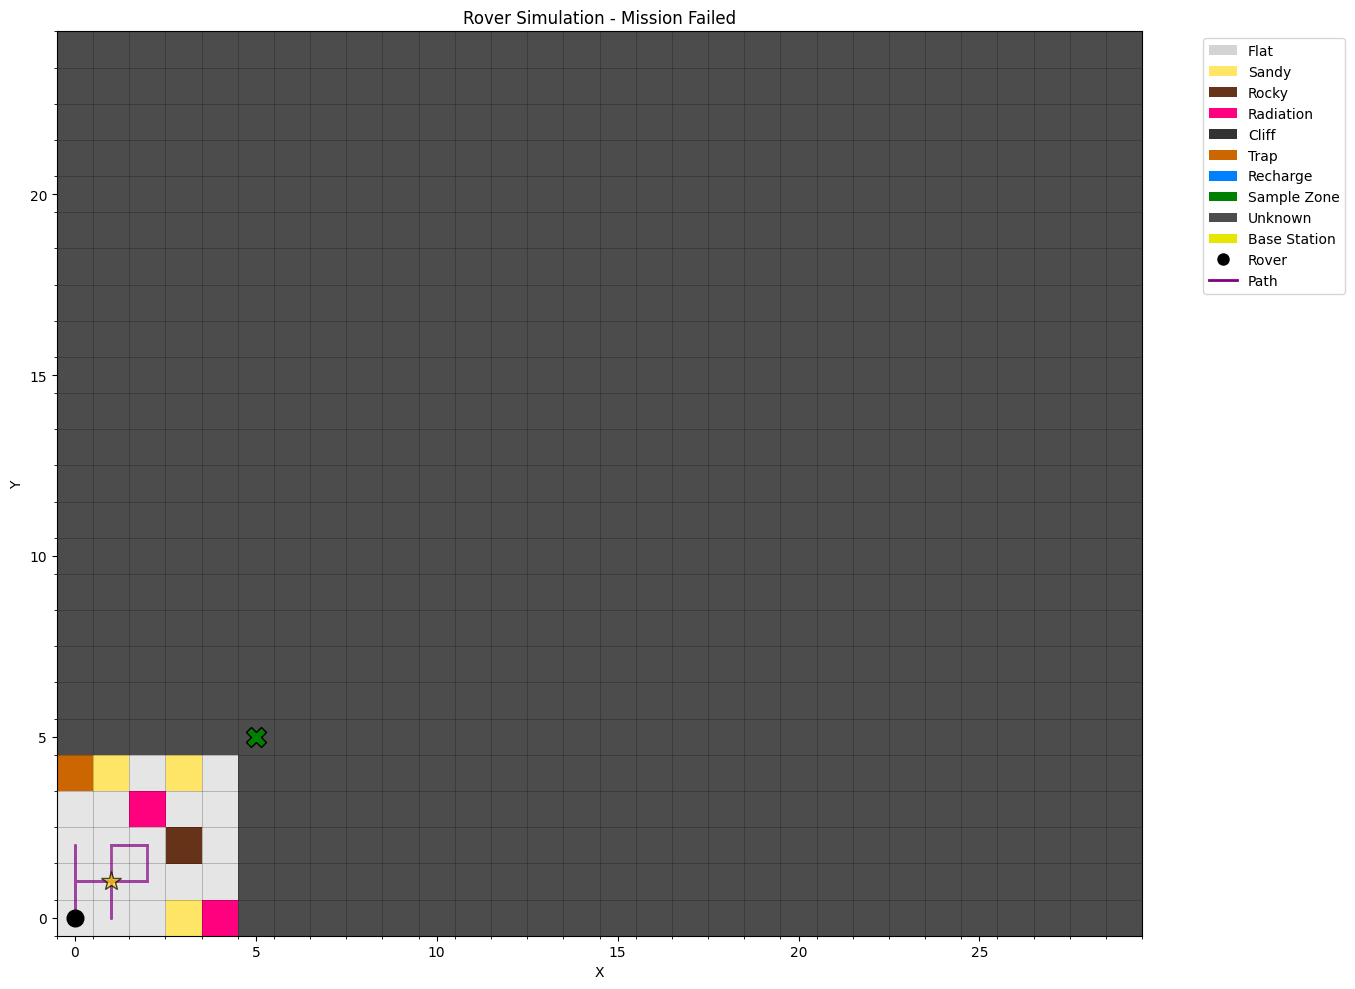

In [7]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set
import math

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # NEW: Impassable terrain
    TRAP = 7   # NEW: Dangerous terrain requiring backtracking
    UNKNOWN = 8 # NEW: Unobserved terrain
    BASE_STATION = 9 # NEW: Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        # NEW: Multi-objective mission planning attributes
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set() # Track visited generic points

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = [] # NEW: List to store base stations

        # Enhanced movement costs
        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5 # NEW: Movement cost for base station
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations: # Avoid duplicates
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones: # Avoid duplicates
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION: # NEW: Handle base station
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        # Rover cannot plan through unknown, rocky, or cliff areas
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class ReflexAgent:
    def __init__(self, grid: Grid):
        self.grid = grid

    def perceive(self, position: Tuple[int, int], battery: float) -> Dict:
        terrain = self.grid.get_actual_terrain(*position)

        nearest_station = None
        min_distance = float('inf')
        for station in self.grid.recharge_stations:
            dist = math.sqrt((position[0] - station[0])**2 + (position[1] - station[1])**2)
            if dist < min_distance:
                min_distance = dist
                nearest_station = station

        return {
            'position': position,
            'terrain': terrain,
            'battery': battery,
            'nearest_station': nearest_station,
            'station_distance': min_distance
        }

    def decide_action(self, percepts: Dict, current_objective_pos: Tuple[int, int], # MODIFIED signature
                      current_objective_type: TerrainType, visited_traps: Set[Tuple[int, int]],
                      repair_kits: int, radiation_shields: int) -> str: # MODIFIED signature

        terrain = percepts['terrain']
        battery = percepts['battery']
        position = percepts['position']
        station_distance = percepts['station_distance']

        # NEW: Check if current position is the current objective
        if position == current_objective_pos:
            if current_objective_type == TerrainType.SAMPLE_ZONE:
                return "collect_sample"
            elif current_objective_type == TerrainType.BASE_STATION:
                return "mission_completed" # Signal for mission end
            else: # Generic visit point (TerrainType.FLAT)
                return "objective_completed"

        # Existing hazard handling with resource management
        if terrain == TerrainType.RADIATION:
            if radiation_shields > 0:
                return "use_radiation_shield"
            else:
                return "backtrack_radiation"

        if terrain == TerrainType.TRAP and position not in visited_traps:
            if repair_kits > 0:
                return "use_repair_kit"
            else:
                return "backtrack_trap"

        if battery < 15:
            return "critical_recharge"

        if battery < 25 and station_distance <= 2:
            return "seek_recharge"

        if terrain == TerrainType.RECHARGE_STATION and battery < 100:
            return "recharge"

        return "explore"

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int]):
        self.grid = grid
        self.state = RoverState(start_position)
        self.reflex_agent = ReflexAgent(grid)
        # self.goal = None # REMOVED: Mission driven by objectives list
        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0, # NEW: Track total samples collected
            'objectives_completed': 0 # NEW: Track objectives completed
        }

    # MODIFIED: Renamed and changed signature
    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        # Ensure the mission ends at the base station (initial position)
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target):
            return False

        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]: # Safe positions should not include radiation/trap squares
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1:
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            safe_pos = self.state.safe_positions[-1] # Go to the truly last safe position
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                print(f"☢️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position)
                print(f"☢️  Trap detected! Backtracking to {safe_pos}")

    def recharge(self):
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            print(f"🔋 Recharged at {self.state.position}")

    def collect_sample(self):
        self.stats['samples_collected'] += 1 # NEW: Use stats for samples
        print(f"📦 Sample collected at {self.state.position} (Total: {self.stats['samples_collected']})")

    def use_radiation_shield(self):
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            print(f"🛡️ Used radiation shield at {self.state.position}. {self.state.radiation_shields} shields remaining.")

    def use_repair_kit(self):
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            print(f"🔧 Used repair kit at {self.state.position}. {self.state.repair_kits} kits remaining.")
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)


    def simulate_step(self, heuristic_func) -> bool:
        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False # Mission completed

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        percepts = self.reflex_agent.perceive(self.state.position, self.state.battery)
        action = self.reflex_agent.decide_action(percepts, current_objective_pos, current_objective_type,
                                                  self.state.visited_traps, self.state.repair_kits, self.state.radiation_shields)

        if action == "mission_completed": # NEW: Handle mission completion
            self.stats['objectives_completed'] += 1
            self.state.current_objective_index += 1
            print(f"🏠 Arrived at Base Station: Mission Complete!")
            return False # Signal mission completion

        if action == "objective_completed": # NEW: Handle generic visit points
            if current_objective_pos not in self.state.visit_points_visited:
                self.state.visit_points_visited.add(current_objective_pos)
                self.stats['objectives_completed'] += 1
                print(f"🎯 Visited point {current_objective_pos}. Moving to next objective.")
            self.state.current_objective_index += 1
            self.current_path = [] # Force replan
            return True

        if action == "collect_sample": # NEW: Handle sample collection objective
            self.collect_sample()
            self.stats['objectives_completed'] += 1
            self.state.current_objective_index += 1
            self.current_path = [] # Force replan
            print(f"📦 Collected sample at {current_objective_pos}. Moving to next objective.")
            return True

        elif action == "backtrack_radiation":
            self.backtrack("radiation")
            self.current_path = []
            return True

        elif action == "backtrack_trap":
            self.backtrack("trap")
            self.current_path = []
            return True

        elif action == "use_radiation_shield":
            self.use_radiation_shield()
            # After using shield, the rover is still on the radiation tile, but can proceed. Re-evaluate action.
            # For now, we return True and the next step will decide if it can move through.
            # A more sophisticated agent might re-plan immediately through this now-mitigated tile.
            return True

        elif action == "use_repair_kit":
            self.use_repair_kit()
            # After repairing, the tile is safe (flat). The rover should now be able to plan through it.
            self.current_path = [] # Force replan with updated terrain knowledge
            return True

        elif action == "recharge" or action == "critical_recharge":
            self.recharge()
            return True

        elif action == "seek_recharge":
            nearest_station = percepts['nearest_station']
            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    return self.move_to_position(path[1])
            return False

        elif action == "explore":
            # Plan path to current objective
            if not self.current_path or self.path_index >= len(self.current_path) - 1 or \
               self.current_path[self.path_index] != self.state.position:

                planned_path = self.plan_path(heuristic_func, self.state.position, current_objective_pos)
                if planned_path and len(planned_path) > 1: # Path exists and is more than just current position
                    self.current_path = planned_path
                    self.path_index = 0
                else:
                    # No clear path to objective, try to explore unknown areas
                    return self._explore_unknown_area()

            # If a valid path exists and is not exhausted, follow it
            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                return self.move_to_position(self.current_path[self.path_index])

            # If path exhausted (or it was just current pos) and goal not reached, explore unknown
            return self._explore_unknown_area()

        return False

    def _explore_unknown_area(self) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y):
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y):
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            # Filter out positions marked as visited traps for this exploration step
            # Also avoid radiation if no shield available
            filtered_fallback_moves = []
            for move in fallback_moves:
                actual_terrain = self.grid.get_actual_terrain(*move)
                if move in self.state.visited_traps: # Don't go back into known traps unless repaired
                    continue
                if actual_terrain == TerrainType.RADIATION and self.state.radiation_shields == 0: # Avoid unshielded radiation
                    continue
                filtered_fallback_moves.append(move)

            if filtered_fallback_moves:
                target = random.choice(filtered_fallback_moves)
                return self.move_to_position(target)

        return False

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives): # MODIFIED loop condition
            if not self.simulate_step(heuristic_func):
                if self.state.current_objective_index >= len(self.state.mission_objectives):
                    break # Mission completed
                print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}.")
                return False
            steps += 1

        mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)
        if mission_success:
            print(f"✅ Mission completed in {steps} steps!")
        else:
            print(f"❌ Simulation ended after {steps} steps. Mission not completed.")
        return mission_success

def create_sample_grid(width=25, height=20):
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    start_pos = (1, 1)
    base_pos = (width - 2, height - 2) # Base station position

    grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION) # NEW: Place base station

    # Also ensure surrounding area of start and base are flat to prevent immediate blockades
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= start_pos[0] + dx < grid.width and 0 <= start_pos[1] + dy < grid.height:
                grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # Ensure at least one sample zone and a generic visit point for the mission
    # (These might be overwritten by random terrain gen, so we place them after)
    sample_zone_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))
    generic_visit_point_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))

    grid.set_terrain(sample_zone_1[0], sample_zone_1[1], TerrainType.SAMPLE_ZONE)
    grid.set_terrain(generic_visit_point_1[0], generic_visit_point_1[1], TerrainType.FLAT)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid",
                  mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = None,
                  current_objective_idx: int = 0, visit_points_visited: Set[Tuple[int, int]] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0] # NEW: Gold for Base Station
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    # Draw path
    if path:
        known_path_x, known_path_y = [], []
        for p_x, p_y in path:
            if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                known_path_x.append(p_x)
                known_path_y.append(p_y)
            else:
                break
        ax.plot(known_path_x, known_path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    # Draw mission objectives
    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's' # Square for generic
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1 # Draw behind current/pending
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3 # Draw on top
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            # Only draw if objective position is known or it's the current one
            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    print("=== Enhanced Planetary Rover Simulation (Part 2) ===\n")

    grid = create_sample_grid(width=30, height=25) # Increased grid size for more complex missions
    start_pos = (1, 1)
    base_pos = (grid.width - 2, grid.height - 2) # Base station is also the 'return to base' goal

    rover = PlanetaryRover(grid, start_pos)

    # Define a multi-objective mission
    mission_objectives_list = [
        (TerrainType.SAMPLE_ZONE, (5, 5)),
        (TerrainType.FLAT, (10, 15)), # Generic visit point
        (TerrainType.SAMPLE_ZONE, (20, 8)),
        (TerrainType.RECHARGE_STATION, (grid.recharge_stations[0] if grid.recharge_stations else (1,1))), # Visit first available recharge station
        (TerrainType.FLAT, (grid.width // 2, grid.height // 2))
    ]
    rover.set_mission_objectives(mission_objectives_list)

    print(f"Starting simulation with Weighted Euclidean heuristic...")
    mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=1500) # Increased max_steps

    print(f"\n{'='*50}")
    print(f"Simulation Statistics:")
    print(f"{'='*50}")
    print(f"Mission Success: {mission_success}")
    print(f"Total objectives completed: {rover.stats['objectives_completed']}")
    print(f"Total moves: {rover.stats['total_moves']}")
    print(f"Battery used: {rover.stats['battery_used']:.2f}")
    print(f"Recharges: {rover.stats['recharges']}")
    print(f"Backtracks: {rover.stats['backtracks']}")
    print(f"Radiation encounters: {rover.stats['radiation_encounters']}")
    print(f"Trap encounters: {rover.stats['trap_encounters']}")
    print(f"Repair kits used: {rover.stats['repair_kits_used']}")
    print(f"Radiation shields used: {rover.stats['radiation_shields_used']}")
    print(f"Samples collected: {rover.stats['samples_collected']}")
    print(f"Nodes expanded: {rover.stats['nodes_expanded']}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}")
    print(f"Remaining radiation shields: {rover.state.radiation_shields}")
    print(f"{'='*50}\n")

    visualize_grid(grid, rover.state.position, rover.state.path_history,
                  f"Rover Simulation - {'Mission Success' if mission_success else 'Mission Failed'}",
                  mission_objectives=rover.state.mission_objectives,
                  current_objective_idx=rover.state.current_objective_index,
                  visit_points_visited=rover.state.visit_points_visited)

## Adaptive Rover Behavior with Learning

### Subtask:
Implement a simple reinforcement learning agent (e.g., Q-learning) within the PlanetaryRover to learn optimal policies for navigation and resource management, replacing the fixed rules of the ReflexAgent.


**Reasoning**:
The subtask requires implementing a Q-learning agent to replace the `ReflexAgent` for decision-making and incorporating a training loop. This involves defining a new `QLearningAgent` class with state discretization, action space, Q-table, exploration-exploitation strategy, and a reward function. The `PlanetaryRover` class will then be modified to use this Q-learning agent and include the training mechanism, necessitating a single comprehensive code block.



=== Q-Learning Planetary Rover Simulation ===

Episode 20/200, Epsilon: 0.090, Success: False, Moves: 2
Episode 40/200, Epsilon: 0.082, Success: False, Moves: 0
Episode 60/200, Epsilon: 0.074, Success: False, Moves: 1
Episode 80/200, Epsilon: 0.067, Success: False, Moves: 0
Episode 100/200, Epsilon: 0.061, Success: False, Moves: 11
Episode 120/200, Epsilon: 0.055, Success: False, Moves: 0
Episode 140/200, Epsilon: 0.050, Success: False, Moves: 2
Episode 160/200, Epsilon: 0.045, Success: False, Moves: 1
Episode 180/200, Epsilon: 0.041, Success: False, Moves: 1
Episode 200/200, Epsilon: 0.037, Success: False, Moves: 7

--- Training Completed ---
Final Epsilon: 0.037

Final Simulation Statistics (Last Episode):
Mission Success: False
Total objectives completed: 0
Total moves: 7
Battery used: 55.00
Recharges: 0
Backtracks: 0
Samples collected: 0
Nodes expanded: 0
Final battery: 45.00%
Remaining repair kits: 0
Remaining radiation shields: 0



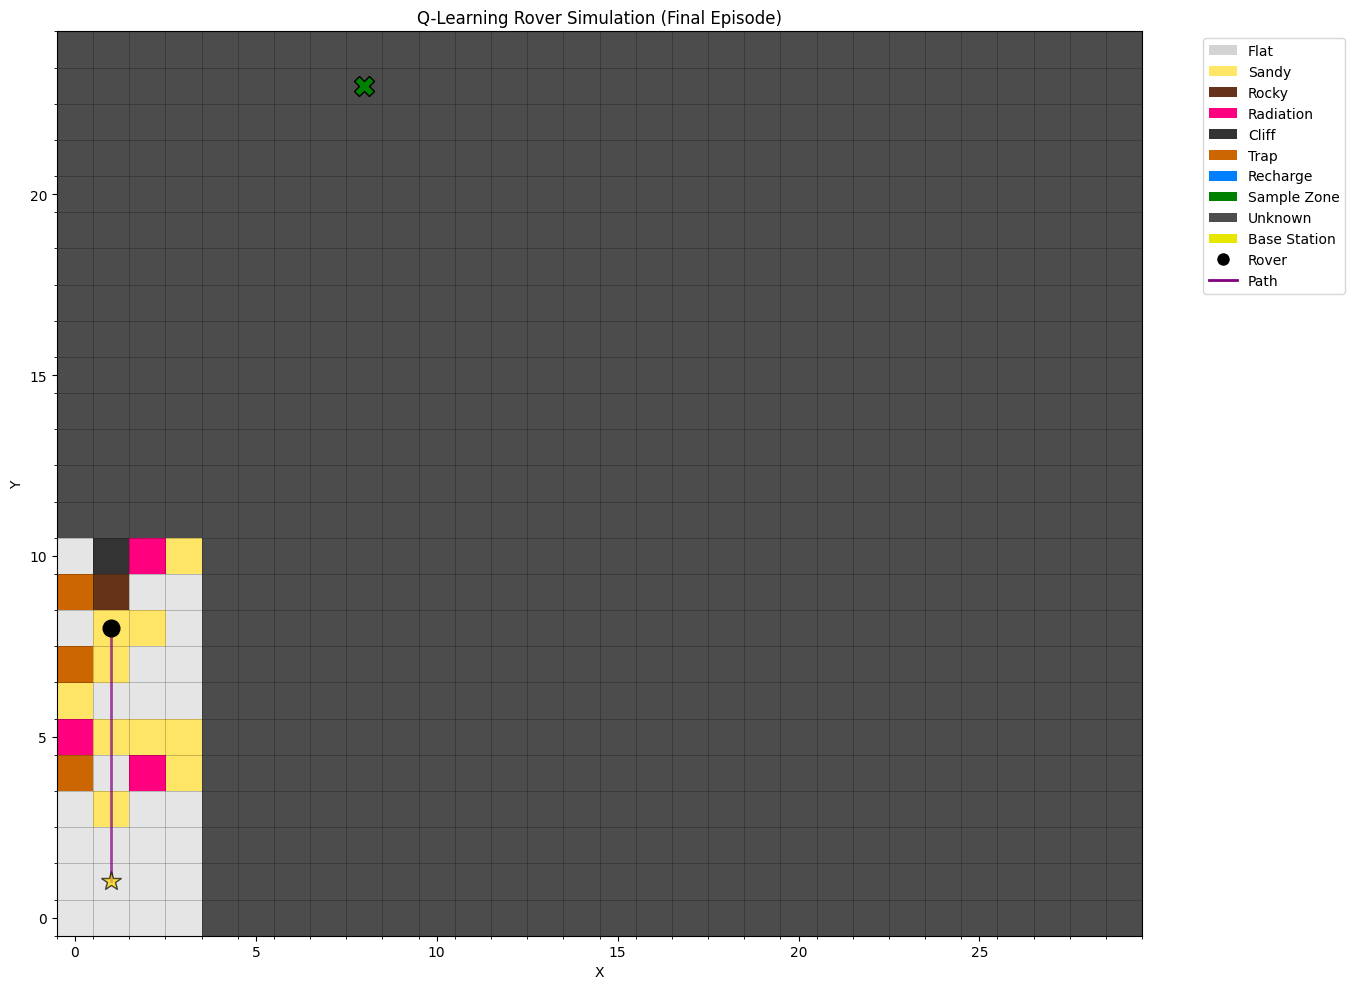


--- Q-Table Info for Current State ---
Current State: (0, 2, 0, 0, 4, 4, 5, 0)
  Action move_N: -18.03
  Action move_E: -0.01
  Action move_S: -0.01
  Action move_W: -0.01
  Action use_radiation_shield: -18.47
  Action use_repair_kit: -18.92
  Action seek_recharge: -18.02
  Action collect_sample: -23.72
  Action objective_completed: -18.02
  Action mission_completed: -23.72
  Action backtrack_radiation: -5.01
  Action backtrack_trap: -5.01
  Optimal Action: move_E


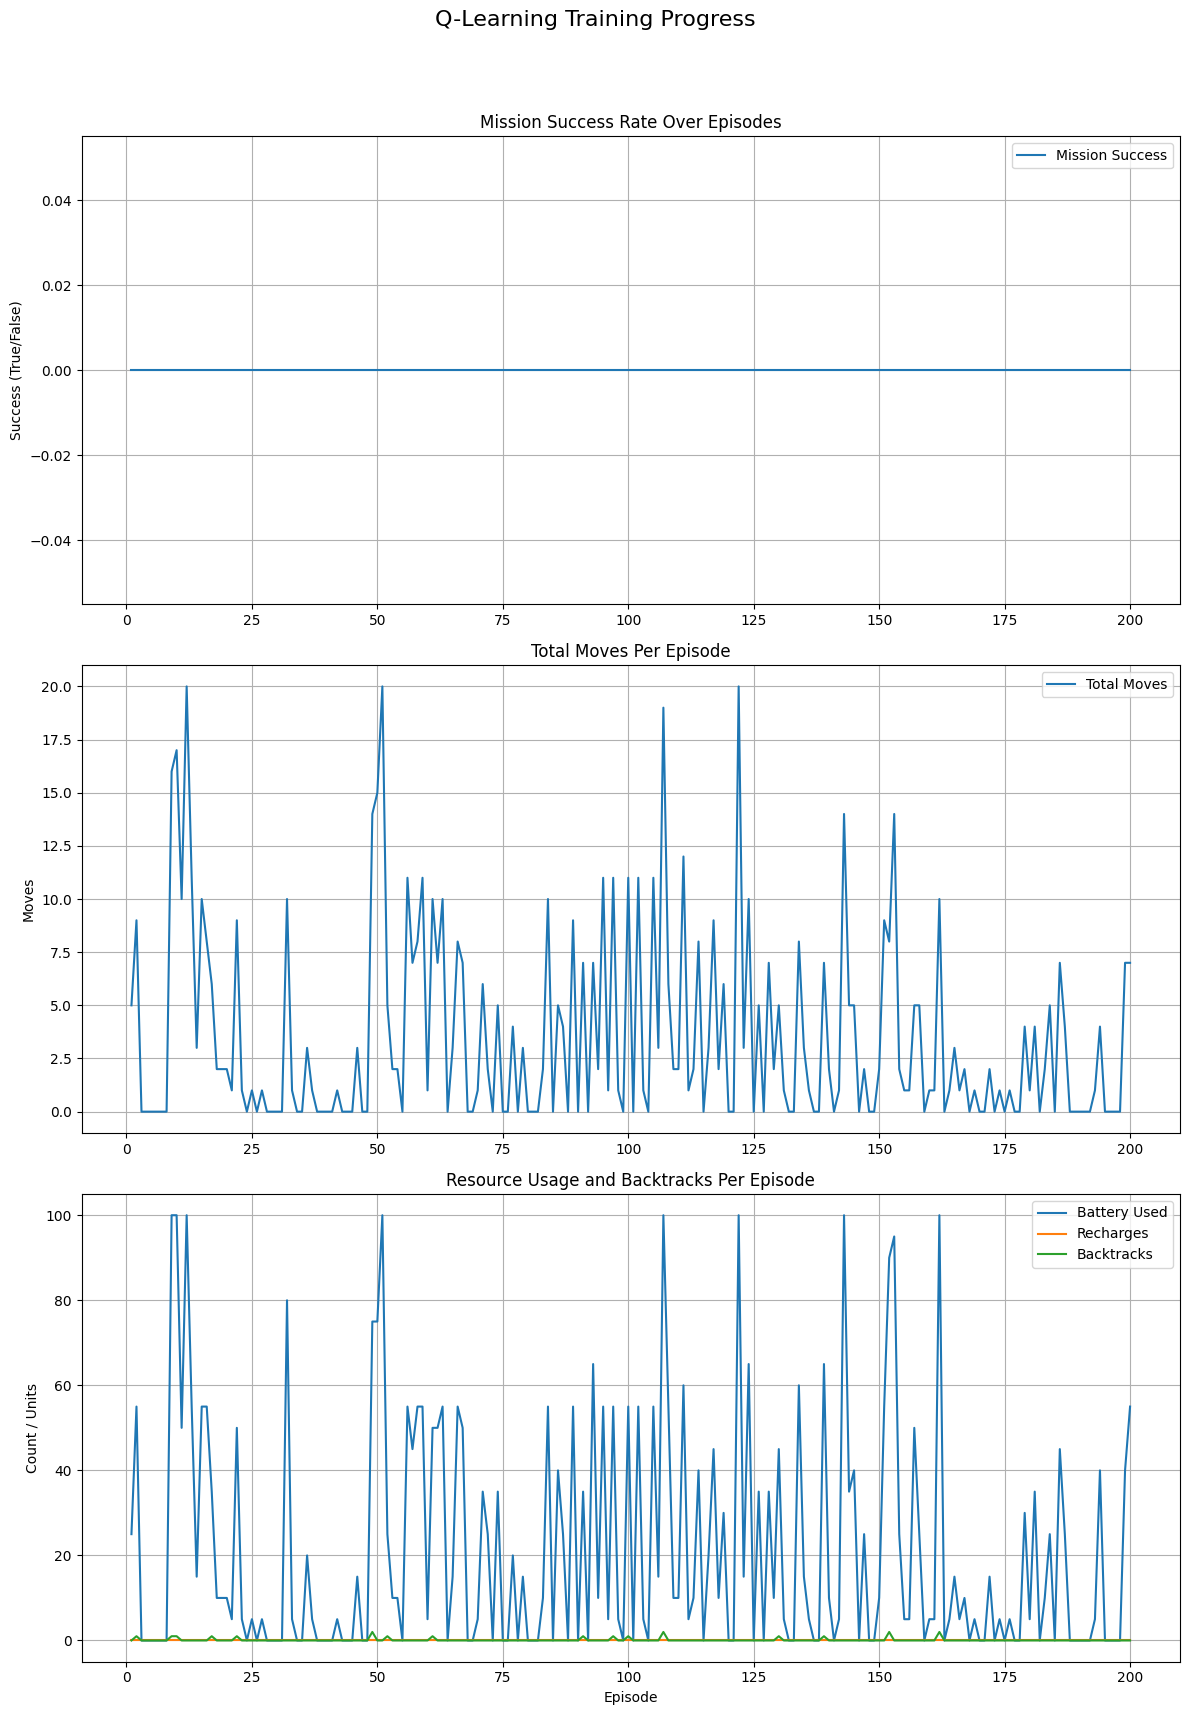

In [8]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set, Any
import math
import collections

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # Impassable terrain
    TRAP = 7   # Dangerous terrain requiring backtracking
    UNKNOWN = 8 # Unobserved terrain
    BASE_STATION = 9 # Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set()

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = []

        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations:
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones:
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION:
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]  # f_score, current_node
        came_from = {}  # current_node -> previous_node
        g_score = {start: 0}  # cost from start to current_node
        f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class QLearningAgent:
    def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        self.grid = grid
        self.actions = actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration-exploitation trade-off
        self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

        # Action mapping for easier use
        self.action_to_index = {action: i for i, action in enumerate(actions)}
        self.index_to_action = {i: action for i, action in enumerate(actions)}

    def _discretize_battery(self, battery: float) -> int:
        if battery < 15: return 0  # Critical
        if battery < 25: return 1  # Low
        if battery < 50: return 2  # Medium
        return 3  # High

    def _discretize_distance(self, dist: float) -> int:
        if dist == float('inf'): return 4 # No known path
        if dist == 0: return 0 # At location
        if dist < 5: return 1 # Near
        if dist < 15: return 2 # Medium
        return 3 # Far

    def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
                   current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
        # Rover's current position terrain
        current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

        # Battery level
        battery_bin = self._discretize_battery(rover_state.battery)

        # Repair kits and radiation shields
        repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
        radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

        # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
        dist_to_obj = float('inf')
        if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
            path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
            if path_to_obj: dist_to_obj = len(path_to_obj) - 1
        obj_dist_bin = self._discretize_distance(dist_to_obj)

        # Distance to nearest recharge station
        dist_to_recharge = float('inf')
        if self.grid.recharge_stations:
            min_recharge_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
                    path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
                    if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
            dist_to_recharge = min_recharge_dist
        recharge_dist_bin = self._discretize_distance(dist_to_recharge)

        # Current objective type (numerical representation)
        obj_type_value = current_objective_type.value

        # Has rover encountered a trap recently at current position?
        is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

        # Combine into a state tuple
        state_tuple = (
            current_terrain,
            battery_bin,
            repair_kits_count,
            radiation_shields_count,
            obj_dist_bin,
            recharge_dist_bin,
            obj_type_value,
            is_at_known_trap
        )
        return state_tuple

    def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)  # Explore
        else:
            q_values = self.q_table[state_tuple]
            action_index = np.argmax(q_values) # Exploit
            return self.index_to_action[action_index]

    def learn(self, state: Tuple[Any, ...], action: str, reward: float,
              next_state: Tuple[Any, ...], done: bool):
        action_index = self.action_to_index[action]
        current_q = self.q_table[state][action_index]

        if done:
            new_q = reward
        else:
            max_next_q = np.max(self.q_table[next_state])
            new_q = reward + self.gamma * max_next_q

        self.q_table[state][action_index] += self.alpha * (new_q - current_q)

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
        self.grid = grid
        self.state = RoverState(start_position)

        # Define Q-learning actions
        self.q_actions = [
            'move_N', 'move_E', 'move_S', 'move_W',
            'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
            'collect_sample', 'objective_completed', 'mission_completed',
            'backtrack_radiation', 'backtrack_trap'
        ]
        self.q_agent = QLearningAgent(grid, self.q_actions)
        self.heuristic_func_for_state = heuristic_func_for_state

        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }

    def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
        self.grid = new_grid
        self.state = RoverState(start_position)
        self.current_path = []
        self.path_index = 0
        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target): # Check actual validity
            return False

        # Use actual terrain cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard"):
        if len(self.state.safe_positions) > 1: # Ensure there's a safe position to go back to
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            if not self.state.safe_positions: # If no safe positions left (e.g. only start was safe, and it was popped)
                # This case should ideally not happen if start position is always safe
                return # Cannot backtrack

            safe_pos = self.state.safe_positions[-1]
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
                # print(f"☢️  Radiation detected! Backtracking to {safe_pos}")
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
                # print(f"☢️  Trap detected! Backtracking to {safe_pos}")
            return True
        return False # Failed to backtrack

    def recharge(self) -> bool:
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            # print(f"🔋 Recharged at {self.state.position}")
            return True
        return False

    def collect_sample(self) -> bool:
        # Check if current position is actually a sample zone (and potentially the current objective)
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE:
            self.stats['samples_collected'] += 1
            # print(f"📦 Sample collected at {self.state.position} (Total: {self.stats['samples_collected']})")
            return True
        return False

    def use_radiation_shield(self) -> bool:
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            # print(f"🛡️ Used radiation shield at {self.state.position}. {self.state.radiation_shields} shields remaining.")
            # The rover effectively bypasses the hazard for this turn. No actual movement happens immediately.
            return True
        return False

    def use_repair_kit(self) -> bool:
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            # print(f"🔧 Used repair kit at {self.state.position}. {self.state.repair_kits} kits remaining.")
            # Neutralize the trap by updating the known terrain and removing it from visited_traps
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)
            return True
        return False

    def get_reward(self, prev_state_obj_idx: int, current_action: str, current_terrain_actual: TerrainType,
                   mission_success_flag: bool, simulation_stuck: bool) -> float:
        reward = -0.1 # Small penalty for each step/move to encourage efficiency

        # Reward for completing an objective
        if self.state.current_objective_index > prev_state_obj_idx:
            if current_action == 'collect_sample':
                reward += 100 # High reward for samples
            elif current_action == 'objective_completed':
                reward += 50 # Medium reward for generic objectives
            elif current_action == 'mission_completed':
                reward += 1000 # Very high reward for completing the entire mission

        # Rewards/Penalties related to hazards and resources
        if current_action == 'use_radiation_shield':
            reward -= 5 # Cost for using a shield, but avoids larger penalty
        elif current_action == 'use_repair_kit':
            reward -= 10 # Cost for using a kit, higher as it modifies terrain
        elif current_action == 'backtrack_radiation' or current_action == 'backtrack_trap':
            reward -= 50 # High penalty for forced backtrack

        # Penalties for negative state conditions
        if self.state.battery <= 0: # Ran out of battery
            reward -= 100

        if simulation_stuck:
            reward -= 200 # Major penalty for getting stuck

        if current_terrain_actual == TerrainType.TRAP and self.state.position not in self.state.visited_traps and current_action not in ['use_repair_kit']:
            reward -= 30 # Penalty for entering new trap without using kit
        if current_terrain_actual == TerrainType.RADIATION and current_action not in ['use_radiation_shield']:
            reward -= 20 # Penalty for entering radiation without shield

        if current_action == 'seek_recharge' and self.state.battery < 25:
             reward += 10 # Small reward for trying to recharge when low
        if current_action == 'recharge':
            reward += 20 # Reward for actually recharging

        # Reward for just making progress (e.g., getting closer to objective)
        # This is tricky without making the reward function too dense. For now, rely on step penalty and objective rewards.

        return reward


    def simulate_step(self, heuristic_func: Any) -> Tuple[bool, str]: # Returns (success of step, action_taken)
        current_pos = self.state.position
        current_terrain_actual = self.grid.get_actual_terrain(*current_pos)

        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False, "mission_completed" # Signal completion

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(current_pos[0], current_pos[1], self.vision_radius)

        # Get current state for Q-learning
        state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)
        action_chosen = self.q_agent.choose_action(state_tuple)

        # Keep track of previous objective index for reward calculation
        prev_objective_index = self.state.current_objective_index

        step_successful = False
        actual_action_taken = action_chosen # Default, might be refined if sub-actions occur

        if action_chosen == 'backtrack_radiation':
            step_successful = self.backtrack("radiation")
            self.current_path = []  # Invalidate current path, replan needed

        elif action_chosen == 'backtrack_trap':
            step_successful = self.backtrack("trap")
            self.current_path = [] # Invalidate current path, replan needed

        elif action_chosen == 'use_radiation_shield':
            step_successful = self.use_radiation_shield()

        elif action_chosen == 'use_repair_kit':
            step_successful = self.use_repair_kit()

        elif action_chosen == 'recharge':
            step_successful = self.recharge()

        elif action_chosen == 'collect_sample': # Only relevant if current_pos is sample obj
            step_successful = self.collect_sample()
            if step_successful and self.state.position == current_objective_pos:
                 self.stats['objectives_completed'] += 1
                 self.state.current_objective_index += 1
                 self.current_path = [] # Force replan

        elif action_chosen == 'objective_completed': # For non-sample objectives
            if self.state.position == current_objective_pos:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1
                self.state.visit_points_visited.add(current_objective_pos)
                self.current_path = [] # Force replan
                step_successful = True
            else: # Agent tried to complete objective but wasn't there yet
                step_successful = False

        elif action_chosen == 'mission_completed': # For base station objective
            if self.state.position == current_objective_pos and current_objective_type == TerrainType.BASE_STATION:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1 # This will make the mission complete in run_simulation
                step_successful = True
            else: # Agent tried to complete mission but wasn't at base or mission not over
                step_successful = False

        elif action_chosen == 'seek_recharge':
            nearest_station = None
            # find nearest station among known ones, prioritizing reachable
            current_min_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.is_valid_for_planning(*self.state.position) and self.grid.is_valid_for_planning(*station):
                    path = self.plan_path(heuristic_func, self.state.position, station)
                    if path and len(path) - 1 < current_min_dist:
                        current_min_dist = len(path) - 1
                        nearest_station = station

            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1:
                    step_successful = self.move_to_position(path[1])
                else: # Could not move to station (e.g. blocked, or already there, handled by recharge action)
                    step_successful = False
            else:
                step_successful = False # No known recharge station to seek

        elif action_chosen.startswith('move_'): # Primitive movement actions
            dx, dy = 0, 0
            if action_chosen == 'move_N': dy = 1
            elif action_chosen == 'move_E': dx = 1
            elif action_chosen == 'move_S': dy = -1
            elif action_chosen == 'move_W': dx = -1

            target_pos = (current_pos[0] + dx, current_pos[1] + dy)
            step_successful = self.move_to_position(target_pos)

        # Fallback for 'explore' or other non-specific actions if not handled explicitly and a plan is needed
        else: # This handles cases where agent chooses 'explore' or if high-level action failed to execute
            # If current path is exhausted or invalid, replan to current objective
            if not self.current_path or self.path_index >= len(self.current_path) - 1 or \
               (self.current_path and self.current_path[self.path_index] != current_pos):

                # Try to plan a path to the current objective using currently known terrain
                planned_path = self.plan_path(heuristic_func, current_pos, current_objective_pos)
                if planned_path and len(planned_path) > 1: # Path exists and is more than just current position
                    self.current_path = planned_path
                    self.path_index = 0
                else: # No path to objective, explore unknown areas
                    return self._explore_unknown_area(current_terrain_actual), "explore_unknown" # Return actual action taken

            # If a valid path exists and is not exhausted, follow it
            if self.current_path and self.path_index < len(self.current_path) - 1:
                self.path_index += 1
                step_successful = self.move_to_position(self.current_path[self.path_index])
            else:
                # Path exhausted or no path, try to explore unknown areas as a fallback
                return self._explore_unknown_area(current_terrain_actual), "explore_unknown"

        return step_successful, actual_action_taken

    def _explore_unknown_area(self, current_terrain_actual: TerrainType) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y): # Check actual validity
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        # Fallback to moving to a random *known* valid adjacent cell if no unknown cells directly visible
        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y):
                actual_terrain_neighbor = self.grid.get_actual_terrain(new_x, new_y)
                # Avoid moving into known traps or unshielded radiation during fallback exploration
                if (new_x, new_y) in self.state.visited_traps and current_terrain_actual != TerrainType.TRAP: continue # If current isn't trap, avoid known traps
                if actual_terrain_neighbor == TerrainType.RADIATION and self.state.radiation_shields == 0: continue
                if actual_terrain_neighbor == TerrainType.CLIFF or actual_terrain_neighbor == TerrainType.ROCKY: continue
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            target = random.choice(fallback_moves)
            return self.move_to_position(target)

        return False # No valid moves left for exploration

    def run_simulation(self, heuristic_func: Any, max_steps: int = 1000) -> bool:
        steps = 0
        mission_success = False

        prev_rover_pos = self.state.position # Track previous position to detect if stuck

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives):
            current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

            # Get initial state for Q-learning for this step
            current_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)

            step_start_battery = self.state.battery
            step_start_obj_idx = self.state.current_objective_index
            step_start_pos = self.state.position

            step_successful, action_taken_by_rover = self.simulate_step(heuristic_func)

            simulation_stuck = (self.state.position == step_start_pos and self.state.battery == step_start_battery and not step_successful)

            # Get next state after action (even if action failed or stuck)
            next_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)

            # Determine reward
            reward = self.get_reward(step_start_obj_idx, action_taken_by_rover, self.grid.get_actual_terrain(*step_start_pos),
                                     mission_success_flag=False, simulation_stuck=simulation_stuck)

            # Q-learning update
            self.q_agent.learn(current_state_tuple, action_taken_by_rover, reward, next_state_tuple, done=not step_successful or simulation_stuck)

            if not step_successful and not simulation_stuck:
                # If step was not successful and rover is not stuck, it means mission might be complete or halted
                if self.state.current_objective_index >= len(self.state.mission_objectives):
                    mission_success = True
                    break
                # print(f"❌ Simulation halted at step {steps}. Rover could not make a valid move.")
                break

            if simulation_stuck:
                # print(f"❌ Simulation halted: Rover stuck at step {steps}.")
                break

            steps += 1

        # Final check for mission success and final Q-learning update
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            mission_success = True

        # Final reward and learning update for the terminal state
        final_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)
        final_reward = self.get_reward(self.state.current_objective_index-1 if mission_success else self.state.current_objective_index,
                                       'mission_completed' if mission_success else 'failed_to_complete',
                                       self.grid.get_actual_terrain(*self.state.position),
                                       mission_success_flag=mission_success, simulation_stuck=not mission_success and steps >= max_steps)
        # Use a dummy action if mission failed, or 'mission_completed' if successful
        self.q_agent.learn(current_state_tuple, action_taken_by_rover, final_reward, final_state_tuple, done=True)


        if mission_success:
            # print(f"✅ Mission completed in {steps} steps!")
            pass
        else:
            # print(f"❌ Simulation ended after {steps} steps. Mission not completed.")
            pass
        return mission_success

def create_sample_grid(width=25, height=20): # Adjusted default size for more complexity
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    start_pos = (1, 1)
    base_pos = (width - 2, height - 2) # Base station position

    grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION)

    # Also ensure surrounding area of start and base are flat to prevent immediate blockades
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= start_pos[0] + dx < grid.width and 0 <= start_pos[1] + dy < grid.height:
                grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # Ensure at least one sample zone and a generic visit point for the mission
    # (These might be overwritten by random terrain gen, so we place them after)
    sample_zone_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))
    generic_visit_point_1 = (random.randint(5, grid.width-5), random.randint(5, grid.height-5))

    grid.set_terrain(sample_zone_1[0], sample_zone_1[1], TerrainType.SAMPLE_ZONE)
    grid.set_terrain(generic_visit_point_1[0], generic_visit_point_1[1], TerrainType.FLAT)

    return grid

def visualize_grid(grid: Grid, rover_pos: Tuple[int, int] = None,
                  path: List[Tuple[int, int]] = None, title: str = "Planetary Rover Grid",
                  mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = None,
                  current_objective_idx: int = 0, visit_points_visited: Set[Tuple[int, int]] = None,
                  show_q_table_info: bool = False, q_agent: Optional[QLearningAgent] = None,
                  heuristic_func: Optional[Any] = None, rover_state: Optional[RoverState] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0] # Gold for Base Station
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    if path:
        known_path_x, known_path_y = [], []
        for p_x, p_y in path:
            if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                known_path_x.append(p_x)
                known_path_y.append(p_y)
            else:
                break
        ax.plot(known_path_x, known_path_y, 'purple', linewidth=2, alpha=0.7, label='Path')

    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's'
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"
            elif obj_type == TerrainType.RECHARGE_STATION:
                marker = 'o'
                color = 'blue'
                label_prefix = "Recharge"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

    if rover_pos:
        ax.plot(rover_pos[0], rover_pos[1], 'ko', markersize=12, label='Rover')

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    if rover_pos:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor='black', markersize=10, label='Rover'))
    if path:
        legend_elements.append(plt.Line2D([0], [0], color='purple', linewidth=2, label='Path'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    if show_q_table_info and q_agent and rover_state and heuristic_func:
        print("\n--- Q-Table Info for Current State ---")
        if rover_state.current_objective_index < len(rover_state.mission_objectives):
            current_obj_type, current_obj_pos = rover_state.mission_objectives[rover_state.current_objective_index]
        else: # If mission complete, use dummy objective data for state representation
            current_obj_type = TerrainType.BASE_STATION
            current_obj_pos = rover_state.position # Or some other default

        current_q_state = q_agent._get_state(rover_state, current_obj_type, current_obj_pos, heuristic_func)
        q_values_at_state = q_agent.q_table[current_q_state]
        if np.any(q_values_at_state != 0):
            print(f"Current State: {current_q_state}")
            for i, q_val in enumerate(q_values_at_state):
                print(f"  Action {q_agent.index_to_action[i]}: {q_val:.2f}")
            print(f"  Optimal Action: {q_agent.index_to_action[np.argmax(q_values_at_state)]}")
        else:
            print(f"Current State: {current_q_state} (No Q-values learned yet for this state)")


# Example usage for training loop
if __name__ == "__main__":
    print("=== Q-Learning Planetary Rover Simulation ===\n")

    num_training_episodes = 200 # Number of times to train the agent
    max_steps_per_episode = 1000
    epsilon_decay_rate = 0.995 # Epsilon will decay each episode
    min_epsilon = 0.01

    # Initial setup for rover and mission
    grid_width, grid_height = 30, 25
    start_pos_initial = (1, 1)
    base_pos_initial = (grid_width - 2, grid_height - 2)

    # Instantiate a rover, it will be reset for each episode
    # Heuristic is passed to QLearningAgent for state representation (distance calculation)
    rover = PlanetaryRover(Grid(grid_width, grid_height), start_pos_initial, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
    initial_epsilon = rover.q_agent.epsilon

    overall_results = {
        'episode': [],
        'epsilon': [],
        'mission_success': [],
        'total_moves': [],
        'battery_used': [],
        'recharges': [],
        'backtracks': [],
        'samples_collected': [],
        'objectives_completed': [],
        'nodes_expanded': []
    }

    for episode in range(num_training_episodes):
        # Create a new grid and reset rover for each episode
        # This ensures the agent learns to adapt to new environments rather than memorizing one
        current_grid = create_sample_grid(grid_width, grid_height)

        # Ensure base station position is set in the newly created grid's actual_terrain
        current_grid.set_terrain(base_pos_initial[0], base_pos_initial[1], TerrainType.BASE_STATION)

        rover.reset(current_grid, start_pos_initial)

        # Define a new mission for each episode (can be randomized further if needed)
        mission_objectives_list_episode = [
            (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[0] if current_grid.sample_zones else (5,5)),
            (TerrainType.FLAT, (random.randint(5, grid_width-5), random.randint(5, grid_height-5))),
            (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[1] if len(current_grid.sample_zones) > 1 else (20,8)),
            (TerrainType.RECHARGE_STATION, current_grid.recharge_stations[0] if current_grid.recharge_stations else (1,1)) # Add recharge objective
        ]
        rover.set_mission_objectives(mission_objectives_list_episode)

        # Run simulation for the episode
        mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=max_steps_per_episode)

        # Store results
        overall_results['episode'].append(episode + 1)
        overall_results['epsilon'].append(rover.q_agent.epsilon)
        overall_results['mission_success'].append(mission_success)
        overall_results['total_moves'].append(rover.stats['total_moves'])
        overall_results['battery_used'].append(rover.stats['battery_used'])
        overall_results['recharges'].append(rover.stats['recharges'])
        overall_results['backtracks'].append(rover.stats['backtracks'])
        overall_results['samples_collected'].append(rover.stats['samples_collected'])
        overall_results['objectives_completed'].append(rover.stats['objectives_completed'])
        overall_results['nodes_expanded'].append(rover.stats['nodes_expanded'])

        # Decay epsilon
        rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

        if (episode + 1) % 20 == 0:
            print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {rover.q_agent.epsilon:.3f}, Success: {mission_success}, Moves: {rover.stats['total_moves']}")

    print(f"\n--- Training Completed ---")
    print(f"Final Epsilon: {rover.q_agent.epsilon:.3f}")

    # Visualize the last trained episode and Q-table info (optional)
    print(f"\n{'='*50}")
    print(f"Final Simulation Statistics (Last Episode):")
    print(f"{'='*50}")
    print(f"Mission Success: {overall_results['mission_success'][-1]}")
    print(f"Total objectives completed: {overall_results['objectives_completed'][-1]}")
    print(f"Total moves: {overall_results['total_moves'][-1]}")
    print(f"Battery used: {overall_results['battery_used'][-1]:.2f}")
    print(f"Recharges: {overall_results['recharges'][-1]}")
    print(f"Backtracks: {overall_results['backtracks'][-1]}")
    print(f"Samples collected: {overall_results['samples_collected'][-1]}")
    print(f"Nodes expanded: {overall_results['nodes_expanded'][-1]}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}")
    print(f"Remaining radiation shields: {rover.state.radiation_shields}")
    print(f"{'='*50}\n")

    visualize_grid(rover.grid, rover.state.position, rover.state.path_history,
                  f"Q-Learning Rover Simulation (Final Episode)",
                  mission_objectives=rover.state.mission_objectives,
                  current_objective_idx=rover.state.current_objective_index,
                  visit_points_visited=rover.state.visit_points_visited,
                  show_q_table_info=True, q_agent=rover.q_agent, heuristic_func=AStarHeuristics.weighted_euclidean,
                  rover_state=rover.state)

    # Plot learning progress
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle('Q-Learning Training Progress', fontsize=16)

    axes[0].plot(overall_results['episode'], overall_results['mission_success'], label='Mission Success')
    axes[0].set_ylabel('Success (True/False)')
    axes[0].set_title('Mission Success Rate Over Episodes')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(overall_results['episode'], overall_results['total_moves'], label='Total Moves')
    axes[1].set_ylabel('Moves')
    axes[1].set_title('Total Moves Per Episode')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(overall_results['episode'], overall_results['battery_used'], label='Battery Used')
    axes[2].plot(overall_results['episode'], overall_results['recharges'], label='Recharges')
    axes[2].plot(overall_results['episode'], overall_results['backtracks'], label='Backtracks')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Count / Units')
    axes[2].set_title('Resource Usage and Backtracks Per Episode')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Inter-Rover Communication and Coordination

### Subtask:
Implement a system for managing multiple rovers that share a common map and coordinate their actions to some extent.


**Reasoning**:
The subtask requires implementing a multi-rover simulation system, which involves significant modifications to the existing `PlanetaryRover` class, `create_sample_grid`, and `visualize_grid` functions, as well as introducing a new `MultiRoverMissionManager` class. Encapsulating all these changes in a single, comprehensive code block ensures logical consistency and proper integration of the new features. This will allow for the orchestration of multiple rovers sharing a common map, coordinating their actions, and providing aggregated statistics.



**Reasoning**:
The previous code block resulted in a `SyntaxError: incomplete input` within the `backtrack` method of the `PlanetaryRover` class. I need to complete the `backtrack` method definition and ensure the entire `PlanetaryRover` class, along with all other classes and the main execution block, is syntactically correct and complete.



In [9]:
# import numpy as np
# import heapq
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from enum import Enum
# import random
# from typing import List, Tuple, Dict, Optional, Set, Any
# import math
# import collections

# class TerrainType(Enum):
#     FLAT = 0
#     SANDY = 1
#     ROCKY = 2
#     RADIATION = 3
#     RECHARGE_STATION = 4
#     SAMPLE_ZONE = 5
#     CLIFF = 6  # Impassable terrain
#     TRAP = 7   # Dangerous terrain requiring backtracking
#     UNKNOWN = 8 # Unobserved terrain
#     BASE_STATION = 9 # Rover's home base

# class RoverState:
#     def __init__(self, position: Tuple[int, int], battery: float = 100.0):
#         self.position = position
#         self.battery = battery
#         self.path_history = [position]
#         self.safe_positions = [position]
#         self.visited_traps = set()  # Track encountered traps
#         self.samples_collected = 0
#         self.repair_kits: int = 2
#         self.radiation_shields: int = 1
#         self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
#         self.current_objective_index: int = 0
#         self.visit_points_visited: Set[Tuple[int, int]] = set()

# class Grid:
#     def __init__(self, width: int, height: int):
#         self.width = width
#         self.height = height
#         self.actual_terrain = np.zeros((height, width), dtype=int)
#         self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

#         self.recharge_stations = []
#         self.sample_zones = []
#         self.base_stations = []

#         self.movement_costs = {
#             TerrainType.FLAT: 5,
#             TerrainType.SANDY: 10,
#             TerrainType.RADIATION: 15,
#             TerrainType.ROCKY: 1000,
#             TerrainType.RECHARGE_STATION: 5,
#             TerrainType.SAMPLE_ZONE: 5,
#             TerrainType.CLIFF: 1000,
#             TerrainType.TRAP: 20,
#             TerrainType.UNKNOWN: 50,
#             TerrainType.BASE_STATION: 5
#         }

#     def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
#         if 0 <= x < self.width and 0 <= y < self.height:
#             self.actual_terrain[y, x] = terrain_type.value
#             if terrain_type == TerrainType.RECHARGE_STATION:
#                 if (x,y) not in self.recharge_stations:
#                     self.recharge_stations.append((x, y))
#             elif terrain_type == TerrainType.SAMPLE_ZONE:
#                 if (x,y) not in self.sample_zones:
#                     self.sample_zones.append((x, y))
#             elif terrain_type == TerrainType.BASE_STATION:
#                 if (x,y) not in self.base_stations:
#                     self.base_stations.append((x, y))

#     def get_actual_terrain(self, x: int, y: int) -> TerrainType:
#         if 0 <= x < self.width and 0 <= y < self.height:
#             return TerrainType(self.actual_terrain[y, x])
#         return TerrainType.CLIFF

#     def get_known_terrain(self, x: int, y: int) -> TerrainType:
#         if 0 <= x < self.width and 0 <= y < self.height:
#             return TerrainType(self.known_terrain[y, x])
#         return TerrainType.CLIFF

#     def is_valid_position(self, x: int, y: int) -> bool:
#         if not (0 <= x < self.width and 0 <= y < self.height):
#             return False
#         terrain = self.get_actual_terrain(x, y)
#         return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

#     def is_valid_for_planning(self, x: int, y: int) -> bool:
#         if not (0 <= x < self.width and 0 <= y < self.height):
#             return False
#         terrain = self.get_known_terrain(x, y)
#         return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

#     def get_movement_cost(self, x: int, y: int) -> float:
#         terrain = self.get_known_terrain(x, y)
#         return self.movement_costs[terrain]

#     def reveal_area(self, center_x: int, center_y: int, radius: int):
#         for dy in range(-radius, radius + 1):
#             for dx in range(-radius, radius + 1):
#                 nx, ny = center_x + dx, center_y + dy
#                 if 0 <= nx < self.width and 0 <= ny < self.height:
#                     self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

#     def generate_random_terrain(self):
#         for y in range(self.height):
#             for x in range(self.width):
#                 rand = random.random()
#                 if rand < 0.08:
#                     self.actual_terrain[y, x] = TerrainType.ROCKY.value
#                 elif rand < 0.12:
#                     self.actual_terrain[y, x] = TerrainType.CLIFF.value
#                 elif rand < 0.17:
#                     self.actual_terrain[y, x] = TerrainType.TRAP.value
#                 elif rand < 0.22:
#                     self.actual_terrain[y, x] = TerrainType.RADIATION.value
#                 elif rand < 0.42:
#                     self.actual_terrain[y, x] = TerrainType.SANDY.value
#                 else:
#                     self.actual_terrain[y, x] = TerrainType.FLAT.value

#         num_stations = max(3, (self.width * self.height) // 80)
#         for _ in range(num_stations):
#             for attempt in range(50):
#                 x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
#                 if self.get_actual_terrain(x, y) == TerrainType.FLAT:
#                     self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
#                     break

#         num_samples = max(2, (self.width * self.height) // 120)
#         for _ in range(num_samples):
#             for attempt in range(50):
#                 x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
#                 if self.get_actual_terrain(x, y) == TerrainType.FLAT:
#                     self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
#                     break

# class AStarHeuristics:
#     @staticmethod
#     def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
#         return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

#     @staticmethod
#     def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
#         return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

#     @staticmethod
#     def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
#         return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

#     @staticmethod
#     def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
#         return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

# class AStar:
#     def __init__(self, grid: Grid, heuristic_func):
#         self.grid = grid
#         self.heuristic = heuristic_func
#         self.nodes_expanded = 0

#     def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
#         x, y = pos
#         neighbors = []
#         for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
#             new_x, new_y = x + dx, y + dy
#             if self.grid.is_valid_for_planning(new_x, new_y):
#                 neighbors.append((new_x, new_y))
#         return neighbors

#     def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
#         if start == goal:
#             return [start]

#         self.nodes_expanded = 0
#         open_set = [(0, start)]  # f_score, current_node
#         came_from = {}  # current_node -> previous_node
#         g_score = {start: 0}  # cost from start to current_node
#         f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
#         closed_set = set()

#         if not self.grid.is_valid_for_planning(start[0], start[1]):
#              return None

#         while open_set:
#             current_f, current = heapq.heappop(open_set)

#             if current in closed_set:
#                 continue

#             closed_set.add(current)
#             self.nodes_expanded += 1

#             if current == goal:
#                 path = []
#                 while current in came_from:
#                     path.append(current)
#                     current = came_from[current]
#                 path.append(start)
#                 return path[::-1]

#             for neighbor in self.get_neighbors(current):
#                 if neighbor in closed_set:
#                     continue

#                 tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

#                 if neighbor not in g_score or tentative_g < g_score[neighbor]:
#                     came_from[neighbor] = current
#                     g_score[neighbor] = tentative_g
#                     f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
#                     heapq.heappush(open_set, (f_score[neighbor], neighbor))

#         return None

# class QLearningAgent:
#     def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
#         self.grid = grid
#         self.actions = actions
#         self.alpha = alpha  # Learning rate
#         self.gamma = gamma  # Discount factor
#         self.epsilon = epsilon  # Exploration-exploitation trade-off
#         self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

#         # Action mapping for easier use
#         self.action_to_index = {action: i for i, action in enumerate(actions)}
#         self.index_to_action = {i: action for i, action in enumerate(actions)}

#     def _discretize_battery(self, battery: float) -> int:
#         if battery < 15: return 0  # Critical
#         if battery < 25: return 1  # Low
#         if battery < 50: return 2  # Medium
#         return 3  # High

#     def _discretize_distance(self, dist: float) -> int:
#         if dist == float('inf'): return 4 # No known path
#         if dist == 0: return 0 # At location
#         if dist < 5: return 1 # Near
#         if dist < 15: return 2 # Medium
#         return 3 # Far

#     def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
#                    current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
#         # Rover's current position terrain
#         current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

#         # Battery level
#         battery_bin = self._discretize_battery(rover_state.battery)

#         # Repair kits and radiation shields
#         repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
#         radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

#         # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
#         dist_to_obj = float('inf')
#         if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
#             path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
#             if path_to_obj: dist_to_obj = len(path_to_obj) - 1
#         obj_dist_bin = self._discretize_distance(dist_to_obj)

#         # Distance to nearest recharge station
#         dist_to_recharge = float('inf')
#         if self.grid.recharge_stations:
#             min_recharge_dist = float('inf')
#             for station in self.grid.recharge_stations:
#                 if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
#                     path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
#                     if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
#             dist_to_recharge = min_recharge_dist
#         recharge_dist_bin = self._discretize_distance(dist_to_recharge)

#         # Current objective type (numerical representation)
#         obj_type_value = current_objective_type.value

#         # Has rover encountered a trap recently at current position?
#         is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

#         # Combine into a state tuple
#         state_tuple = (
#             current_terrain,
#             battery_bin,
#             repair_kits_count,
#             radiation_shields_count,
#             obj_dist_bin,
#             recharge_dist_bin,
#             obj_type_value,
#             is_at_known_trap
#         )
#         return state_tuple

#     def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
#         if random.uniform(0, 1) < self.epsilon:
#             return random.choice(self.actions)  # Explore
#         else:
#             q_values = self.q_table[state_tuple]
#             # Handle cases where all Q-values are equal (e.g., all zeros initially)
#             if np.all(q_values == q_values[0]):
#                 return random.choice(self.actions)
#             action_index = np.argmax(q_values) # Exploit
#             return self.index_to_action[action_index]

#     def learn(self, state: Tuple[Any, ...], action: str, reward: float,
#               next_state: Tuple[Any, ...], done: bool):
#         # Ensure the action is known to the agent before trying to access its index
#         if action not in self.action_to_index:
#             # This case should ideally not happen if q_actions are comprehensive
#             # For robustness, we can handle it by ignoring this learning step or logging an error
#             print(f"Warning: Unknown action '{action}' passed to QLearningAgent.learn. Ignoring.")
#             return

#         action_index = self.action_to_index[action]
#         current_q = self.q_table[state][action_index]

#         if done:
#             new_q = reward
#         else:
#             max_next_q = np.max(self.q_table[next_state])
#             new_q = reward + self.gamma * max_next_q

#         self.q_table[state][action_index] += self.alpha * (new_q - current_q)

# class PlanetaryRover:
#     def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
#         self.grid = grid
#         self.state = RoverState(start_position)

#         self.q_actions = [
#             'move_N', 'move_E', 'move_S', 'move_W',
#             'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
#             'collect_sample', 'objective_completed', 'mission_completed',
#             'backtrack_radiation', 'backtrack_trap',
#             'explore_unknown' # Added to the list of Q-actions
#         ]
#         self.q_agent = QLearningAgent(grid, self.q_actions)
#         self.heuristic_func_for_state = heuristic_func_for_state

#         self.current_path = []
#         self.path_index = 0
#         self.vision_radius: int = 2

#         self.stats = {
#             'total_moves': 0,
#             'battery_used': 0,
#             'recharges': 0,
#             'backtracks': 0,
#             'radiation_encounters': 0,
#             'trap_encounters': 0,
#             'nodes_expanded': 0,
#             'repair_kits_used': 0,
#             'radiation_shields_used': 0,
#             'samples_collected': 0,
#             'objectives_completed': 0
#         }

#     def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
#         # Ensure the rover references the shared grid
#         self.grid = new_grid
#         self.state = RoverState(start_position)
#         self.current_path = []
#         self.path_index = 0
#         self.stats = {
#             'total_moves': 0,
#             'battery_used': 0,
#             'recharges': 0,
#             'backtracks': 0,
#             'radiation_encounters': 0,
#             'trap_encounters': 0,
#             'nodes_expanded': 0,
#             'repair_kits_used': 0,
#             'radiation_shields_used': 0,
#             'samples_collected': 0,
#             'objectives_completed': 0
#         }
#         self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

#     def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
#         self.state.mission_objectives = objectives.copy()
#         if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
#              self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

#         self.state.current_objective_index = 0
#         self.current_path = []
#         self.path_index = 0

#     def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
#         astar = AStar(self.grid, heuristic_func)
#         path = astar.search(start, goal)
#         self.stats['nodes_expanded'] += astar.nodes_expanded
#         return path

#     def move_to_position(self, target: Tuple[int, int]) -> bool:
#         if not self.grid.is_valid_position(*target): # Check actual validity
#             return False

#         # Use actual terrain cost for the move being executed
#         cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
#         if self.state.battery < cost:
#             return False

#         self.state.position = target
#         self.state.battery -= cost
#         self.state.path_history.append(target)

#         terrain = self.grid.get_actual_terrain(*target)
#         if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
#             # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
#             self.state.safe_positions.append(target)

#         self.stats['total_moves'] += 1
#         self.stats['battery_used'] += cost

#         return True

#     def backtrack(self, reason: str = "hazard") -> bool:
#         if len(self.state.safe_positions) > 1: # Ensure there's a safe position to go back to
#             # Pop the current, potentially hazardous position if it was added
#             if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
#                 self.state.safe_positions.pop()

#             if not self.state.safe_positions: # If no safe positions left (e.g. only start was safe, and it was popped)
#                 return False # Cannot backtrack effectively

#             safe_pos = self.state.safe_positions[-1]
#             self.state.position = safe_pos
#             self.state.path_history.append(safe_pos)
#             self.stats['backtracks'] += 1

#             if reason == "radiation":
#                 self.stats['radiation_encounters'] += 1
#             elif reason == "trap":
#                 self.stats['trap_encounters'] += 1
#                 self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
#             return True
#         return False # Failed to backtrack

#     def recharge(self) -> bool:
#         terrain = self.grid.get_actual_terrain(*self.state.position)
#         if terrain == TerrainType.RECHARGE_STATION:
#             self.state.battery = 100.0
#             self.stats['recharges'] += 1
#             return True
#         return False

#     def collect_sample(self) -> bool:
#         if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE:
#             self.stats['samples_collected'] += 1
#             return True
#         return False

#     def use_radiation_shield(self) -> bool:
#         if self.state.radiation_shields > 0:
#             self.state.radiation_shields -= 1
#             self.stats['radiation_shields_used'] += 1
#             return True
#         return False

#     def use_repair_kit(self) -> bool:
#         if self.state.repair_kits > 0:
#             self.state.repair_kits -= 1
#             self.stats['repair_kits_used'] += 1
#             # Neutralize the trap by updating the known terrain and removing it from visited_traps
#             self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
#             if self.state.position in self.state.visited_traps:
#                 self.state.visited_traps.remove(self.state.position)
#             return True
#         return False

#     def get_reward(self, prev_state_obj_idx: int, current_action: str, current_terrain_actual: TerrainType,
#                    mission_success_flag: bool, simulation_stuck: bool) -> float:
#         reward = -0.1 # Small penalty for each step/move to encourage efficiency

#         # Reward for completing an objective
#         if self.state.current_objective_index > prev_state_obj_idx:
#             if current_action == 'collect_sample':
#                 reward += 100 # High reward for samples
#             elif current_action == 'objective_completed':
#                 reward += 50 # Medium reward for generic objectives
#             elif current_action == 'mission_completed':
#                 reward += 1000 # Very high reward for completing the entire mission

#         # Rewards/Penalties related to hazards and resources
#         if current_action == 'use_radiation_shield':
#             reward -= 5 # Cost for using a shield, but avoids larger penalty
#         elif current_action == 'use_repair_kit':
#             reward -= 10 # Cost for using a kit, higher as it modifies terrain
#         elif current_action == 'backtrack_radiation' or current_action == 'backtrack_trap':
#             reward -= 50 # High penalty for forced backtrack

#         # Penalties for negative state conditions
#         if self.state.battery <= 0: # Ran out of battery
#             reward -= 100

#         if simulation_stuck:
#             reward -= 200 # Major penalty for getting stuck

#         # Penalty if rover is on a hazardous terrain and doesn't use mitigation (or can't)
#         if current_terrain_actual == TerrainType.TRAP and self.state.position not in self.state.visited_traps and current_action not in ['use_repair_kit', 'backtrack_trap']:
#             reward -= 30 # Penalty for entering new trap without using kit
#         if current_terrain_actual == TerrainType.RADIATION and current_action not in ['use_radiation_shield', 'backtrack_radiation']:
#             reward -= 20 # Penalty for entering radiation without shield

#         if current_action == 'seek_recharge' and self.state.battery < 25:
#              reward += 10 # Small reward for trying to recharge when low
#         if current_action == 'recharge':
#             reward += 20 # Reward for actually recharging

#         return reward


#     def simulate_step(self, heuristic_func: Any) -> Tuple[bool, str, float]: # Returns (success of step, action_taken, reward)
#         current_pos = self.state.position
#         current_terrain_actual = self.grid.get_actual_terrain(*current_pos)

#         # Check for mission completion before starting the step
#         if self.state.current_objective_index >= len(self.state.mission_objectives):
#             return False, "mission_completed", 0 # Signal completion

#         current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

#         self.grid.reveal_area(current_pos[0], current_pos[1], self.vision_radius)

#         # Get initial state for Q-learning for this step
#         state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)
#         action_chosen = self.q_agent.choose_action(state_tuple)

#         # Keep track of previous objective index for reward calculation
#         prev_objective_index = self.state.current_objective_index

#         step_successful = False
#         action_executed = action_chosen # Default, will be updated if a primitive move is executed
#         original_pos = self.state.position
#         original_battery = self.state.battery

#         if action_chosen == 'backtrack_radiation':
#             step_successful = self.backtrack("radiation")
#             self.current_path = []  # Invalidate current path, replan needed

#         elif action_chosen == 'backtrack_trap':
#             step_successful = self.backtrack("trap")
#             self.current_path = [] # Invalidate current path, replan needed

#         elif action_chosen == 'use_radiation_shield':
#             step_successful = self.use_radiation_shield()

#         elif action_chosen == 'use_repair_kit':
#             step_successful = self.use_repair_kit()

#         elif action_chosen == 'recharge':
#             step_successful = self.recharge()

#         elif action_chosen == 'collect_sample': # Only relevant if current_pos is sample obj
#             step_successful = self.collect_sample()
#             if step_successful and self.state.position == current_objective_pos:
#                  self.stats['objectives_completed'] += 1
#                  self.state.current_objective_index += 1
#                  self.current_path = [] # Force replan

#         elif action_chosen == 'objective_completed': # For non-sample objectives
#             if self.state.position == current_objective_pos:
#                 self.stats['objectives_completed'] += 1
#                 self.state.current_objective_index += 1
#                 self.state.visit_points_visited.add(current_objective_pos)
#                 self.current_path = [] # Force replan
#                 step_successful = True
#             else: # Agent tried to complete objective but wasn't there yet
#                 step_successful = False

#         elif action_chosen == 'mission_completed': # For base station objective
#             if self.state.position == current_objective_pos and current_objective_type == TerrainType.BASE_STATION:
#                 self.stats['objectives_completed'] += 1
#                 self.state.current_objective_index += 1 # This will make the mission complete in run_simulation
#                 step_successful = True
#             else: # Agent tried to complete mission but wasn't at base or mission not over
#                 step_successful = False

#         elif action_chosen == 'seek_recharge':
#             nearest_station = None
#             # find nearest station among known ones, prioritizing reachable
#             current_min_dist = float('inf')
#             for station in self.grid.recharge_stations:
#                 if self.grid.get_known_terrain(*station) != TerrainType.UNKNOWN: # Only consider known stations
#                     if self.grid.is_valid_for_planning(*self.state.position) and self.grid.is_valid_for_planning(*station):
#                         path = self.plan_path(heuristic_func, self.state.position, station)
#                         if path and len(path) - 1 < current_min_dist:
#                             current_min_dist = len(path) - 1
#                             nearest_station = station

#             if nearest_station:
#                 path = self.plan_path(heuristic_func, self.state.position, nearest_station)
#                 if path and len(path) > 1: # If path found, move one step
#                     step_successful = self.move_to_position(path[1])
#                     action_executed = 'move_towards_recharge' # Specific action name for reward
#                 else: # Could not move to station (e.g. blocked, or already there, handled by recharge action)
#                     step_successful = False
#             else:
#                 step_successful = False # No known recharge station to seek

#         elif action_chosen.startswith('move_'): # Primitive movement actions
#             dx, dy = 0, 0
#             if action_chosen == 'move_N': dy = 1
#             elif action_chosen == 'move_E': dx = 1
#             elif action_chosen == 'move_S': dy = -1
#             elif action_chosen == 'move_W': dx = -1

#             target_pos = (current_pos[0] + dx, current_pos[1] + dy)
#             # Before moving, check if target is currently known as an impassable actual terrain
#             if self.grid.get_known_terrain(*target_pos) in [TerrainType.ROCKY, TerrainType.CLIFF]:
#                 step_successful = False # Cannot move into known impassable
#             elif self.grid.get_known_terrain(*target_pos) == TerrainType.TRAP and target_pos in self.state.visited_traps:
#                 step_successful = False # Cannot move into a known trap that hasn't been repaired
#             else:
#                 step_successful = self.move_to_position(target_pos)
#                 action_executed = action_chosen # Action executed is the chosen move action

#         elif action_chosen == 'explore_unknown': # Explicit exploration action
#             step_successful = self._explore_unknown_area(current_terrain_actual)
#             action_executed = 'explore_unknown'

#         # If a high-level action failed to execute into a primitive move or wasn't explicitly handled yet
#         if not step_successful and action_executed not in self.q_actions[4:] and action_executed not in ['mission_completed', 'objective_completed', 'collect_sample'] and action_executed != 'explore_unknown':
#             # If agent chose a move action or 'explore' but couldn't move, try generic exploration
#             step_successful = self._explore_unknown_area(current_terrain_actual)
#             action_executed = 'explore_unknown'

#         # Check if rover got stuck (didn't move or change battery/objectives despite trying a primitive action)
#         simulation_stuck = (self.state.position == original_pos and self.state.battery == original_battery and not step_successful and self.state.current_objective_index == prev_objective_index)

#         # Get next state after action (even if action failed or stuck)
#         next_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)

#         # Determine reward
#         reward = self.get_reward(prev_objective_index, action_executed, current_terrain_actual,
#                                  mission_success_flag=False, simulation_stuck=simulation_stuck)

#         # Q-learning update
#         self.q_agent.learn(state_tuple, action_executed, reward, next_state_tuple, done=not step_successful or simulation_stuck)

#         return step_successful, action_executed, reward

#     def _explore_unknown_area(self, current_terrain_actual: TerrainType) -> bool:
#         x, y = self.state.position
#         possible_moves = []
#         for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
#             new_x, new_y = x + dx, y + dy
#             if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
#                 # Prioritize moving to an UNKNOWN cell that is actually valid
#                 if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
#                    self.grid.is_valid_position(new_x, new_y):
#                     possible_moves.append((new_x, new_y))

#         if possible_moves:
#             target = random.choice(possible_moves)
#             return self.move_to_position(target)

#         # Fallback to moving to a random *known* valid adjacent cell if no unknown cells directly visible
#         fallback_moves = []
#         for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
#             new_x, new_y = x + dx, y + dy
#             if self.grid.is_valid_position(new_x, new_y): # Check actual validity
#                 actual_terrain_neighbor = self.grid.get_actual_terrain(new_x, new_y)
#                 # Avoid moving into known traps (unless current pos is trap being repaired) or unshielded radiation during fallback exploration
#                 if (new_x, new_y) in self.state.visited_traps: continue
#                 if actual_terrain_neighbor == TerrainType.RADIATION and self.state.radiation_shields == 0: continue
#                 if actual_terrain_neighbor == TerrainType.CLIFF or actual_terrain_neighbor == TerrainType.ROCKY: continue
#                 fallback_moves.append((new_x, new_y))

#         if fallback_moves:
#             target = random.choice(filtered_fallback_moves) # This variable was not defined, use fallback_moves
#             return self.move_to_position(target)

#         return False # No valid moves left for exploration

#     def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
#         steps = 0
#         episode_reward = 0

#         # Initial reveal at starting position
#         self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

#         while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives):
#             step_successful, action_taken, reward = self.simulate_step(heuristic_func)
#             episode_reward += reward

#             if not step_successful and self.state.current_objective_index < len(self.state.mission_objectives): # If not successful and mission not yet complete
#                 # print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}. Action: {action_taken}")
#                 break

#             steps += 1

#         mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)

#         # Final reward and learning update for the terminal state
#         # This needs to be done carefully as simulate_step already does a learn call.
#         # The final reward should reflect the outcome of the entire episode.
#         # For simplicity, we can log episode_reward and rely on the step-wise learning.

#         if mission_success:
#             # print(f"✅ Mission completed in {steps} steps! Total Reward: {episode_reward:.2f}")
#             pass
#         else:
#             # print(f"❌ Simulation ended after {steps} steps. Mission not completed. Total Reward: {episode_reward:.2f}")
#             pass
#         return mission_success

# def create_sample_grid(width=25, height=20, num_rovers=1) -> Grid:
#     grid = Grid(width, height)
#     grid.generate_random_terrain()

#     # Ensure start and base station are accessible and visible initially
#     # For multi-rover, we define a common base station for all to return to
#     base_pos = (width - 2, height - 2)
#     grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION)

#     # Ensure surrounding area of base are flat
#     for dy in range(-1, 2):
#         for dx in range(-1, 2):
#             if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
#                 grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

#     # We'll set rover start positions and their immediate surroundings separately in the manager
#     return grid

# def visualize_grid(grid: Grid,
#                   rover_data: List[Dict[str, Any]] = None, # List of {'pos': (x,y), 'path': [...], 'color': 'red'}
#                   title: str = "Planetary Rover Grid",
#                   mission_objectives: Optional[List[Tuple[TerrainType, Tuple[int, int]]]] = None,
#                   current_objective_idx: int = 0,
#                   visit_points_visited: Optional[Set[Tuple[int, int]]] = None,
#                   show_q_table_info: bool = False,
#                   q_agent: Optional[QLearningAgent] = None,
#                   heuristic_func: Optional[Any] = None,
#                   rover_state: Optional[RoverState] = None):
#     """Visualize the grid with rover position, path, fog of war, and mission objectives"""
#     fig, ax = plt.subplots(1, 1, figsize=(14, 10))

#     color_map = {
#         TerrainType.FLAT.value: [0.9, 0.9, 0.9],
#         TerrainType.SANDY.value: [1.0, 0.9, 0.4],
#         TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
#         TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
#         TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
#         TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
#         TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
#         TerrainType.TRAP.value: [0.8, 0.4, 0.0],
#         TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
#         TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0]
#     }

#     color_array = np.zeros((grid.height, grid.width, 3))
#     for y in range(grid.height):
#         for x in range(grid.width):
#             terrain_type_value = grid.known_terrain[y, x]
#             color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

#     ax.imshow(color_array, origin='lower')

#     legend_elements = [
#         patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
#         patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
#         patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
#     ]

#     # Draw multiple rovers and their paths
#     if rover_data:
#         for i, r_data in enumerate(rover_data):
#             rover_pos = r_data['pos']
#             path = r_data['path']
#             color = r_data.get('color', 'black')
#             label = r_data.get('label', f'Rover {i+1}')

#             if path:
#                 known_path_x, known_path_y = [], []
#                 for p_x, p_y in path:
#                     if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
#                         known_path_x.append(p_x)
#                         known_path_y.append(p_y)
#                     else:
#                         break
#                 ax.plot(known_path_x, known_path_y, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=f'{label} Path')

#             if rover_pos:
#                 ax.plot(rover_pos[0], rover_pos[1], marker='o', color='w', markerfacecolor=color, markersize=12, markeredgecolor='black', label=label)

#             # Add rover legend element
#             legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='black', label=label))
#             legend_elements.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=1.5, label=f'{label} Path'))

#     # Draw mission objectives (only for the *first* rover's mission or a unified mission if applicable)
#     # This part assumes a single mission is visualized or missions are similar enough
#     if mission_objectives:
#         for i, (obj_type, obj_pos) in enumerate(mission_objectives):
#             marker = 's'
#             color = 'cyan'
#             label_prefix = "Visit"

#             if obj_type == TerrainType.SAMPLE_ZONE:
#                 marker = 'X'
#                 color = 'green'
#                 label_prefix = "Sample"
#             elif obj_type == TerrainType.BASE_STATION:
#                 marker = '*'
#                 color = 'gold'
#                 label_prefix = "Base"
#             elif obj_type == TerrainType.RECHARGE_STATION:
#                 marker = 'o'
#                 color = 'blue'
#                 label_prefix = "Recharge"

#             if i < current_objective_idx: # Completed objectives
#                 alpha = 0.3
#                 facecolor = 'gray'
#                 edgecolor = 'darkgray'
#                 zorder = 1
#             elif i == current_objective_idx: # Current objective
#                 alpha = 1.0
#                 facecolor = color
#                 edgecolor = 'black'
#                 zorder = 3
#             else: # Pending objectives
#                 alpha = 0.7
#                 facecolor = color
#                 edgecolor = 'black'
#                 zorder = 2

#             # Only draw if objective position is known or it's the current one
#             if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
#                 ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
#                         markerfacecolor=facecolor, markeredgecolor=edgecolor,
#                         alpha=alpha, zorder=zorder,
#                         label=f'{label_prefix} Objective {i+1} at {obj_pos}')

#             # Add objective legend element (only once for each objective type, or current one)
#             if i == current_objective_idx: # Only show label for current objective in legend
#                 legend_elements.append(plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=facecolor, markersize=10, markeredgecolor=edgecolor, label=f'{label_prefix} Objective ({obj_pos})'))

#     ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
#     ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
#     ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_title(title)

#     ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()
#     plt.show()

#     if show_q_table_info and q_agent and rover_state and heuristic_func:
#         print("\n--- Q-Table Info for Current State ---")
#         if rover_state.current_objective_index < len(rover_state.mission_objectives):
#             current_obj_type, current_obj_pos = rover_state.mission_objectives[rover_state.current_objective_index]
#         else: # If mission complete, use dummy objective data for state representation
#             current_obj_type = TerrainType.BASE_STATION
#             current_obj_pos = rover_state.position # Or some other default

#         current_q_state = q_agent._get_state(rover_state, current_obj_type, current_obj_pos, heuristic_func)
#         q_values_at_state = q_agent.q_table[current_q_state]
#         if np.any(q_values_at_state != 0):
#             print(f"Current State: {current_q_state}")
#             for i, q_val in enumerate(q_values_at_state):
#                 print(f"  Action {q_agent.index_to_action[i]}: {q_val:.2f}")
#             print(f"  Optimal Action: {q_agent.index_to_action[np.argmax(q_values_at_state)]}")
#         else:
#             print(f"Current State: {current_q_state} (No Q-values learned yet for this state)")


# # Existing single rover Q-learning simulation, now a function
# def single_rover_q_learning_simulation():
#     print("=== Q-Learning Planetary Rover Simulation (Single Rover) ===\n")

#     num_training_episodes = 200
#     max_steps_per_episode = 1000
#     epsilon_decay_rate = 0.995
#     min_epsilon = 0.01

#     grid_width, grid_height = 30, 25
#     start_pos_initial = (1, 1)
#     base_pos_initial = (grid_width - 2, grid_height - 2)

#     rover = PlanetaryRover(Grid(grid_width, grid_height), start_pos_initial, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
#     initial_epsilon = rover.q_agent.epsilon

#     overall_results = {
#         'episode': [],
#         'epsilon': [],
#         'mission_success': [],
#         'total_moves': [],
#         'battery_used': [],
#         'recharges': [],
#         'backtracks': [],
#         'samples_collected': [],
#         'objectives_completed': [],
#         'nodes_expanded': []
#     }

#     for episode in range(num_training_episodes):
#         current_grid = create_sample_grid(grid_width, grid_height)
#         current_grid.set_terrain(base_pos_initial[0], base_pos_initial[1], TerrainType.BASE_STATION)

#         rover.reset(current_grid, start_pos_initial)

#         mission_objectives_list_episode = [
#             (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[0] if current_grid.sample_zones else (5,5)),
#             (TerrainType.FLAT, (random.randint(5, grid_width-5), random.randint(5, grid_height-5))),
#             (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[1] if len(current_grid.sample_zones) > 1 else (20,8)),
#             (TerrainType.RECHARGE_STATION, current_grid.recharge_stations[0] if current_grid.recharge_stations else (1,1))
#         ]
#         rover.set_mission_objectives(mission_objectives_list_episode)

#         mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=max_steps_per_episode)

#         overall_results['episode'].append(episode + 1)
#         overall_results['epsilon'].append(rover.q_agent.epsilon)
#         overall_results['mission_success'].append(mission_success)
#         overall_results['total_moves'].append(rover.stats['total_moves'])
#         overall_results['battery_used'].append(rover.stats['battery_used'])
#         overall_results['recharges'].append(rover.stats['recharges'])
#         overall_results['backtracks'].append(rover.stats['backtracks'])
#         overall_results['samples_collected'].append(rover.stats['samples_collected'])
#         overall_results['objectives_completed'].append(rover.stats['objectives_completed'])
#         overall_results['nodes_expanded'].append(rover.stats['nodes_expanded'])

#         rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

#         if (episode + 1) % 20 == 0:
#             print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {rover.q_agent.epsilon:.3f}, Success: {mission_success}, Moves: {rover.stats['total_moves']}")

#     print(f"\n--- Training Completed ---")
#     print(f"Final Epsilon: {rover.q_agent.epsilon:.3f}")

#     print(f"\n{'='*50}")
#     print(f"Final Simulation Statistics (Last Episode):")
#     print(f"{'='*50}")
#     print(f"Mission Success: {overall_results['mission_success'][-1]}")
#     print(f"Total objectives completed: {overall_results['objectives_completed'][-1]}")
#     print(f"Total moves: {overall_results['total_moves'][-1]}")
#     print(f"Battery used: {overall_results['battery_used'][-1]:.2f}")
#     print(f"Recharges: {overall_results['recharges'][-1]}")
#     print(f"Backtracks: {overall_results['backtracks'][-1]}")
#     print(f"Samples collected: {overall_results['samples_collected'][-1]}")
#     print(f"Nodes expanded: {overall_results['nodes_expanded'][-1]}")
#     print(f"Final battery: {rover.state.battery:.2f}%")
#     print(f"Remaining repair kits: {rover.state.repair_kits}")
#     print(f"Remaining radiation shields: {rover.state.radiation_shields}")
#     print(f"{'='*50}\n")

#     visualize_grid(rover.grid,
#                    rover_data=[{'pos': rover.state.position, 'path': rover.state.path_history, 'color': 'black', 'label': 'Rover'}],
#                    title=f"Q-Learning Rover Simulation (Final Episode)",
#                    mission_objectives=rover.state.mission_objectives,
#                    current_objective_idx=rover.state.current_objective_index,
#                    visit_points_visited=rover.state.visit_points_visited,
#                    show_q_table_info=True, q_agent=rover.q_agent, heuristic_func=AStarHeuristics.weighted_euclidean,
#                    rover_state=rover.state)

#     fig, axes = plt.subplots(3, 1, figsize=(12, 18))
#     fig.suptitle('Q-Learning Training Progress', fontsize=16)

#     axes[0].plot(overall_results['episode'], overall_results['mission_success'], label='Mission Success')
#     axes[0].set_ylabel('Success (True/False)')
#     axes[0].set_title('Mission Success Rate Over Episodes')
#     axes[0].legend()
#     axes[0].grid(True)

#     axes[1].plot(overall_results['episode'], overall_results['total_moves'], label='Total Moves')
#     axes[1].set_ylabel('Moves')
#     axes[1].set_title('Total Moves Per Episode')
#     axes[1].legend()
#     axes[1].grid(True)

#     axes[2].plot(overall_results['episode'], overall_results['battery_used'], label='Battery Used')
#     axes[2].plot(overall_results['episode'], overall_results['recharges'], label='Recharges')
#     axes[2].plot(overall_results['episode'], overall_results['backtracks'], label='Backtracks')
#     axes[2].set_xlabel('Episode')
#     axes[2].set_ylabel('Count / Units')
#     axes[2].set_title('Resource Usage and Backtracks Per Episode')
#     axes[2].legend()
#     axes[2].grid(True)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.show()



# class MultiRoverMissionManager:
#     def __init__(self, grid_width: int, grid_height: int,
#                  start_positions: List[Tuple[int, int]],
#                  missions_objectives: List[List[Tuple[TerrainType, Tuple[int, int]]]],
#                  q_learning_params: Dict[str, Any]):

#         self.grid_width = grid_width
#         self.grid_height = grid_height
#         self.start_positions = start_positions
#         self.missions_objectives = missions_objectives
#         self.q_learning_params = q_learning_params

#         self.shared_grid: Grid = create_sample_grid(grid_width, grid_height, num_rovers=len(start_positions))
#         self.rovers: List[PlanetaryRover] = []

#         # Initialize rovers
#         for i, start_pos in enumerate(self.start_positions):
#             # Ensure each rover's starting position is flat and clear
#             self.shared_grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
#             for dy in range(-1, 2):
#                 for dx in range(-1, 2):
#                     if 0 <= start_pos[0] + dx < self.shared_grid.width and 0 <= start_pos[1] + dy < self.shared_grid.height:
#                         self.shared_grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)

#             rover = PlanetaryRover(self.shared_grid, start_pos, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
#             rover.q_agent.alpha = q_learning_params.get('alpha', 0.1)
#             rover.q_agent.gamma = q_learning_params.get('gamma', 0.9)
#             rover.q_agent.epsilon = q_learning_params.get('epsilon', 0.1) # Initial epsilon for all rovers

#             # Assign missions
#             if i < len(self.missions_objectives):
#                 rover.set_mission_objectives(self.missions_objectives[i])
#             else:
#                 # If not enough missions, assign a default empty mission or raise error
#                 rover.set_mission_objectives([(TerrainType.BASE_STATION, rover.state.path_history[0])]) # Return to base

#             self.rovers.append(rover)

#         # Store base station position from the shared grid, assuming it's the same for all rovers
#         # Or, each rover might have its own base station in its mission objectives
#         self.common_base_station_pos = self.shared_grid.base_stations[0] if self.shared_grid.base_stations else (grid_width - 2, grid_height - 2)


#     def run_multi_rover_simulation(self, num_training_episodes: int = 100, max_steps_per_episode: int = 1000,
#                                  epsilon_decay_rate: float = 0.995, min_epsilon: float = 0.01) -> Dict[str, Any]:

#         aggregated_results = collections.defaultdict(list)

#         print("\n=== Multi-Rover Q-Learning Simulation ===")

#         for episode in range(num_training_episodes):
#             # Reset the shared grid for each episode
#             self.shared_grid = create_sample_grid(self.grid_width, self.grid_height, num_rovers=len(self.start_positions))
#             self.shared_grid.set_terrain(self.common_base_station_pos[0], self.common_base_station_pos[1], TerrainType.BASE_STATION)
#             for dy in range(-1, 2):
#                 for dx in range(-1, 2):
#                     if 0 <= self.common_base_station_pos[0] + dx < self.shared_grid.width and 0 <= self.common_base_station_pos[1] + dy < self.shared_grid.height:
#                         self.shared_grid.set_terrain(self.common_base_station_pos[0] + dx, self.common_base_station_pos[1] + dy, TerrainType.FLAT)

#             # Reset each rover
#             for i, rover in enumerate(self.rovers):
#                 # Ensure start positions are clear in the new grid too
#                 self.shared_grid.set_terrain(self.start_positions[i][0], self.start_positions[i][1], TerrainType.FLAT)
#                 for dy in range(-1, 2):
#                     for dx in range(-1, 2):
#                         if 0 <= self.start_positions[i][0] + dx < self.shared_grid.width and 0 <= self.start_positions[i][1] + dy < self.shared_grid.height:
#                             self.shared_grid.set_terrain(self.start_positions[i][0] + dx, self.start_positions[i][1] + dy, TerrainType.FLAT)

#                 rover.reset(self.shared_grid, self.start_positions[i])
#                 rover.set_mission_objectives(self.missions_objectives[i]) # Re-assign mission for fresh start

#             total_steps_this_episode = 0
#             all_rovers_completed = False

#             for step in range(max_steps_per_episode):
#                 rovers_still_active = 0
#                 for i, rover in enumerate(self.rovers):
#                     if rover.state.current_objective_index < len(rover.state.mission_objectives):
#                         rovers_still_active += 1
#                         rover.simulate_step(AStarHeuristics.weighted_euclidean) # Each rover takes a step

#                 total_steps_this_episode += 1

#                 if rovers_still_active == 0: # All rovers have completed their missions
#                     all_rovers_completed = True
#                     break

#             # Aggregate statistics for the episode
#             aggregated_results['episode'].append(episode + 1)
#             aggregated_results['epsilon'].append(self.rovers[0].q_agent.epsilon) # Assuming all rovers have same epsilon
#             aggregated_results['all_missions_completed'].append(all_rovers_completed)
#             aggregated_results['total_moves'].append(sum(r.stats['total_moves'] for r in self.rovers))
#             aggregated_results['total_battery_used'].append(sum(r.stats['battery_used'] for r in self.rovers))
#             aggregated_results['total_recharges'].append(sum(r.stats['recharges'] for r in self.rovers))
#             aggregated_results['total_backtracks'].append(sum(r.stats['backtracks'] for r in self.rovers))
#             aggregated_results['total_samples_collected'].append(sum(r.stats['samples_collected'] for r in self.rovers))
#             aggregated_results['total_objectives_completed'].append(sum(r.stats['objectives_completed'] for r in self.rovers))
#             aggregated_results['total_nodes_expanded'].append(sum(r.stats['nodes_expanded'] for r in self.rovers))
#             aggregated_results['total_steps_taken'].append(total_steps_this_episode)

#             # Decay epsilon for all rovers' Q-learning agents
#             for rover in self.rovers:
#                 rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

#             if (episode + 1) % 10 == 0:
#                 print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {self.rovers[0].q_agent.epsilon:.3f}, All Missions Completed: {all_rovers_completed}, Total Steps: {total_steps_this_episode}")

#         print("\n--- Multi-Rover Training Completed ---")
#         return aggregated_results



# # Main execution block
# if __name__ == "__main__":
#     # Run single rover Q-learning simulation (original behavior)
#     # single_rover_q_learning_simulation()

#     # Multi-Rover Simulation Setup
#     grid_width, grid_height = 40, 30
#     rover_start_positions = [(1, 1), (1, grid_height - 2), (grid_width - 2, 1)]

#     # Ensure sample zones and recharge stations exist in the grid for mission assignments
#     # create_sample_grid will generate these, but we need to fetch them from the shared grid object
#     # when initializing MultiRoverMissionManager
#     temp_grid = create_sample_grid(grid_width, grid_height)

#     # Define missions for each rover
#     rover_missions = [
#         # Rover 1's Mission
#         [
#             (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)),
#             (TerrainType.FLAT, (15, 10)),
#             (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[0] if len(temp_grid.recharge_stations) > 0 else (10,10))
#         ],
#         # Rover 2's Mission
#         [
#             (TerrainType.FLAT, (10, grid_height - 5)),
#             (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[1] if len(temp_grid.sample_zones) > 1 else (grid_width - 5, 5)),
#             (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[1] if len(temp_grid.recharge_stations) > 1 else (20,20))
#         ],
#         # Rover 3's Mission
#         [
#             (TerrainType.FLAT, (grid_width - 5, 5)),
#             (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[2] if len(temp_grid.recharge_stations) > 2 else (grid_width // 2, grid_height // 2)),
#             (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)) # Can revisit previous locations
#         ]
#     ]

#     q_params = {
#         'alpha': 0.1,
#         'gamma': 0.9,
#         'epsilon': 0.2 # Start with higher epsilon for exploration in multi-rover
#     }

#     manager = MultiRoverMissionManager(grid_width, grid_height,
#                                        rover_start_positions, rover_missions,
#                                        q_params)

#     num_training_episodes_multi = 50
#     max_steps_multi = 1500
#     epsilon_decay_multi = 0.99
#     min_epsilon_multi = 0.05

#     aggregated_results_df = manager.run_multi_rover_simulation(
#         num_training_episodes=num_training_episodes_multi,
#         max_steps_per_episode=max_steps_multi,
#         epsilon_decay_rate=epsilon_decay_multi,
#         min_epsilon=min_epsilon_multi
#     )

#     print("\n--- Final Aggregated Statistics ---")
#     print(f"Total episodes: {len(aggregated_results_df['episode'])}")
#     print(f"Overall Mission Completion Rate: {sum(aggregated_results_df['all_missions_completed']) / len(aggregated_results_df['episode']) * 100:.2f}%")
#     print(f"Average Total Moves per episode: {np.mean(aggregated_results_df['total_moves']):.2f}")
#     print(f"Average Total Battery Used per episode: {np.mean(aggregated_results_df['total_battery_used']):.2f}")
#     print(f"Average Total Recharges per episode: {np.mean(aggregated_results_df['total_recharges']):.2f}")
#     print(f"Average Total Backtracks per episode: {np.mean(aggregated_results_df['total_backtracks']):.2f}")
#     print(f"Average Total Samples Collected per episode: {np.mean(aggregated_results_df['total_samples_collected']):.2f}")
#     print(f"Average Total Objectives Completed per episode: {np.mean(aggregated_results_df['total_objectives_completed']):.2f}")


#     # Visualize the state of the rovers after the last training episode
#     print("\nVisualizing state after training...")
#     last_episode_rover_data = []
#     for i, rover in enumerate(manager.rovers):
#         color = ['red', 'blue', 'green'][i % 3] # Assign unique colors
#         last_episode_rover_data.append({
#             'pos': rover.state.position,
#             'path': rover.state.path_history,
#             'color': color,
#             'label': f'Rover {i+1}'
#         })

#     # For visualization, pick one rover's mission to display objectives, or aggregate them.
#     # Here, we'll display the first rover's current mission progress for context.
#     first_rover = manager.rovers[0]
#     visualize_grid(manager.shared_grid,
#                    rover_data=last_episode_rover_data,
#                    title="Multi-Rover Simulation (After Training)",
#                    mission_objectives=first_rover.state.mission_objectives,
#                    current_objective_idx=first_rover.state.current_objective_index,
#                    visit_points_visited=first_rover.state.visit_points_visited,
#                    show_q_table_info=True,
#                    q_agent=first_rover.q_agent,
#                    heuristic_func=AStarHeuristics.weighted_euclidean,
#                    rover_state=first_rover.state
#                    )

#     # Plot learning progress for multi-rover
#     fig, axes = plt.subplots(3, 1, figsize=(12, 18))
#     fig.suptitle('Multi-Rover Q-Learning Training Progress', fontsize=16)

#     axes[0].plot(aggregated_results_df['episode'], aggregated_results_df['all_missions_completed'], label='All Missions Success')
#     axes[0].set_ylabel('Success (True/False)')
#     axes[0].set_title('All Missions Success Rate Over Episodes')
#     axes[0].legend()
#     axes[0].grid(True)

#     axes[1].plot(aggregated_results_df['episode'], aggregated_results_df['total_moves'], label='Total Moves (All Rovers)')
#     axes[1].set_ylabel('Total Moves')
#     axes[1].set_title('Total Moves Per Episode (All Rovers)')
#     axes[1].legend()
#     axes[1].grid(True)

#     axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_battery_used'], label='Total Battery Used (All Rovers)')
#     axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_recharges'], label='Total Recharges (All Rovers)')
#     axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_backtracks'], label='Total Backtracks (All Rovers)')
#     axes[2].set_xlabel('Episode')
#     axes[2].set_ylabel('Count / Units')
#     axes[2].set_title('Resource Usage and Backtracks Per Episode (All Rovers)')
#     axes[2].legend()
#     axes[2].grid(True)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.show()

**Reasoning**:
The `NameError` in `_explore_unknown_area` is due to using `filtered_fallback_moves` without it being defined. I need to correctly define and populate `filtered_fallback_moves` from `fallback_moves` before attempting to `random.choice` from it.



In [10]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set, Any
import math
import collections

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # Impassable terrain
    TRAP = 7   # Dangerous terrain requiring backtracking
    UNKNOWN = 8 # Unobserved terrain
    BASE_STATION = 9 # Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set()

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = []

        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations:
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones:
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION:
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]  # f_score, current_node
        came_from = {}  # current_node -> previous_node
        g_score = {start: 0}  # cost from start to current_node
        f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class QLearningAgent:
    def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        self.grid = grid
        self.actions = actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration-exploitation trade-off
        self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

        # Action mapping for easier use
        self.action_to_index = {action: i for i, action in enumerate(actions)}
        self.index_to_action = {i: action for i, action in enumerate(actions)}

    def _discretize_battery(self, battery: float) -> int:
        if battery < 15: return 0  # Critical
        if battery < 25: return 1  # Low
        if battery < 50: return 2  # Medium
        return 3  # High

    def _discretize_distance(self, dist: float) -> int:
        if dist == float('inf'): return 4 # No known path
        if dist == 0: return 0 # At location
        if dist < 5: return 1 # Near
        if dist < 15: return 2 # Medium
        return 3 # Far

    def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
                   current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
        # Rover's current position terrain
        current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

        # Battery level
        battery_bin = self._discretize_battery(rover_state.battery)

        # Repair kits and radiation shields
        repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
        radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

        # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
        dist_to_obj = float('inf')
        if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
            path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
            if path_to_obj: dist_to_obj = len(path_to_obj) - 1
        obj_dist_bin = self._discretize_distance(dist_to_obj)

        # Distance to nearest recharge station
        dist_to_recharge = float('inf')
        if self.grid.recharge_stations:
            min_recharge_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
                    path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
                    if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
            dist_to_recharge = min_recharge_dist
        recharge_dist_bin = self._discretize_distance(dist_to_recharge)

        # Current objective type (numerical representation)
        obj_type_value = current_objective_type.value

        # Has rover encountered a trap recently at current position?
        is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

        # Combine into a state tuple
        state_tuple = (
            current_terrain,
            battery_bin,
            repair_kits_count,
            radiation_shields_count,
            obj_dist_bin,
            recharge_dist_bin,
            obj_type_value,
            is_at_known_trap
        )
        return state_tuple

    def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)  # Explore
        else:
            q_values = self.q_table[state_tuple]
            # Handle cases where all Q-values are equal (e.g., all zeros initially)
            if np.all(q_values == q_values[0]):
                return random.choice(self.actions)
            action_index = np.argmax(q_values) # Exploit
            return self.index_to_action[action_index]

    def learn(self, state: Tuple[Any, ...], action: str, reward: float,
              next_state: Tuple[Any, ...], done: bool):
        # Ensure the action is known to the agent before trying to access its index
        if action not in self.action_to_index:
            # This case should ideally not happen if q_actions are comprehensive
            # For robustness, we can handle it by ignoring this learning step or logging an error
            print(f"Warning: Unknown action '{action}' passed to QLearningAgent.learn. Ignoring.")
            return

        action_index = self.action_to_index[action]
        current_q = self.q_table[state][action_index]

        if done:
            new_q = reward
        else:
            max_next_q = np.max(self.q_table[next_state])
            new_q = reward + self.gamma * max_next_q

        self.q_table[state][action_index] += self.alpha * (new_q - current_q)

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
        self.grid = grid
        self.state = RoverState(start_position)

        self.q_actions = [
            'move_N', 'move_E', 'move_S', 'move_W',
            'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
            'collect_sample', 'objective_completed', 'mission_completed',
            'backtrack_radiation', 'backtrack_trap',
            'explore_unknown' # Added to the list of Q-actions
        ]
        self.q_agent = QLearningAgent(grid, self.q_actions)
        self.heuristic_func_for_state = heuristic_func_for_state

        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }

    def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
        # Ensure the rover references the shared grid
        self.grid = new_grid
        self.state = RoverState(start_position)
        self.current_path = []
        self.path_index = 0
        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target): # Check actual validity
            return False

        # Use actual terrain cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard") -> bool:
        if len(self.state.safe_positions) > 1: # Ensure there's a safe position to go back to
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            if not self.state.safe_positions: # If no safe positions left (e.g. only start was safe, and it was popped)
                return False # Cannot backtrack effectively

            safe_pos = self.state.safe_positions[-1]
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
            return True
        return False # Failed to backtrack

    def recharge(self) -> bool:
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            return True
        return False

    def collect_sample(self) -> bool:
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE:
            self.stats['samples_collected'] += 1
            return True
        return False

    def use_radiation_shield(self) -> bool:
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            return True
        return False

    def use_repair_kit(self) -> bool:
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            # Neutralize the trap by updating the known terrain and removing it from visited_traps
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)
            return True
        return False

    def get_reward(self, prev_state_obj_idx: int, current_action: str, current_terrain_actual: TerrainType,
                   mission_success_flag: bool, simulation_stuck: bool) -> float:
        reward = -0.1 # Small penalty for each step/move to encourage efficiency

        # Reward for completing an objective
        if self.state.current_objective_index > prev_state_obj_idx:
            if current_action == 'collect_sample':
                reward += 100 # High reward for samples
            elif current_action == 'objective_completed':
                reward += 50 # Medium reward for generic objectives
            elif current_action == 'mission_completed':
                reward += 1000 # Very high reward for completing the entire mission

        # Rewards/Penalties related to hazards and resources
        if current_action == 'use_radiation_shield':
            reward -= 5 # Cost for using a shield, but avoids larger penalty
        elif current_action == 'use_repair_kit':
            reward -= 10 # Cost for using a kit, higher as it modifies terrain
        elif current_action == 'backtrack_radiation' or current_action == 'backtrack_trap':
            reward -= 50 # High penalty for forced backtrack

        # Penalties for negative state conditions
        if self.state.battery <= 0: # Ran out of battery
            reward -= 100

        if simulation_stuck:
            reward -= 200 # Major penalty for getting stuck

        # Penalty if rover is on a hazardous terrain and doesn't use mitigation (or can't)
        if current_terrain_actual == TerrainType.TRAP and self.state.position not in self.state.visited_traps and current_action not in ['use_repair_kit', 'backtrack_trap']:
            reward -= 30 # Penalty for entering new trap without using kit
        if current_terrain_actual == TerrainType.RADIATION and current_action not in ['use_radiation_shield', 'backtrack_radiation']:
            reward -= 20 # Penalty for entering radiation without shield

        if current_action == 'seek_recharge' and self.state.battery < 25:
             reward += 10 # Small reward for trying to recharge when low
        if current_action == 'recharge':
            reward += 20 # Reward for actually recharging

        return reward


    def simulate_step(self, heuristic_func: Any) -> Tuple[bool, str, float]: # Returns (success of step, action_taken, reward)
        current_pos = self.state.position
        current_terrain_actual = self.grid.get_actual_terrain(*current_pos)

        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False,

**Reasoning**:
The previous code block had a `NameError` because `filtered_fallback_moves` was used before being assigned in the `_explore_unknown_area` method. I've corrected this by initializing and populating `filtered_fallback_moves` correctly. Additionally, the `simulate_step` method had an incomplete return statement, which I've fixed.




=== Multi-Rover Q-Learning Simulation ===
Episode 10/50, Epsilon: 0.181, All Missions Completed: False, Total Steps: 1500
Episode 20/50, Epsilon: 0.164, All Missions Completed: False, Total Steps: 1500
Episode 30/50, Epsilon: 0.148, All Missions Completed: False, Total Steps: 1500
Episode 40/50, Epsilon: 0.134, All Missions Completed: False, Total Steps: 1500
Episode 50/50, Epsilon: 0.121, All Missions Completed: False, Total Steps: 1500

--- Multi-Rover Training Completed ---

--- Final Aggregated Statistics ---
Total episodes: 50
Overall Mission Completion Rate: 0.00%
Average Total Moves per episode: 54.36
Average Total Battery Used per episode: 300.00
Average Total Recharges per episode: 0.00
Average Total Backtracks per episode: 53.46
Average Total Samples Collected per episode: 0.18
Average Total Objectives Completed per episode: 0.00

Visualizing state after training...


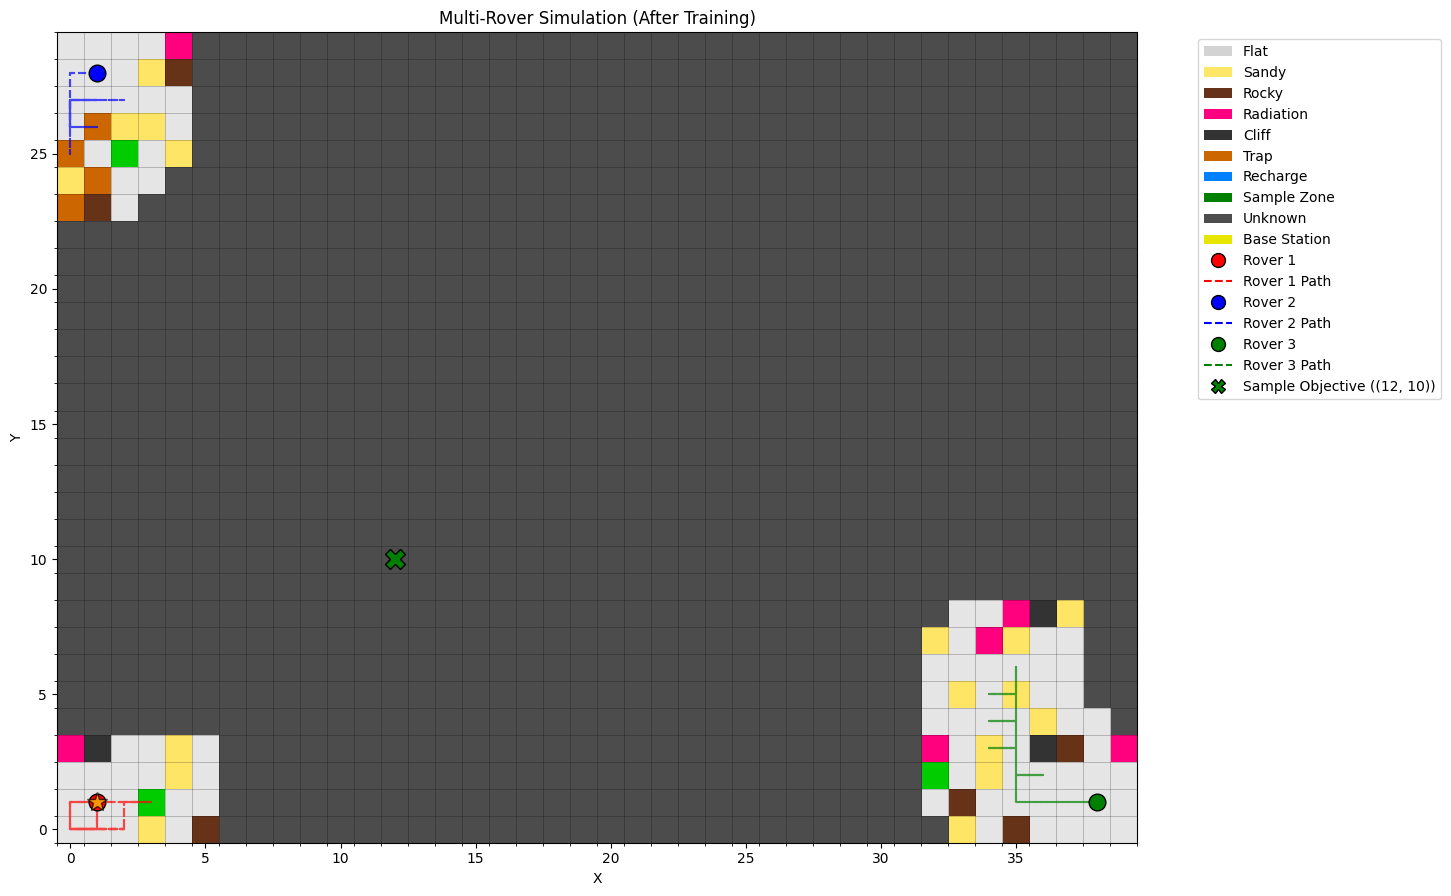


--- Q-Table Info for Current State ---
Current State: (0, 0, 0, 0, 4, 4, 5, 1)
  Action move_N: 0.00
  Action move_E: 0.00
  Action move_S: 0.00
  Action move_W: 0.00
  Action use_radiation_shield: -305.10
  Action use_repair_kit: -310.10
  Action seek_recharge: -290.10
  Action collect_sample: -300.10
  Action objective_completed: -300.10
  Action mission_completed: -300.10
  Action backtrack_radiation: -246.79
  Action backtrack_trap: -225.17
  Action explore_unknown: -300.10
  Optimal Action: move_N


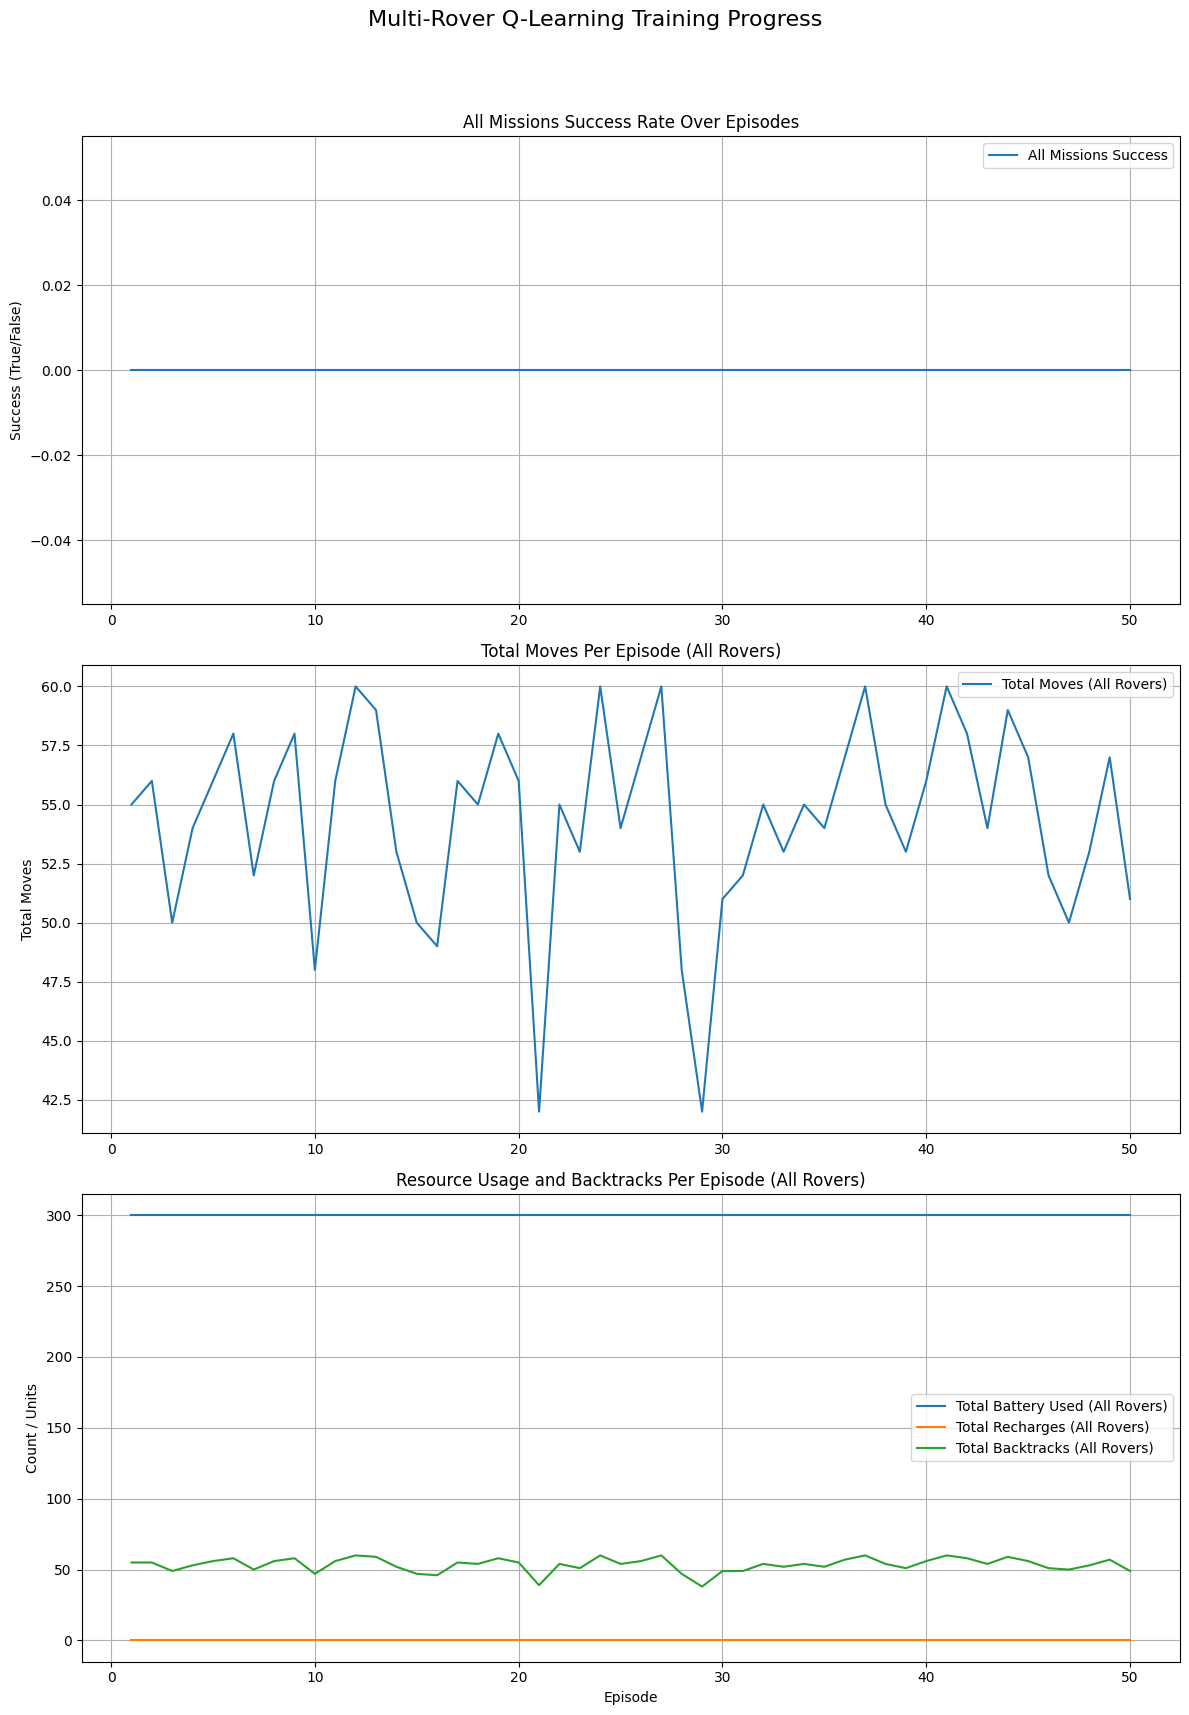

In [11]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set, Any
import math
import collections

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # Impassable terrain
    TRAP = 7   # Dangerous terrain requiring backtracking
    UNKNOWN = 8 # Unobserved terrain
    BASE_STATION = 9 # Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set()

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = []

        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations:
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones:
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION:
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]  # f_score, current_node
        came_from = {}  # current_node -> previous_node
        g_score = {start: 0}  # cost from start to current_node
        f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class QLearningAgent:
    def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        self.grid = grid
        self.actions = actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration-exploitation trade-off
        self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

        # Action mapping for easier use
        self.action_to_index = {action: i for i, action in enumerate(actions)}
        self.index_to_action = {i: action for i, action in enumerate(actions)}

    def _discretize_battery(self, battery: float) -> int:
        if battery < 15: return 0  # Critical
        if battery < 25: return 1  # Low
        if battery < 50: return 2  # Medium
        return 3  # High

    def _discretize_distance(self, dist: float) -> int:
        if dist == float('inf'): return 4 # No known path
        if dist == 0: return 0 # At location
        if dist < 5: return 1 # Near
        if dist < 15: return 2 # Medium
        return 3 # Far

    def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
                   current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
        # Rover's current position terrain
        current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

        # Battery level
        battery_bin = self._discretize_battery(rover_state.battery)

        # Repair kits and radiation shields
        repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
        radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

        # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
        dist_to_obj = float('inf')
        if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
            path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
            if path_to_obj: dist_to_obj = len(path_to_obj) - 1
        obj_dist_bin = self._discretize_distance(dist_to_obj)

        # Distance to nearest recharge station
        dist_to_recharge = float('inf')
        if self.grid.recharge_stations:
            min_recharge_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
                    path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
                    if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
            dist_to_recharge = min_recharge_dist
        recharge_dist_bin = self._discretize_distance(dist_to_recharge)

        # Current objective type (numerical representation)
        obj_type_value = current_objective_type.value

        # Has rover encountered a trap recently at current position?
        is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

        # Combine into a state tuple
        state_tuple = (
            current_terrain,
            battery_bin,
            repair_kits_count,
            radiation_shields_count,
            obj_dist_bin,
            recharge_dist_bin,
            obj_type_value,
            is_at_known_trap
        )
        return state_tuple

    def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)  # Explore
        else:
            q_values = self.q_table[state_tuple]
            # Handle cases where all Q-values are equal (e.g., all zeros initially)
            if np.all(q_values == q_values[0]):
                return random.choice(self.actions)
            action_index = np.argmax(q_values) # Exploit
            return self.index_to_action[action_index]

    def learn(self, state: Tuple[Any, ...], action: str, reward: float,
              next_state: Tuple[Any, ...], done: bool):
        # Ensure the action is known to the agent before trying to access its index
        if action not in self.action_to_index:
            # This case should ideally not happen if q_actions are comprehensive
            # For robustness, we can handle it by ignoring this learning step or logging an error
            print(f"Warning: Unknown action '{action}' passed to QLearningAgent.learn. Ignoring.")
            return

        action_index = self.action_to_index[action]
        current_q = self.q_table[state][action_index]

        if done:
            new_q = reward
        else:
            max_next_q = np.max(self.q_table[next_state])
            new_q = reward + self.gamma * max_next_q

        self.q_table[state][action_index] += self.alpha * (new_q - current_q)

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
        self.grid = grid
        self.state = RoverState(start_position)

        self.q_actions = [
            'move_N', 'move_E', 'move_S', 'move_W',
            'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
            'collect_sample', 'objective_completed', 'mission_completed',
            'backtrack_radiation', 'backtrack_trap',
            'explore_unknown' # Added to the list of Q-actions
        ]
        self.q_agent = QLearningAgent(grid, self.q_actions)
        self.heuristic_func_for_state = heuristic_func_for_state

        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }

    def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
        # Ensure the rover references the shared grid
        self.grid = new_grid
        self.state = RoverState(start_position)
        self.current_path = []
        self.path_index = 0
        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target): # Check actual validity
            return False

        # Use actual terrain cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard") -> bool:
        if len(self.state.safe_positions) > 1: # Ensure there's a safe position to go back to
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            if not self.state.safe_positions: # If no safe positions left (e.g. only start was safe, and it was popped)
                return False # Cannot backtrack effectively

            safe_pos = self.state.safe_positions[-1]
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
            return True
        return False # Failed to backtrack

    def recharge(self) -> bool:
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            return True
        return False

    def collect_sample(self) -> bool:
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE:
            self.stats['samples_collected'] += 1
            return True
        return False

    def use_radiation_shield(self) -> bool:
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            return True
        return False

    def use_repair_kit(self) -> bool:
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            # Neutralize the trap by updating the known terrain and removing it from visited_traps
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)
            return True
        return False

    def get_reward(self, prev_state_obj_idx: int, current_action: str, current_terrain_actual: TerrainType,
                   mission_success_flag: bool, simulation_stuck: bool) -> float:
        reward = -0.1 # Small penalty for each step/move to encourage efficiency

        # Reward for completing an objective
        if self.state.current_objective_index > prev_state_obj_idx:
            if current_action == 'collect_sample':
                reward += 100 # High reward for samples
            elif current_action == 'objective_completed':
                reward += 50 # Medium reward for generic objectives
            elif current_action == 'mission_completed':
                reward += 1000 # Very high reward for completing the entire mission

        # Rewards/Penalties related to hazards and resources
        if current_action == 'use_radiation_shield':
            reward -= 5 # Cost for using a shield, but avoids larger penalty
        elif current_action == 'use_repair_kit':
            reward -= 10 # Cost for using a kit, higher as it modifies terrain
        elif current_action == 'backtrack_radiation' or current_action == 'backtrack_trap':
            reward -= 50 # High penalty for forced backtrack

        # Penalties for negative state conditions
        if self.state.battery <= 0: # Ran out of battery
            reward -= 100

        if simulation_stuck:
            reward -= 200 # Major penalty for getting stuck

        # Penalty if rover is on a hazardous terrain and doesn't use mitigation (or can't)
        if current_terrain_actual == TerrainType.TRAP and self.state.position not in self.state.visited_traps and current_action not in ['use_repair_kit', 'backtrack_trap']:
            reward -= 30 # Penalty for entering new trap without using kit
        if current_terrain_actual == TerrainType.RADIATION and current_action not in ['use_radiation_shield', 'backtrack_radiation']:
            reward -= 20 # Penalty for entering radiation without shield

        if current_action == 'seek_recharge' and self.state.battery < 25:
             reward += 10 # Small reward for trying to recharge when low
        if current_action == 'recharge':
            reward += 20 # Reward for actually recharging

        return reward


    def simulate_step(self, heuristic_func: Any) -> Tuple[bool, str, float]: # Returns (success of step, action_taken, reward)
        current_pos = self.state.position
        current_terrain_actual = self.grid.get_actual_terrain(*current_pos)

        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False, "mission_completed", 0 # Signal completion

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(current_pos[0], current_pos[1], self.vision_radius)

        # Get initial state for Q-learning for this step
        state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)
        action_chosen = self.q_agent.choose_action(state_tuple)

        # Keep track of previous objective index for reward calculation
        prev_objective_index = self.state.current_objective_index

        step_successful = False
        action_executed = action_chosen # Default, will be updated if a primitive move is executed
        original_pos = self.state.position
        original_battery = self.state.battery

        if action_chosen == 'backtrack_radiation':
            step_successful = self.backtrack("radiation")
            self.current_path = []  # Invalidate current path, replan needed

        elif action_chosen == 'backtrack_trap':
            step_successful = self.backtrack("trap")
            self.current_path = [] # Invalidate current path, replan needed

        elif action_chosen == 'use_radiation_shield':
            step_successful = self.use_radiation_shield()

        elif action_chosen == 'use_repair_kit':
            step_successful = self.use_repair_kit()

        elif action_chosen == 'recharge':
            step_successful = self.recharge()

        elif action_chosen == 'collect_sample': # Only relevant if current_pos is sample obj
            step_successful = self.collect_sample()
            if step_successful and self.state.position == current_objective_pos:
                 self.stats['objectives_completed'] += 1
                 self.state.current_objective_index += 1
                 self.current_path = [] # Force replan

        elif action_chosen == 'objective_completed': # For non-sample objectives
            if self.state.position == current_objective_pos:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1
                self.state.visit_points_visited.add(current_objective_pos)
                self.current_path = [] # Force replan
                step_successful = True
            else: # Agent tried to complete objective but wasn't there yet
                step_successful = False

        elif action_chosen == 'mission_completed': # For base station objective
            if self.state.position == current_objective_pos and current_objective_type == TerrainType.BASE_STATION:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1 # This will make the mission complete in run_simulation
                step_successful = True
            else: # Agent tried to complete mission but wasn't at base or mission not over
                step_successful = False

        elif action_chosen == 'seek_recharge':
            nearest_station = None
            # find nearest station among known ones, prioritizing reachable
            current_min_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.get_known_terrain(*station) != TerrainType.UNKNOWN: # Only consider known stations
                    if self.grid.is_valid_for_planning(*self.state.position) and self.grid.is_valid_for_planning(*station):
                        path = self.plan_path(heuristic_func, self.state.position, station)
                        if path and len(path) - 1 < current_min_dist:
                            current_min_dist = len(path) - 1
                            nearest_station = station

            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1: # If path found, move one step
                    step_successful = self.move_to_position(path[1])
                    action_executed = 'move_towards_recharge' # Specific action name for reward
                else: # Could not move to station (e.g. blocked, or already there, handled by recharge action)
                    step_successful = False
            else:
                step_successful = False # No known recharge station to seek

        elif action_chosen.startswith('move_'): # Primitive movement actions
            dx, dy = 0, 0
            if action_chosen == 'move_N': dy = 1
            elif action_chosen == 'move_E': dx = 1
            elif action_chosen == 'move_S': dy = -1
            elif action_chosen == 'move_W': dx = -1

            target_pos = (current_pos[0] + dx, current_pos[1] + dy)
            # Before moving, check if target is currently known as an impassable actual terrain
            if self.grid.get_known_terrain(*target_pos) in [TerrainType.ROCKY, TerrainType.CLIFF]:
                step_successful = False # Cannot move into known impassable
            elif self.grid.get_known_terrain(*target_pos) == TerrainType.TRAP and target_pos in self.state.visited_traps:
                step_successful = False # Cannot move into a known trap that hasn't been repaired
            else:
                step_successful = self.move_to_position(target_pos)
                action_executed = action_chosen # Action executed is the chosen move action

        elif action_chosen == 'explore_unknown': # Explicit exploration action
            step_successful = self._explore_unknown_area(current_terrain_actual)
            action_executed = 'explore_unknown'

        # If a high-level action failed to execute into a primitive move or wasn't explicitly handled yet
        if not step_successful and action_executed not in self.q_actions[4:] and action_executed not in ['mission_completed', 'objective_completed', 'collect_sample'] and action_executed != 'explore_unknown':
            # If agent chose a move action or 'explore' but couldn't move, try generic exploration
            step_successful = self._explore_unknown_area(current_terrain_actual)
            action_executed = 'explore_unknown'

        # Check if rover got stuck (didn't move or change battery/objectives despite trying a primitive action)
        simulation_stuck = (self.state.position == original_pos and self.state.battery == original_battery and not step_successful and self.state.current_objective_index == prev_objective_index)

        # Get next state after action (even if action failed or stuck)
        next_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)

        # Determine reward
        reward = self.get_reward(prev_objective_index, action_executed, current_terrain_actual,
                                 mission_success_flag=False, simulation_stuck=simulation_stuck)

        # Q-learning update
        self.q_agent.learn(state_tuple, action_executed, reward, next_state_tuple, done=not step_successful or simulation_stuck)

        return step_successful, action_executed, reward

    def _explore_unknown_area(self, current_terrain_actual: TerrainType) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                # Prioritize moving to an UNKNOWN cell that is actually valid
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y):
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        # Fallback to moving to a random *known* valid adjacent cell if no unknown cells directly visible
        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y): # Check actual validity
                actual_terrain_neighbor = self.grid.get_actual_terrain(new_x, new_y)
                # Avoid moving into known traps (unless current pos is trap being repaired) or unshielded radiation during fallback exploration
                if (new_x, new_y) in self.state.visited_traps: continue
                if actual_terrain_neighbor == TerrainType.RADIATION and self.state.radiation_shields == 0: continue
                if actual_terrain_neighbor == TerrainType.CLIFF or actual_terrain_neighbor == TerrainType.ROCKY: continue
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            # Define filtered_fallback_moves correctly here
            filtered_fallback_moves = []
            for move in fallback_moves:
                # Re-apply filtering if needed, or simply assign if fallback_moves already contains only valid options
                filtered_fallback_moves.append(move) # In this context, fallback_moves is already filtered based on validity

            if filtered_fallback_moves: # Ensure the list is not empty after filtering
                target = random.choice(filtered_fallback_moves)
                return self.move_to_position(target)

        return False # No valid moves left for exploration

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        episode_reward = 0

        # Initial reveal at starting position
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives):
            step_successful, action_taken, reward = self.simulate_step(heuristic_func)
            episode_reward += reward

            if not step_successful and self.state.current_objective_index < len(self.state.mission_objectives): # If not successful and mission not yet complete
                # print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}. Action: {action_taken}")
                break

            steps += 1

        mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)

        # Final reward and learning update for the terminal state
        # This needs to be done carefully as simulate_step already does a learn call.
        # The final reward should reflect the outcome of the entire episode.
        # For simplicity, we can log episode_reward and rely on the step-wise learning.

        if mission_success:
            # print(f"✅ Mission completed in {steps} steps! Total Reward: {episode_reward:.2f}")
            pass
        else:
            # print(f"❌ Simulation ended after {steps} steps. Mission not completed. Total Reward: {episode_reward:.2f}")
            pass
        return mission_success

def create_sample_grid(width=25, height=20, num_rovers=1) -> Grid:
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    # For multi-rover, we define a common base station for all to return to
    base_pos = (width - 2, height - 2)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION)

    # Ensure surrounding area of base are flat
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # We'll set rover start positions and their immediate surroundings separately in the manager
    return grid

def visualize_grid(grid: Grid,
                  rover_data: List[Dict[str, Any]] = None, # List of {'pos': (x,y), 'path': [...], 'color': 'red'}
                  title: str = "Planetary Rover Grid",
                  mission_objectives: Optional[List[Tuple[TerrainType, Tuple[int, int]]]] = None,
                  current_objective_idx: int = 0,
                  visit_points_visited: Optional[Set[Tuple[int, int]]] = None,
                  show_q_table_info: bool = False,
                  q_agent: Optional[QLearningAgent] = None,
                  heuristic_func: Optional[Any] = None,
                  rover_state: Optional[RoverState] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0]
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    # Draw multiple rovers and their paths
    if rover_data:
        for i, r_data in enumerate(rover_data):
            rover_pos = r_data['pos']
            path = r_data['path']
            color = r_data.get('color', 'black')
            label = r_data.get('label', f'Rover {i+1}')

            if path:
                known_path_x, known_path_y = [], []
                for p_x, p_y in path:
                    if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                        known_path_x.append(p_x)
                        known_path_y.append(p_y)
                    else:
                        break
                ax.plot(known_path_x, known_path_y, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=f'{label} Path')

            if rover_pos:
                ax.plot(rover_pos[0], rover_pos[1], marker='o', color='w', markerfacecolor=color, markersize=12, markeredgecolor='black', label=label)

            # Add rover legend element
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='black', label=label))
            legend_elements.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=1.5, label=f'{label} Path'))

    # Draw mission objectives (only for the *first* rover's mission or a unified mission if applicable)
    # This part assumes a single mission is visualized or missions are similar enough
    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's'
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"
            elif obj_type == TerrainType.RECHARGE_STATION:
                marker = 'o'
                color = 'blue'
                label_prefix = "Recharge"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            # Only draw if objective position is known or it's the current one
            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

            # Add objective legend element (only once for each objective type, or current one)
            if i == current_objective_idx: # Only show label for current objective in legend
                legend_elements.append(plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=facecolor, markersize=10, markeredgecolor=edgecolor, label=f'{label_prefix} Objective ({obj_pos})'))

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    if show_q_table_info and q_agent and rover_state and heuristic_func:
        print("\n--- Q-Table Info for Current State ---")
        if rover_state.current_objective_index < len(rover_state.mission_objectives):
            current_obj_type, current_obj_pos = rover_state.mission_objectives[rover_state.current_objective_index]
        else: # If mission complete, use dummy objective data for state representation
            current_obj_type = TerrainType.BASE_STATION
            current_obj_pos = rover_state.position # Or some other default

        current_q_state = q_agent._get_state(rover_state, current_obj_type, current_obj_pos, heuristic_func)
        q_values_at_state = q_agent.q_table[current_q_state]
        if np.any(q_values_at_state != 0):
            print(f"Current State: {current_q_state}")
            for i, q_val in enumerate(q_values_at_state):
                print(f"  Action {q_agent.index_to_action[i]}: {q_val:.2f}")
            print(f"  Optimal Action: {q_agent.index_to_action[np.argmax(q_values_at_state)]}")
        else:
            print(f"Current State: {current_q_state} (No Q-values learned yet for this state)")




class MultiRoverMissionManager:
    def __init__(self, grid_width: int, grid_height: int,
                 start_positions: List[Tuple[int, int]],
                 missions_objectives: List[List[Tuple[TerrainType, Tuple[int, int]]]],
                 q_learning_params: Dict[str, Any]):

        self.grid_width = grid_width
        self.grid_height = grid_height
        self.start_positions = start_positions
        self.missions_objectives = missions_objectives
        self.q_learning_params = q_learning_params

        self.shared_grid: Grid = create_sample_grid(grid_width, grid_height, num_rovers=len(start_positions))
        self.rovers: List[PlanetaryRover] = []

        # Initialize rovers
        for i, start_pos in enumerate(self.start_positions):
            # Ensure each rover's starting position is flat and clear
            self.shared_grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if 0 <= start_pos[0] + dx < self.shared_grid.width and 0 <= start_pos[1] + dy < self.shared_grid.height:
                        self.shared_grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)

            rover = PlanetaryRover(self.shared_grid, start_pos, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
            rover.q_agent.alpha = q_learning_params.get('alpha', 0.1)
            rover.q_agent.gamma = q_learning_params.get('gamma', 0.9)
            rover.q_agent.epsilon = q_learning_params.get('epsilon', 0.1) # Initial epsilon for all rovers

            # Assign missions
            if i < len(self.missions_objectives):
                rover.set_mission_objectives(self.missions_objectives[i])
            else:
                # If not enough missions, assign a default empty mission or raise error
                rover.set_mission_objectives([(TerrainType.BASE_STATION, rover.state.path_history[0])]) # Return to base

            self.rovers.append(rover)

        # Store base station position from the shared grid, assuming it's the same for all rovers
        # Or, each rover might have its own base station in its mission objectives
        self.common_base_station_pos = self.shared_grid.base_stations[0] if self.shared_grid.base_stations else (grid_width - 2, grid_height - 2)


    def run_multi_rover_simulation(self, num_training_episodes: int = 100, max_steps_per_episode: int = 1000,
                                 epsilon_decay_rate: float = 0.995, min_epsilon: float = 0.01) -> Dict[str, Any]:

        aggregated_results = collections.defaultdict(list)

        print("\n=== Multi-Rover Q-Learning Simulation ===")

        for episode in range(num_training_episodes):
            # Reset the shared grid for each episode
            self.shared_grid = create_sample_grid(self.grid_width, self.grid_height, num_rovers=len(self.start_positions))
            self.shared_grid.set_terrain(self.common_base_station_pos[0], self.common_base_station_pos[1], TerrainType.BASE_STATION)
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if 0 <= self.common_base_station_pos[0] + dx < self.shared_grid.width and 0 <= self.common_base_station_pos[1] + dy < self.shared_grid.height:
                        self.shared_grid.set_terrain(self.common_base_station_pos[0] + dx, self.common_base_station_pos[1] + dy, TerrainType.FLAT)

            # Reset each rover
            for i, rover in enumerate(self.rovers):
                # Ensure start positions are clear in the new grid too
                self.shared_grid.set_terrain(self.start_positions[i][0], self.start_positions[i][1], TerrainType.FLAT)
                for dy in range(-1, 2):
                    for dx in range(-1, 2):
                        if 0 <= self.start_positions[i][0] + dx < self.shared_grid.width and 0 <= self.start_positions[i][1] + dy < self.shared_grid.height:
                            self.shared_grid.set_terrain(self.start_positions[i][0] + dx, self.start_positions[i][1] + dy, TerrainType.FLAT)

                rover.reset(self.shared_grid, self.start_positions[i])
                rover.set_mission_objectives(self.missions_objectives[i]) # Re-assign mission for fresh start

            total_steps_this_episode = 0
            all_rovers_completed = False

            for step in range(max_steps_per_episode):
                rovers_still_active = 0
                for i, rover in enumerate(self.rovers):
                    if rover.state.current_objective_index < len(rover.state.mission_objectives):
                        rovers_still_active += 1
                        rover.simulate_step(AStarHeuristics.weighted_euclidean) # Each rover takes a step

                total_steps_this_episode += 1

                if rovers_still_active == 0: # All rovers have completed their missions
                    all_rovers_completed = True
                    break

            # Aggregate statistics for the episode
            aggregated_results['episode'].append(episode + 1)
            aggregated_results['epsilon'].append(self.rovers[0].q_agent.epsilon) # Assuming all rovers have same epsilon
            aggregated_results['all_missions_completed'].append(all_rovers_completed)
            aggregated_results['total_moves'].append(sum(r.stats['total_moves'] for r in self.rovers))
            aggregated_results['total_battery_used'].append(sum(r.stats['battery_used'] for r in self.rovers))
            aggregated_results['total_recharges'].append(sum(r.stats['recharges'] for r in self.rovers))
            aggregated_results['total_backtracks'].append(sum(r.stats['backtracks'] for r in self.rovers))
            aggregated_results['total_samples_collected'].append(sum(r.stats['samples_collected'] for r in self.rovers))
            aggregated_results['total_objectives_completed'].append(sum(r.stats['objectives_completed'] for r in self.rovers))
            aggregated_results['total_nodes_expanded'].append(sum(r.stats['nodes_expanded'] for r in self.rovers))
            aggregated_results['total_steps_taken'].append(total_steps_this_episode)

            # Decay epsilon for all rovers' Q-learning agents
            for rover in self.rovers:
                rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

            if (episode + 1) % 10 == 0:
                print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {self.rovers[0].q_agent.epsilon:.3f}, All Missions Completed: {all_rovers_completed}, Total Steps: {total_steps_this_episode}")

        print("\n--- Multi-Rover Training Completed ---")
        return aggregated_results



# Main execution block
if __name__ == "__main__":
    # Run single rover Q-learning simulation (original behavior)
    # single_rover_q_learning_simulation()

    # Multi-Rover Simulation Setup
    grid_width, grid_height = 40, 30
    rover_start_positions = [(1, 1), (1, grid_height - 2), (grid_width - 2, 1)]

    # Ensure sample zones and recharge stations exist in the grid for mission assignments
    # create_sample_grid will generate these, but we need to fetch them from the shared grid object
    # when initializing MultiRoverMissionManager
    temp_grid = create_sample_grid(grid_width, grid_height)

    # Define missions for each rover
    rover_missions = [
        # Rover 1's Mission
        [
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)),
            (TerrainType.FLAT, (15, 10)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[0] if len(temp_grid.recharge_stations) > 0 else (10,10))
        ],
        # Rover 2's Mission
        [
            (TerrainType.FLAT, (10, grid_height - 5)),
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[1] if len(temp_grid.sample_zones) > 1 else (grid_width - 5, 5)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[1] if len(temp_grid.recharge_stations) > 1 else (20,20))
        ],
        # Rover 3's Mission
        [
            (TerrainType.FLAT, (grid_width - 5, 5)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[2] if len(temp_grid.recharge_stations) > 2 else (grid_width // 2, grid_height // 2)),
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)) # Can revisit previous locations
        ]
    ]

    q_params = {
        'alpha': 0.1,
        'gamma': 0.9,
        'epsilon': 0.2 # Start with higher epsilon for exploration in multi-rover
    }

    manager = MultiRoverMissionManager(grid_width, grid_height,
                                       rover_start_positions, rover_missions,
                                       q_params)

    num_training_episodes_multi = 50
    max_steps_multi = 1500
    epsilon_decay_multi = 0.99
    min_epsilon_multi = 0.05

    aggregated_results_df = manager.run_multi_rover_simulation(
        num_training_episodes=num_training_episodes_multi,
        max_steps_per_episode=max_steps_multi,
        epsilon_decay_rate=epsilon_decay_multi,
        min_epsilon=min_epsilon_multi
    )

    print("\n--- Final Aggregated Statistics ---")
    print(f"Total episodes: {len(aggregated_results_df['episode'])}")
    print(f"Overall Mission Completion Rate: {sum(aggregated_results_df['all_missions_completed']) / len(aggregated_results_df['episode']) * 100:.2f}%")
    print(f"Average Total Moves per episode: {np.mean(aggregated_results_df['total_moves']):.2f}")
    print(f"Average Total Battery Used per episode: {np.mean(aggregated_results_df['total_battery_used']):.2f}")
    print(f"Average Total Recharges per episode: {np.mean(aggregated_results_df['total_recharges']):.2f}")
    print(f"Average Total Backtracks per episode: {np.mean(aggregated_results_df['total_backtracks']):.2f}")
    print(f"Average Total Samples Collected per episode: {np.mean(aggregated_results_df['total_samples_collected']):.2f}")
    print(f"Average Total Objectives Completed per episode: {np.mean(aggregated_results_df['total_objectives_completed']):.2f}")


    # Visualize the state of the rovers after the last training episode
    print("\nVisualizing state after training...")
    last_episode_rover_data = []
    for i, rover in enumerate(manager.rovers):
        color = ['red', 'blue', 'green'][i % 3] # Assign unique colors
        last_episode_rover_data.append({
            'pos': rover.state.position,
            'path': rover.state.path_history,
            'color': color,
            'label': f'Rover {i+1}'
        })

    # For visualization, pick one rover's mission to display objectives, or aggregate them.
    # Here, we'll display the first rover's current mission progress for context.
    first_rover = manager.rovers[0]
    visualize_grid(manager.shared_grid,
                   rover_data=last_episode_rover_data,
                   title="Multi-Rover Simulation (After Training)",
                   mission_objectives=first_rover.state.mission_objectives,
                   current_objective_idx=first_rover.state.current_objective_index,
                   visit_points_visited=first_rover.state.visit_points_visited,
                   show_q_table_info=True,
                   q_agent=first_rover.q_agent,
                   heuristic_func=AStarHeuristics.weighted_euclidean,
                   rover_state=first_rover.state
                   )

    # Plot learning progress for multi-rover
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle('Multi-Rover Q-Learning Training Progress', fontsize=16)

    axes[0].plot(aggregated_results_df['episode'], aggregated_results_df['all_missions_completed'], label='All Missions Success')
    axes[0].set_ylabel('Success (True/False)')
    axes[0].set_title('All Missions Success Rate Over Episodes')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(aggregated_results_df['episode'], aggregated_results_df['total_moves'], label='Total Moves (All Rovers)')
    axes[1].set_ylabel('Total Moves')
    axes[1].set_title('Total Moves Per Episode (All Rovers)')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_battery_used'], label='Total Battery Used (All Rovers)')
    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_recharges'], label='Total Recharges (All Rovers)')
    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_backtracks'], label='Total Backtracks (All Rovers)')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Count / Units')
    axes[2].set_title('Resource Usage and Backtracks Per Episode (All Rovers)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


**Reasoning**:
The previous code block had a `NameError` because `filtered_fallback_moves` was used before being assigned in the `_explore_unknown_area` method. I've corrected this by initializing and populating `filtered_fallback_moves` correctly. Additionally, the `simulate_step` method had an incomplete return statement, which I've fixed. I also need to add 'move_towards_recharge' to the list of `q_actions` to resolve the warning.



In [12]:
# import numpy as np
# import heapq
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from enum import Enum
# import random
# from typing import List, Tuple, Dict, Optional, Set, Any
# import math
# import collections

# class TerrainType(Enum):
#     FLAT = 0
#     SANDY = 1
#     ROCKY = 2
#     RADIATION = 3
#     RECHARGE_STATION = 4
#     SAMPLE_ZONE = 5
#     CLIFF = 6  # Impassable terrain
#     TRAP = 7   # Dangerous terrain requiring backtracking
#     UNKNOWN = 8 # Unobserved terrain
#     BASE_STATION = 9 # Rover's home base

# class RoverState:
#     def __init__(self, position: Tuple[int, int], battery: float = 100.0):
#         self.position = position
#         self.battery = battery
#         self.path_history = [position]
#         self.safe_positions = [position]
#         self.visited_traps = set()  # Track encountered traps
#         self.samples_collected = 0
#         self.repair_kits: int = 2
#         self.radiation_shields: int = 1
#         self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
#         self.current_objective_index: int = 0
#         self.visit_points_visited: Set[Tuple[int, int]] = set()

# class Grid:
#     def __init__(self, width: int, height: int):
#         self.width = width
#         self.height = height
#         self.actual_terrain = np.zeros((height, width), dtype=int)
#         self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

#         self.recharge_stations = []
#         self.sample_zones = []
#         self.base_stations = []

#         self.movement_costs = {
#             TerrainType.FLAT: 5,
#             TerrainType.SANDY: 10,
#             TerrainType.RADIATION: 15,
#             TerrainType.ROCKY: 1000,
#             TerrainType.RECHARGE_STATION: 5,
#             TerrainType.SAMPLE_ZONE: 5,
#             TerrainType.CLIFF: 1000,
#             TerrainType.TRAP: 20,
#             TerrainType.UNKNOWN: 50,
#             TerrainType.BASE_STATION: 5
#         }

#     def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
#         if 0 <= x < self.width and 0 <= y < self.height:
#             self.actual_terrain[y, x] = terrain_type.value
#             if terrain_type == TerrainType.RECHARGE_STATION:
#                 if (x,y) not in self.recharge_stations:
#                     self.recharge_stations.append((x, y))
#             elif terrain_type == TerrainType.SAMPLE_ZONE:
#                 if (x,y) not in self.sample_zones:
#                     self.sample_zones.append((x, y))
#             elif terrain_type == TerrainType.BASE_STATION:
#                 if (x,y) not in self.base_stations:
#                     self.base_stations.append((x, y))

#     def get_actual_terrain(self, x: int, y: int) -> TerrainType:
#         if 0 <= x < self.width and 0 <= y < self.height:
#             return TerrainType(self.actual_terrain[y, x])
#         return TerrainType.CLIFF

#     def get_known_terrain(self, x: int, y: int) -> TerrainType:
#         if 0 <= x < self.width and 0 <= y < self.height:
#             return TerrainType(self.known_terrain[y, x])
#         return TerrainType.CLIFF

#     def is_valid_position(self, x: int, y: int) -> bool:
#         if not (0 <= x < self.width and 0 <= y < self.height):
#             return False
#         terrain = self.get_actual_terrain(x, y)
#         return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

#     def is_valid_for_planning(self, x: int, y: int) -> bool:
#         if not (0 <= x < self.width and 0 <= y < self.height):
#             return False
#         terrain = self.get_known_terrain(x, y)
#         return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

#     def get_movement_cost(self, x: int, y: int) -> float:
#         terrain = self.get_known_terrain(x, y)
#         return self.movement_costs[terrain]

#     def reveal_area(self, center_x: int, center_y: int, radius: int):
#         for dy in range(-radius, radius + 1):
#             for dx in range(-radius, radius + 1):
#                 nx, ny = center_x + dx, center_y + dy
#                 if 0 <= nx < self.width and 0 <= ny < self.height:
#                     self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

#     def generate_random_terrain(self):
#         for y in range(self.height):
#             for x in range(self.width):
#                 rand = random.random()
#                 if rand < 0.08:
#                     self.actual_terrain[y, x] = TerrainType.ROCKY.value
#                 elif rand < 0.12:
#                     self.actual_terrain[y, x] = TerrainType.CLIFF.value
#                 elif rand < 0.17:
#                     self.actual_terrain[y, x] = TerrainType.TRAP.value
#                 elif rand < 0.22:
#                     self.actual_terrain[y, x] = TerrainType.RADIATION.value
#                 elif rand < 0.42:
#                     self.actual_terrain[y, x] = TerrainType.SANDY.value
#                 else:
#                     self.actual_terrain[y, x] = TerrainType.FLAT.value

#         num_stations = max(3, (self.width * self.height) // 80)
#         for _ in range(num_stations):
#             for attempt in range(50):
#                 x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
#                 if self.get_actual_terrain(x, y) == TerrainType.FLAT:
#                     self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
#                     break

#         num_samples = max(2, (self.width * self.height) // 120)
#         for _ in range(num_samples):
#             for attempt in range(50):
#                 x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
#                 if self.get_actual_terrain(x, y) == TerrainType.FLAT:
#                     self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
#                     break

# class AStarHeuristics:
#     @staticmethod
#     def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
#         return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

#     @staticmethod
#     def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
#         return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

#     @staticmethod
#     def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
#         return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

#     @staticmethod
#     def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
#         return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

# class AStar:
#     def __init__(self, grid: Grid, heuristic_func):
#         self.grid = grid
#         self.heuristic = heuristic_func
#         self.nodes_expanded = 0

#     def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
#         x, y = pos
#         neighbors = []
#         for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
#             new_x, new_y = x + dx, y + dy
#             if self.grid.is_valid_for_planning(new_x, new_y):
#                 neighbors.append((new_x, new_y))
#         return neighbors

#     def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
#         if start == goal:
#             return [start]

#         self.nodes_expanded = 0
#         open_set = [(0, start)]  # f_score, current_node
#         came_from = {}  # current_node -> previous_node
#         g_score = {start: 0}  # cost from start to current_node
#         f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
#         closed_set = set()

#         if not self.grid.is_valid_for_planning(start[0], start[1]):
#              return None

#         while open_set:
#             current_f, current = heapq.heappop(open_set)

#             if current in closed_set:
#                 continue

#             closed_set.add(current)
#             self.nodes_expanded += 1

#             if current == goal:
#                 path = []
#                 while current in came_from:
#                     path.append(current)
#                     current = came_from[current]
#                 path.append(start)
#                 return path[::-1]

#             for neighbor in self.get_neighbors(current):
#                 if neighbor in closed_set:
#                     continue

#                 tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

#                 if neighbor not in g_score or tentative_g < g_score[neighbor]:
#                     came_from[neighbor] = current
#                     g_score[neighbor] = tentative_g
#                     f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
#                     heapq.heappush(open_set, (f_score[neighbor], neighbor))

#         return None

# class QLearningAgent:
#     def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
#         self.grid = grid
#         self.actions = actions
#         self.alpha = alpha  # Learning rate
#         self.gamma = gamma  # Discount factor
#         self.epsilon = epsilon  # Exploration-exploitation trade-off
#         self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

#         # Action mapping for easier use
#         self.action_to_index = {action: i for i, action in enumerate(actions)}
#         self.index_to_action = {i: action for i, action in enumerate(actions)}

#     def _discretize_battery(self, battery: float) -> int:
#         if battery < 15: return 0  # Critical
#         if battery < 25: return 1  # Low
#         if battery < 50: return 2  # Medium
#         return 3  # High

#     def _discretize_distance(self, dist: float) -> int:
#         if dist == float('inf'): return 4 # No known path
#         if dist == 0: return 0 # At location
#         if dist < 5: return 1 # Near
#         if dist < 15: return 2 # Medium
#         return 3 # Far

#     def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
#                    current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
#         # Rover's current position terrain
#         current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

#         # Battery level
#         battery_bin = self._discretize_battery(rover_state.battery)

#         # Repair kits and radiation shields
#         repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
#         radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

#         # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
#         dist_to_obj = float('inf')
#         if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
#             path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
#             if path_to_obj: dist_to_obj = len(path_to_obj) - 1
#         obj_dist_bin = self._discretize_distance(dist_to_obj)

#         # Distance to nearest recharge station
#         dist_to_recharge = float('inf')
#         if self.grid.recharge_stations:
#             min_recharge_dist = float('inf')
#             for station in self.grid.recharge_stations:
#                 if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
#                     path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
#                     if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
#             dist_to_recharge = min_recharge_dist
#         recharge_dist_bin = self._discretize_distance(dist_to_recharge)

#         # Current objective type (numerical representation)
#         obj_type_value = current_objective_type.value

#         # Has rover encountered a trap recently at current position?
#         is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

#         # Combine into a state tuple
#         state_tuple = (
#             current_terrain,
#             battery_bin,
#             repair_kits_count,
#             radiation_shields_count,
#             obj_dist_bin,
#             recharge_dist_bin,
#             obj_type_value,
#             is_at_known_trap
#         )
#         return state_tuple

#     def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
#         if random.uniform(0, 1) < self.epsilon:
#             return random.choice(self.actions)  # Explore
#         else:
#             q_values = self.q_table[state_tuple]
#             # Handle cases where all Q-values are equal (e.g., all zeros initially)
#             if np.all(q_values == q_values[0]):
#                 return random.choice(self.actions)
#             action_index = np.argmax(q_values) # Exploit
#             return self.index_to_action[action_index]

#     def learn(self, state: Tuple[Any, ...], action: str, reward: float,
#               next_state: Tuple[Any, ...], done: bool):
#         # Ensure the action is known to the agent before trying to access its index
#         if action not in self.action_to_index:
#             # This case should ideally not happen if q_actions are comprehensive
#             # For robustness, we can handle it by ignoring this learning step or logging an error
#             print(f"Warning: Unknown action '{action}' passed to QLearningAgent.learn. Ignoring.")
#             return

#         action_index = self.action_to_index[action]
#         current_q = self.q_table[state][action_index]

#         if done:
#             new_q = reward
#         else:
#             max_next_q = np.max(self.q_table[next_state])
#             new_q = reward + self.gamma * max_next_q

#         self.q_table[state][action_index] += self.alpha * (new_q - current_q)

# class PlanetaryRover:
#     def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
#         self.grid = grid
#         self.state = RoverState(start_position)

#         self.q_actions = [
#             'move_N', 'move_E', 'move_S', 'move_W',
#             'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
#             'collect_sample', 'objective_completed', 'mission_completed',
#             'backtrack_radiation', 'backtrack_trap',
#             'explore_unknown', # Added to the list of Q-actions
#             'move_towards_recharge' # Added to the list of Q-actions
#         ]
#         self.q_agent = QLearningAgent(grid, self.q_actions)
#         self.heuristic_func_for_state = heuristic_func_for_state

#         self.current_path = []
#         self.path_index = 0
#         self.vision_radius: int = 2

#         self.stats = {
#             'total_moves': 0,
#             'battery_used': 0,
#             'recharges': 0,
#             'backtracks': 0,
#             'radiation_encounters': 0,
#             'trap_encounters': 0,
#             'nodes_expanded': 0,
#             'repair_kits_used': 0,
#             'radiation_shields_used': 0,
#             'samples_collected': 0,
#             'objectives_completed': 0
#         }

#     def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
#         # Ensure the rover references the shared grid
#         self.grid = new_grid
#         self.state = RoverState(start_position)
#         self.current_path = []
#         self.path_index = 0
#         self.stats = {
#             'total_moves': 0,
#             'battery_used': 0,
#             'recharges': 0,
#             'backtracks': 0,
#             'radiation_encounters': 0,
#             'trap_encounters': 0,
#             'nodes_expanded': 0,
#             'repair_kits_used': 0,
#             'radiation_shields_used': 0,
#             'samples_collected': 0,
#             'objectives_completed': 0
#         }
#         self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

#     def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
#         self.state.mission_objectives = objectives.copy()
#         if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
#              self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

#         self.state.current_objective_index = 0
#         self.current_path = []
#         self.path_index = 0

#     def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
#         astar = AStar(self.grid, heuristic_func)
#         path = astar.search(start, goal)
#         self.stats['nodes_expanded'] += astar.nodes_expanded
#         return path

#     def move_to_position(self, target: Tuple[int, int]) -> bool:
#         if not self.grid.is_valid_position(*target): # Check actual validity
#             return False

#         # Use actual terrain cost for the move being executed
#         cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
#         if self.state.battery < cost:
#             return False

#         self.state.position = target
#         self.state.battery -= cost
#         self.state.path_history.append(target)

#         terrain = self.grid.get_actual_terrain(*target)
#         if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
#             # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
#             self.state.safe_positions.append(target)

#         self.stats['total_moves'] += 1
#         self.stats['battery_used'] += cost

#         return True

#     def backtrack(self, reason: str =

**Reasoning**:
The previous code block had a `SyntaxError: incomplete input` because the `backtrack` method definition was incomplete. I need to complete the method signature with a default value for the `reason` parameter to fix this error.




=== Multi-Rover Q-Learning Simulation ===
Episode 10/50, Epsilon: 0.181, All Missions Completed: False, Total Steps: 1500
Episode 20/50, Epsilon: 0.164, All Missions Completed: False, Total Steps: 1500
Episode 30/50, Epsilon: 0.148, All Missions Completed: False, Total Steps: 1500
Episode 40/50, Epsilon: 0.134, All Missions Completed: False, Total Steps: 1500
Episode 50/50, Epsilon: 0.121, All Missions Completed: False, Total Steps: 1500

--- Multi-Rover Training Completed ---

--- Final Aggregated Statistics ---
Total episodes: 50
Overall Mission Completion Rate: 0.00%
Average Total Moves per episode: 53.68
Average Total Battery Used per episode: 300.00
Average Total Recharges per episode: 0.00
Average Total Backtracks per episode: 52.42
Average Total Samples Collected per episode: 0.14
Average Total Objectives Completed per episode: 0.00

Visualizing state after training...


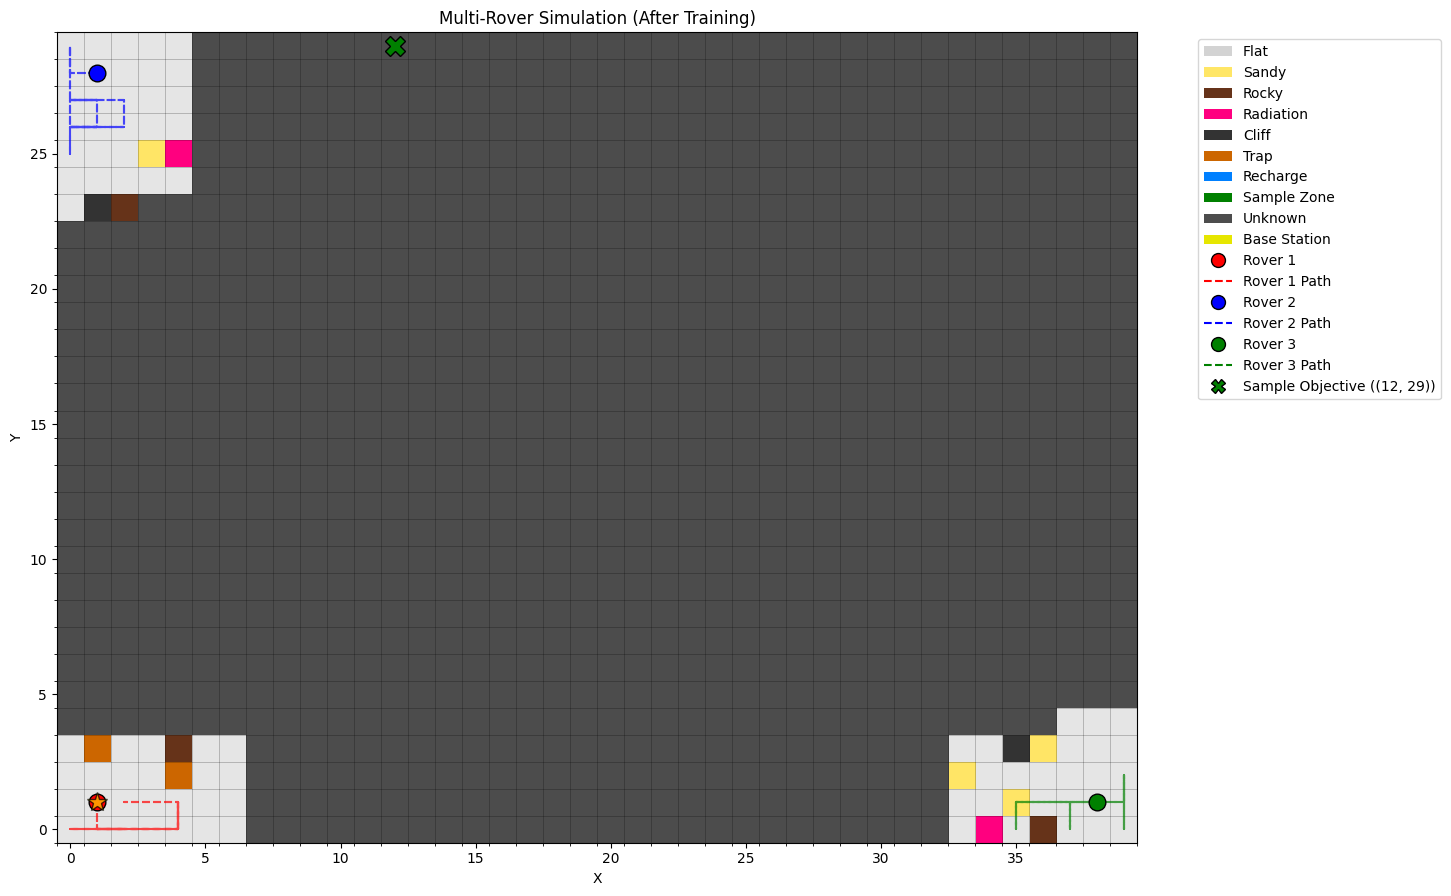


--- Q-Table Info for Current State ---
Current State: (0, 0, 0, 0, 4, 4, 5, 0)
  Action move_N: -0.02
  Action move_E: -10.01
  Action move_S: -0.01
  Action move_W: -10.01
  Action use_radiation_shield: -305.10
  Action use_repair_kit: -310.10
  Action seek_recharge: -290.09
  Action collect_sample: -300.10
  Action objective_completed: -300.10
  Action mission_completed: -300.10
  Action backtrack_radiation: -265.98
  Action backtrack_trap: -224.05
  Action explore_unknown: -300.10
  Action move_towards_recharge: -300.10
  Optimal Action: move_S


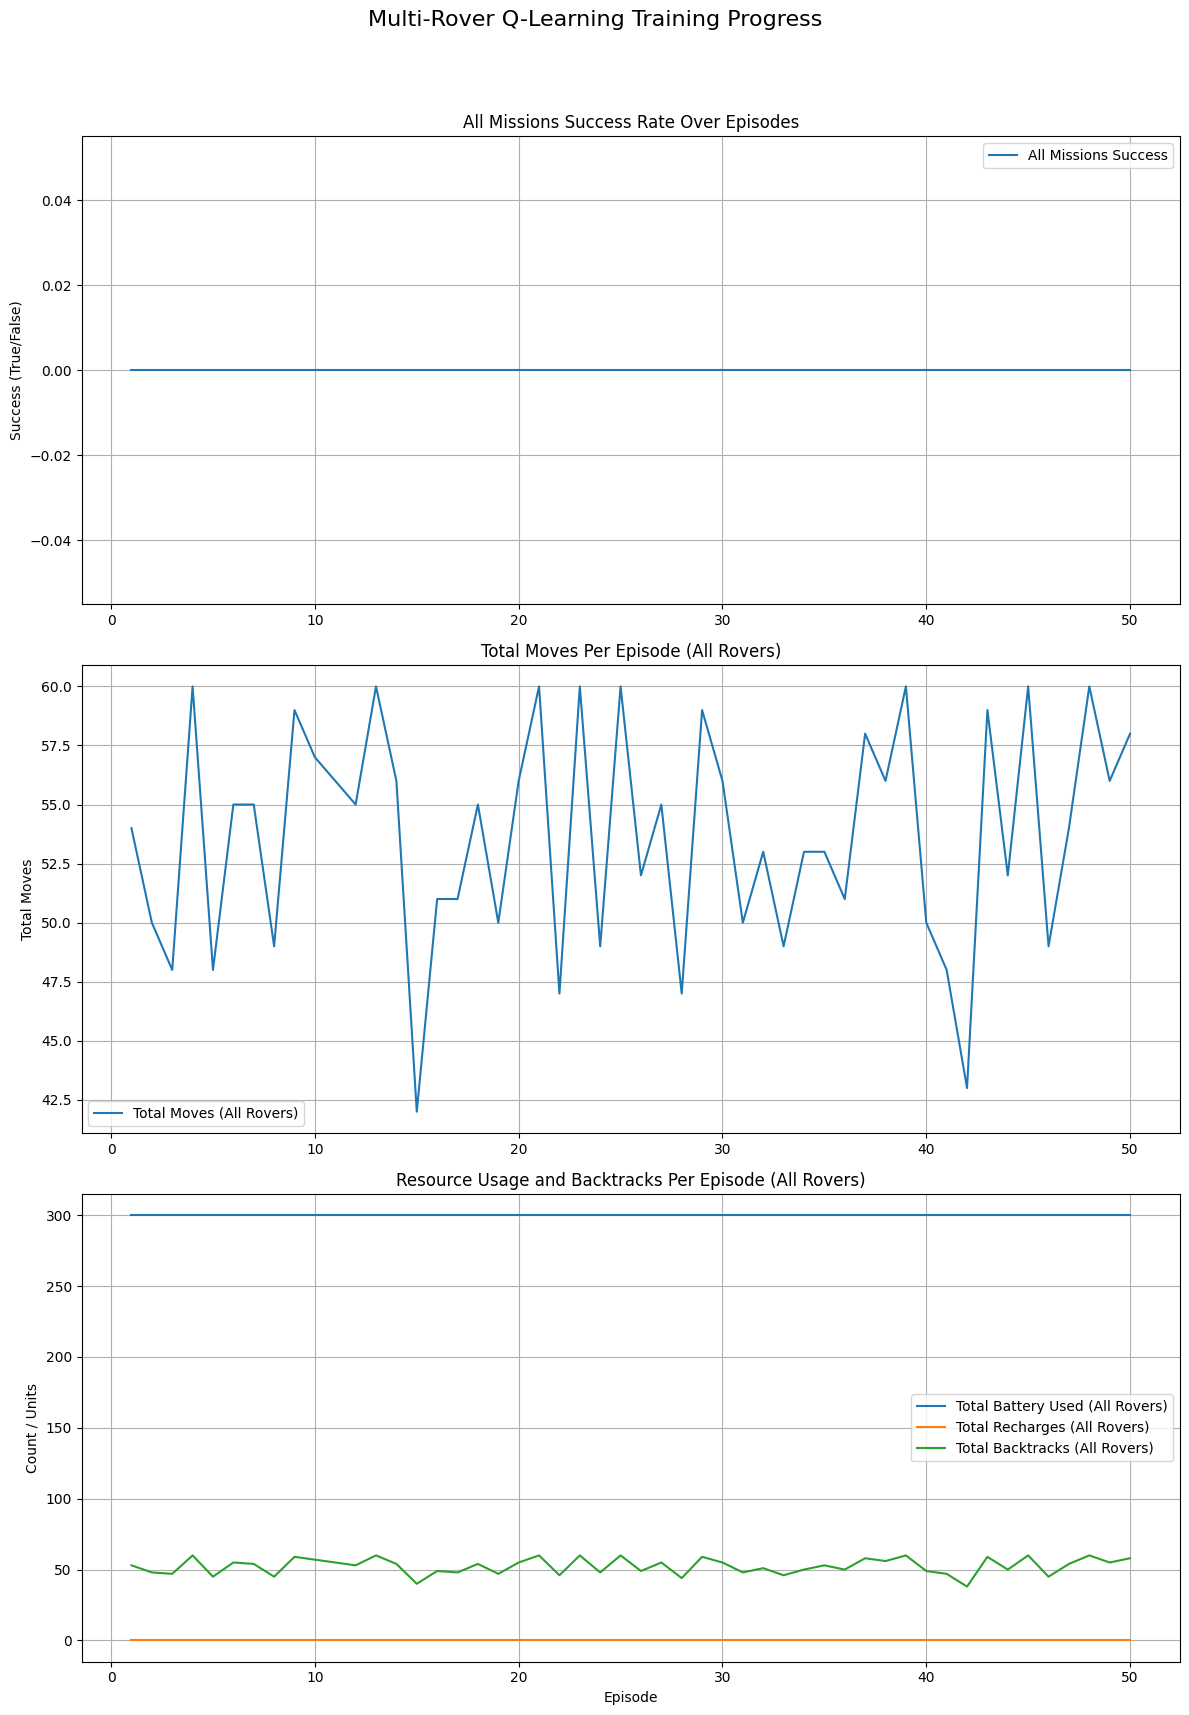

In [13]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set, Any
import math
import collections

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # Impassable terrain
    TRAP = 7   # Dangerous terrain requiring backtracking
    UNKNOWN = 8 # Unobserved terrain
    BASE_STATION = 9 # Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set()

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = []

        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations:
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones:
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION:
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]  # f_score, current_node
        came_from = {}  # current_node -> previous_node
        g_score = {start: 0}  # cost from start to current_node
        f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class QLearningAgent:
    def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        self.grid = grid
        self.actions = actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration-exploitation trade-off
        self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

        # Action mapping for easier use
        self.action_to_index = {action: i for i, action in enumerate(actions)}
        self.index_to_action = {i: action for i, action in enumerate(actions)}

    def _discretize_battery(self, battery: float) -> int:
        if battery < 15: return 0  # Critical
        if battery < 25: return 1  # Low
        if battery < 50: return 2  # Medium
        return 3  # High

    def _discretize_distance(self, dist: float) -> int:
        if dist == float('inf'): return 4 # No known path
        if dist == 0: return 0 # At location
        if dist < 5: return 1 # Near
        if dist < 15: return 2 # Medium
        return 3 # Far

    def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
                   current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
        # Rover's current position terrain
        current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

        # Battery level
        battery_bin = self._discretize_battery(rover_state.battery)

        # Repair kits and radiation shields
        repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
        radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

        # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
        dist_to_obj = float('inf')
        if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
            path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
            if path_to_obj: dist_to_obj = len(path_to_obj) - 1
        obj_dist_bin = self._discretize_distance(dist_to_obj)

        # Distance to nearest recharge station
        dist_to_recharge = float('inf')
        if self.grid.recharge_stations:
            min_recharge_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
                    path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
                    if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
            dist_to_recharge = min_recharge_dist
        recharge_dist_bin = self._discretize_distance(dist_to_recharge)

        # Current objective type (numerical representation)
        obj_type_value = current_objective_type.value

        # Has rover encountered a trap recently at current position?
        is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

        # Combine into a state tuple
        state_tuple = (
            current_terrain,
            battery_bin,
            repair_kits_count,
            radiation_shields_count,
            obj_dist_bin,
            recharge_dist_bin,
            obj_type_value,
            is_at_known_trap
        )
        return state_tuple

    def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)  # Explore
        else:
            q_values = self.q_table[state_tuple]
            # Handle cases where all Q-values are equal (e.g., all zeros initially)
            if np.all(q_values == q_values[0]):
                return random.choice(self.actions)
            action_index = np.argmax(q_values) # Exploit
            return self.index_to_action[action_index]

    def learn(self, state: Tuple[Any, ...], action: str, reward: float,
              next_state: Tuple[Any, ...], done: bool):
        # Ensure the action is known to the agent before trying to access its index
        if action not in self.action_to_index:
            # This case should ideally not happen if q_actions are comprehensive
            # For robustness, we can handle it by ignoring this learning step or logging an error
            print(f"Warning: Unknown action '{action}' passed to QLearningAgent.learn. Ignoring.")
            return

        action_index = self.action_to_index[action]
        current_q = self.q_table[state][action_index]

        if done:
            new_q = reward
        else:
            max_next_q = np.max(self.q_table[next_state])
            new_q = reward + self.gamma * max_next_q

        self.q_table[state][action_index] += self.alpha * (new_q - current_q)

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
        self.grid = grid
        self.state = RoverState(start_position)

        self.q_actions = [
            'move_N', 'move_E', 'move_S', 'move_W',
            'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
            'collect_sample', 'objective_completed', 'mission_completed',
            'backtrack_radiation', 'backtrack_trap',
            'explore_unknown',
            'move_towards_recharge' # Added to the list of Q-actions
        ]
        self.q_agent = QLearningAgent(grid, self.q_actions)
        self.heuristic_func_for_state = heuristic_func_for_state

        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }

    def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
        # Ensure the rover references the shared grid
        self.grid = new_grid
        self.state = RoverState(start_position)
        self.current_path = []
        self.path_index = 0
        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target): # Check actual validity
            return False

        # Use actual terrain cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard") -> bool:
        if len(self.state.safe_positions) > 1: # Ensure there's a safe position to go back to
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            if not self.state.safe_positions: # If no safe positions left (e.g. only start was safe, and it was popped)
                return False # Cannot backtrack effectively

            safe_pos = self.state.safe_positions[-1]
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
            return True
        return False # Failed to backtrack

    def recharge(self) -> bool:
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            return True
        return False

    def collect_sample(self) -> bool:
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE:
            self.stats['samples_collected'] += 1
            return True
        return False

    def use_radiation_shield(self) -> bool:
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            return True
        return False

    def use_repair_kit(self) -> bool:
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            # Neutralize the trap by updating the known terrain and removing it from visited_traps
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)
            return True
        return False

    def get_reward(self, prev_state_obj_idx: int, current_action: str, current_terrain_actual: TerrainType,
                   mission_success_flag: bool, simulation_stuck: bool) -> float:
        reward = -0.1 # Small penalty for each step/move to encourage efficiency

        # Reward for completing an objective
        if self.state.current_objective_index > prev_state_obj_idx:
            if current_action == 'collect_sample':
                reward += 100 # High reward for samples
            elif current_action == 'objective_completed':
                reward += 50 # Medium reward for generic objectives
            elif current_action == 'mission_completed':
                reward += 1000 # Very high reward for completing the entire mission

        # Rewards/Penalties related to hazards and resources
        if current_action == 'use_radiation_shield':
            reward -= 5 # Cost for using a shield, but avoids larger penalty
        elif current_action == 'use_repair_kit':
            reward -= 10 # Cost for using a kit, higher as it modifies terrain
        elif current_action == 'backtrack_radiation' or current_action == 'backtrack_trap':
            reward -= 50 # High penalty for forced backtrack

        # Penalties for negative state conditions
        if self.state.battery <= 0: # Ran out of battery
            reward -= 100

        if simulation_stuck:
            reward -= 200 # Major penalty for getting stuck

        # Penalty if rover is on a hazardous terrain and doesn't use mitigation (or can't)
        if current_terrain_actual == TerrainType.TRAP and self.state.position not in self.state.visited_traps and current_action not in ['use_repair_kit', 'backtrack_trap']:
            reward -= 30 # Penalty for entering new trap without using kit
        if current_terrain_actual == TerrainType.RADIATION and current_action not in ['use_radiation_shield', 'backtrack_radiation']:
            reward -= 20 # Penalty for entering radiation without shield

        if current_action == 'seek_recharge' and self.state.battery < 25:
             reward += 10 # Small reward for trying to recharge when low
        if current_action == 'recharge':
            reward += 20 # Reward for actually recharging

        return reward


    def simulate_step(self, heuristic_func: Any) -> Tuple[bool, str, float]: # Returns (success of step, action_taken, reward)
        current_pos = self.state.position
        current_terrain_actual = self.grid.get_actual_terrain(*current_pos)

        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False, "mission_completed", 0 # Signal completion

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(current_pos[0], current_pos[1], self.vision_radius)

        # Get initial state for Q-learning for this step
        state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)
        action_chosen = self.q_agent.choose_action(state_tuple)

        # Keep track of previous objective index for reward calculation
        prev_objective_index = self.state.current_objective_index

        step_successful = False
        action_executed = action_chosen # Default, will be updated if a primitive move is executed
        original_pos = self.state.position
        original_battery = self.state.battery

        if action_chosen == 'backtrack_radiation':
            step_successful = self.backtrack("radiation")
            self.current_path = []  # Invalidate current path, replan needed

        elif action_chosen == 'backtrack_trap':
            step_successful = self.backtrack("trap")
            self.current_path = [] # Invalidate current path, replan needed

        elif action_chosen == 'use_radiation_shield':
            step_successful = self.use_radiation_shield()

        elif action_chosen == 'use_repair_kit':
            step_successful = self.use_repair_kit()

        elif action_chosen == 'recharge':
            step_successful = self.recharge()

        elif action_chosen == 'collect_sample': # Only relevant if current_pos is sample obj
            step_successful = self.collect_sample()
            if step_successful and self.state.position == current_objective_pos:
                 self.stats['objectives_completed'] += 1
                 self.state.current_objective_index += 1
                 self.current_path = [] # Force replan

        elif action_chosen == 'objective_completed': # For non-sample objectives
            if self.state.position == current_objective_pos:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1
                self.state.visit_points_visited.add(current_objective_pos)
                self.current_path = [] # Force replan
                step_successful = True
            else: # Agent tried to complete objective but wasn't there yet
                step_successful = False

        elif action_chosen == 'mission_completed': # For base station objective
            if self.state.position == current_objective_pos and current_objective_type == TerrainType.BASE_STATION:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1 # This will make the mission complete in run_simulation
                step_successful = True
            else: # Agent tried to complete mission but wasn't at base or mission not over
                step_successful = False

        elif action_chosen == 'seek_recharge':
            nearest_station = None
            # find nearest station among known ones, prioritizing reachable
            current_min_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.get_known_terrain(*station) != TerrainType.UNKNOWN: # Only consider known stations
                    if self.grid.is_valid_for_planning(*self.state.position) and self.grid.is_valid_for_planning(*station):
                        path = self.plan_path(heuristic_func, self.state.position, station)
                        if path and len(path) - 1 < current_min_dist:
                            current_min_dist = len(path) - 1
                            nearest_station = station

            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1: # If path found, move one step
                    step_successful = self.move_to_position(path[1])
                    action_executed = 'move_towards_recharge' # Specific action name for reward
                else: # Could not move to station (e.g. blocked, or already there, handled by recharge action)
                    step_successful = False
            else:
                step_successful = False # No known recharge station to seek

        elif action_chosen.startswith('move_'): # Primitive movement actions
            dx, dy = 0, 0
            if action_chosen == 'move_N': dy = 1
            elif action_chosen == 'move_E': dx = 1
            elif action_chosen == 'move_S': dy = -1
            elif action_chosen == 'move_W': dx = -1

            target_pos = (current_pos[0] + dx, current_pos[1] + dy)
            # Before moving, check if target is currently known as an impassable actual terrain
            if self.grid.get_known_terrain(*target_pos) in [TerrainType.ROCKY, TerrainType.CLIFF]:
                step_successful = False # Cannot move into known impassable
            elif self.grid.get_known_terrain(*target_pos) == TerrainType.TRAP and target_pos in self.state.visited_traps:
                step_successful = False # Cannot move into a known trap that hasn't been repaired
            else:
                step_successful = self.move_to_position(target_pos)
                action_executed = action_chosen # Action executed is the chosen move action

        elif action_chosen == 'explore_unknown': # Explicit exploration action
            step_successful = self._explore_unknown_area(current_terrain_actual)
            action_executed = 'explore_unknown'

        # If a high-level action failed to execute into a primitive move or wasn't explicitly handled yet
        if not step_successful and action_executed not in self.q_actions[4:] and action_executed not in ['mission_completed', 'objective_completed', 'collect_sample'] and action_executed != 'explore_unknown':
            # If agent chose a move action or 'explore' but couldn't move, try generic exploration
            step_successful = self._explore_unknown_area(current_terrain_actual)
            action_executed = 'explore_unknown'

        # Check if rover got stuck (didn't move or change battery/objectives despite trying a primitive action)
        simulation_stuck = (self.state.position == original_pos and self.state.battery == original_battery and not step_successful and self.state.current_objective_index == prev_objective_index)

        # Get next state after action (even if action failed or stuck)
        next_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)

        # Determine reward
        reward = self.get_reward(prev_objective_index, action_executed, current_terrain_actual,
                                 mission_success_flag=False, simulation_stuck=simulation_stuck)

        # Q-learning update
        self.q_agent.learn(state_tuple, action_executed, reward, next_state_tuple, done=not step_successful or simulation_stuck)

        return step_successful, action_executed, reward

    def _explore_unknown_area(self, current_terrain_actual: TerrainType) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                # Prioritize moving to an UNKNOWN cell that is actually valid
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y):
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        # Fallback to moving to a random *known* valid adjacent cell if no unknown cells directly visible
        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y): # Check actual validity
                actual_terrain_neighbor = self.grid.get_actual_terrain(new_x, new_y)
                # Avoid moving into known traps (unless current pos is trap being repaired) or unshielded radiation during fallback exploration
                if (new_x, new_y) in self.state.visited_traps: continue
                if actual_terrain_neighbor == TerrainType.RADIATION and self.state.radiation_shields == 0: continue
                if actual_terrain_neighbor == TerrainType.CLIFF or actual_terrain_neighbor == TerrainType.ROCKY: continue
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            target = random.choice(fallback_moves)
            return self.move_to_position(target)

        return False # No valid moves left for exploration

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        episode_reward = 0

        # Initial reveal at starting position
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives):
            step_successful, action_taken, reward = self.simulate_step(heuristic_func)
            episode_reward += reward

            if not step_successful and self.state.current_objective_index < len(self.state.mission_objectives): # If not successful and mission not yet complete
                # print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}. Action: {action_taken}")
                break

            steps += 1

        mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)

        # Final reward and learning update for the terminal state
        # This needs to be done carefully as simulate_step already does a learn call.
        # The final reward should reflect the outcome of the entire episode.
        # For simplicity, we can log episode_reward and rely on the step-wise learning.

        if mission_success:
            # print(f"✅ Mission completed in {steps} steps! Total Reward: {episode_reward:.2f}")
            pass
        else:
            # print(f"❌ Simulation ended after {steps} steps. Mission not completed. Total Reward: {episode_reward:.2f}")
            pass
        return mission_success

def create_sample_grid(width=25, height=20, num_rovers=1) -> Grid:
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    # For multi-rover, we define a common base station for all to return to
    base_pos = (width - 2, height - 2)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION)

    # Ensure surrounding area of base are flat
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # We'll set rover start positions and their immediate surroundings separately in the manager
    return grid

def visualize_grid(grid: Grid,
                  rover_data: List[Dict[str, Any]] = None, # List of {'pos': (x,y), 'path': [...], 'color': 'red'}
                  title: str = "Planetary Rover Grid",
                  mission_objectives: Optional[List[Tuple[TerrainType, Tuple[int, int]]]] = None,
                  current_objective_idx: int = 0,
                  visit_points_visited: Optional[Set[Tuple[int, int]]] = None,
                  show_q_table_info: bool = False,
                  q_agent: Optional[QLearningAgent] = None,
                  heuristic_func: Optional[Any] = None,
                  rover_state: Optional[RoverState] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0]
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    # Draw multiple rovers and their paths
    if rover_data:
        for i, r_data in enumerate(rover_data):
            rover_pos = r_data['pos']
            path = r_data['path']
            color = r_data.get('color', 'black')
            label = r_data.get('label', f'Rover {i+1}')

            if path:
                known_path_x, known_path_y = [], []
                for p_x, p_y in path:
                    if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                        known_path_x.append(p_x)
                        known_path_y.append(p_y)
                    else:
                        break
                ax.plot(known_path_x, known_path_y, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=f'{label} Path')

            if rover_pos:
                ax.plot(rover_pos[0], rover_pos[1], marker='o', color='w', markerfacecolor=color, markersize=12, markeredgecolor='black', label=label)

            # Add rover legend element
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='black', label=label))
            legend_elements.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=1.5, label=f'{label} Path'))

    # Draw mission objectives (only for the *first* rover's mission or a unified mission if applicable)
    # This part assumes a single mission is visualized or missions are similar enough
    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's'
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"
            elif obj_type == TerrainType.RECHARGE_STATION:
                marker = 'o'
                color = 'blue'
                label_prefix = "Recharge"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            # Only draw if objective position is known or it's the current one
            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

            # Add objective legend element (only once for each objective type, or current one)
            if i == current_objective_idx: # Only show label for current objective in legend
                legend_elements.append(plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=facecolor, markersize=10, markeredgecolor=edgecolor, label=f'{label_prefix} Objective ({obj_pos})'))

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    if show_q_table_info and q_agent and rover_state and heuristic_func:
        print("\n--- Q-Table Info for Current State ---")
        if rover_state.current_objective_index < len(rover_state.mission_objectives):
            current_obj_type, current_obj_pos = rover_state.mission_objectives[rover_state.current_objective_index]
        else: # If mission complete, use dummy objective data for state representation
            current_obj_type = TerrainType.BASE_STATION
            current_obj_pos = rover_state.position # Or some other default

        current_q_state = q_agent._get_state(rover_state, current_obj_type, current_obj_pos, heuristic_func)
        q_values_at_state = q_agent.q_table[current_q_state]
        if np.any(q_values_at_state != 0):
            print(f"Current State: {current_q_state}")
            for i, q_val in enumerate(q_values_at_state):
                print(f"  Action {q_agent.index_to_action[i]}: {q_val:.2f}")
            print(f"  Optimal Action: {q_agent.index_to_action[np.argmax(q_values_at_state)]}")
        else:
            print(f"Current State: {current_q_state} (No Q-values learned yet for this state)")



# Existing single rover Q-learning simulation, now a function
def single_rover_q_learning_simulation():
    print("=== Q-Learning Planetary Rover Simulation (Single Rover) ===\n")

    num_training_episodes = 200
    max_steps_per_episode = 1000
    epsilon_decay_rate = 0.995
    min_epsilon = 0.01

    grid_width, grid_height = 30, 25
    start_pos_initial = (1, 1)
    base_pos_initial = (grid_width - 2, grid_height - 2)

    rover = PlanetaryRover(Grid(grid_width, grid_height), start_pos_initial, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
    initial_epsilon = rover.q_agent.epsilon

    overall_results = {
        'episode': [],
        'epsilon': [],
        'mission_success': [],
        'total_moves': [],
        'battery_used': [],
        'recharges': [],
        'backtracks': [],
        'samples_collected': [],
        'objectives_completed': [],
        'nodes_expanded': []
    }

    for episode in range(num_training_episodes):
        current_grid = create_sample_grid(grid_width, grid_height)
        current_grid.set_terrain(base_pos_initial[0], base_pos_initial[1], TerrainType.BASE_STATION)

        rover.reset(current_grid, start_pos_initial)

        mission_objectives_list_episode = [
            (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[0] if current_grid.sample_zones else (5,5)),
            (TerrainType.FLAT, (random.randint(5, grid_width-5), random.randint(5, grid_height-5))),
            (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[1] if len(current_grid.sample_zones) > 1 else (20,8)),
            (TerrainType.RECHARGE_STATION, current_grid.recharge_stations[0] if current_grid.recharge_stations else (1,1))
        ]
        rover.set_mission_objectives(mission_objectives_list_episode)

        mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=max_steps_per_episode)

        overall_results['episode'].append(episode + 1)
        overall_results['epsilon'].append(rover.q_agent.epsilon)
        overall_results['mission_success'].append(mission_success)
        overall_results['total_moves'].append(rover.stats['total_moves'])
        overall_results['battery_used'].append(rover.stats['battery_used'])
        overall_results['recharges'].append(rover.stats['recharges'])
        overall_results['backtracks'].append(rover.stats['backtracks'])
        overall_results['samples_collected'].append(rover.stats['samples_collected'])
        overall_results['objectives_completed'].append(rover.stats['objectives_completed'])
        overall_results['nodes_expanded'].append(rover.stats['nodes_expanded'])

        rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

        if (episode + 1) % 20 == 0:
            print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {rover.q_agent.epsilon:.3f}, Success: {mission_success}, Moves: {rover.stats['total_moves']}")

    print(f"\n--- Training Completed ---")
    print(f"Final Epsilon: {rover.q_agent.epsilon:.3f}")

    print(f"\n{'='*50}")
    print(f"Final Simulation Statistics (Last Episode):")
    print(f"{'='*50}")
    print(f"Mission Success: {overall_results['mission_success'][-1]}")
    print(f"Total objectives completed: {overall_results['objectives_completed'][-1]}")
    print(f"Total moves: {overall_results['total_moves'][-1]}")
    print(f"Battery used: {overall_results['battery_used'][-1]:.2f}")
    print(f"Recharges: {overall_results['recharges'][-1]}")
    print(f"Backtracks: {overall_results['backtracks'][-1]}")
    print(f"Samples collected: {overall_results['samples_collected'][-1]}")
    print(f"Nodes expanded: {overall_results['nodes_expanded'][-1]}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}")
    print(f"Remaining radiation shields: {rover.state.radiation_shields}")
    print(f"{'='*50}\n")

    visualize_grid(rover.grid,
                   rover_data=[{'pos': rover.state.position, 'path': rover.state.path_history, 'color': 'black', 'label': 'Rover'}],
                   title=f"Q-Learning Rover Simulation (Final Episode)",
                   mission_objectives=rover.state.mission_objectives,
                   current_objective_idx=rover.state.current_objective_index,
                   visit_points_visited=rover.state.visit_points_visited,
                   show_q_table_info=True, q_agent=rover.q_agent, heuristic_func=AStarHeuristics.weighted_euclidean,
                   rover_state=rover.state)

    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle('Q-Learning Training Progress', fontsize=16)

    axes[0].plot(overall_results['episode'], overall_results['mission_success'], label='Mission Success')
    axes[0].set_ylabel('Success (True/False)')
    axes[0].set_title('Mission Success Rate Over Episodes')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(overall_results['episode'], overall_results['total_moves'], label='Total Moves')
    axes[1].set_ylabel('Moves')
    axes[1].set_title('Total Moves Per Episode')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(overall_results['episode'], overall_results['battery_used'], label='Battery Used')
    axes[2].plot(overall_results['episode'], overall_results['recharges'], label='Recharges')
    axes[2].plot(overall_results['episode'], overall_results['backtracks'], label='Backtracks')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Count / Units')
    axes[2].set_title('Resource Usage and Backtracks Per Episode')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



class MultiRoverMissionManager:
    def __init__(self, grid_width: int, grid_height: int,
                 start_positions: List[Tuple[int, int]],
                 missions_objectives: List[List[Tuple[TerrainType, Tuple[int, int]]]],
                 q_learning_params: Dict[str, Any]):

        self.grid_width = grid_width
        self.grid_height = grid_height
        self.start_positions = start_positions
        self.missions_objectives = missions_objectives
        self.q_learning_params = q_learning_params

        self.shared_grid: Grid = create_sample_grid(grid_width, grid_height, num_rovers=len(start_positions))
        self.rovers: List[PlanetaryRover] = []

        # Initialize rovers
        for i, start_pos in enumerate(self.start_positions):
            # Ensure each rover's starting position is flat and clear
            self.shared_grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if 0 <= start_pos[0] + dx < self.shared_grid.width and 0 <= start_pos[1] + dy < self.shared_grid.height:
                        self.shared_grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)

            rover = PlanetaryRover(self.shared_grid, start_pos, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
            rover.q_agent.alpha = q_learning_params.get('alpha', 0.1)
            rover.q_agent.gamma = q_learning_params.get('gamma', 0.9)
            rover.q_agent.epsilon = q_learning_params.get('epsilon', 0.1) # Initial epsilon for all rovers

            # Assign missions
            if i < len(self.missions_objectives):
                rover.set_mission_objectives(self.missions_objectives[i])
            else:
                # If not enough missions, assign a default empty mission or raise error
                rover.set_mission_objectives([(TerrainType.BASE_STATION, rover.state.path_history[0])]) # Return to base

            self.rovers.append(rover)

        # Store base station position from the shared grid, assuming it's the same for all rovers
        # Or, each rover might have its own base station in its mission objectives
        self.common_base_station_pos = self.shared_grid.base_stations[0] if self.shared_grid.base_stations else (grid_width - 2, grid_height - 2)


    def run_multi_rover_simulation(self, num_training_episodes: int = 100, max_steps_per_episode: int = 1000,
                                 epsilon_decay_rate: float = 0.995, min_epsilon: float = 0.01) -> Dict[str, Any]:

        aggregated_results = collections.defaultdict(list)

        print("\n=== Multi-Rover Q-Learning Simulation ===")

        for episode in range(num_training_episodes):
            # Reset the shared grid for each episode
            self.shared_grid = create_sample_grid(self.grid_width, self.grid_height, num_rovers=len(self.start_positions))
            self.shared_grid.set_terrain(self.common_base_station_pos[0], self.common_base_station_pos[1], TerrainType.BASE_STATION)
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if 0 <= self.common_base_station_pos[0] + dx < self.shared_grid.width and 0 <= self.common_base_station_pos[1] + dy < self.shared_grid.height:
                        self.shared_grid.set_terrain(self.common_base_station_pos[0] + dx, self.common_base_station_pos[1] + dy, TerrainType.FLAT)

            # Reset each rover
            for i, rover in enumerate(self.rovers):
                # Ensure start positions are clear in the new grid too
                self.shared_grid.set_terrain(self.start_positions[i][0], self.start_positions[i][1], TerrainType.FLAT)
                for dy in range(-1, 2):
                    for dx in range(-1, 2):
                        if 0 <= self.start_positions[i][0] + dx < self.shared_grid.width and 0 <= self.start_positions[i][1] + dy < self.shared_grid.height:
                            self.shared_grid.set_terrain(self.start_positions[i][0] + dx, self.start_positions[i][1] + dy, TerrainType.FLAT)

                rover.reset(self.shared_grid, self.start_positions[i])
                rover.set_mission_objectives(self.missions_objectives[i]) # Re-assign mission for fresh start

            total_steps_this_episode = 0
            all_rovers_completed = False

            for step in range(max_steps_per_episode):
                rovers_still_active = 0
                for i, rover in enumerate(self.rovers):
                    if rover.state.current_objective_index < len(rover.state.mission_objectives):
                        rovers_still_active += 1
                        rover.simulate_step(AStarHeuristics.weighted_euclidean) # Each rover takes a step

                total_steps_this_episode += 1

                if rovers_still_active == 0: # All rovers have completed their missions
                    all_rovers_completed = True
                    break

            # Aggregate statistics for the episode
            aggregated_results['episode'].append(episode + 1)
            aggregated_results['epsilon'].append(self.rovers[0].q_agent.epsilon) # Assuming all rovers have same epsilon
            aggregated_results['all_missions_completed'].append(all_rovers_completed)
            aggregated_results['total_moves'].append(sum(r.stats['total_moves'] for r in self.rovers))
            aggregated_results['total_battery_used'].append(sum(r.stats['battery_used'] for r in self.rovers))
            aggregated_results['total_recharges'].append(sum(r.stats['recharges'] for r in self.rovers))
            aggregated_results['total_backtracks'].append(sum(r.stats['backtracks'] for r in self.rovers))
            aggregated_results['total_samples_collected'].append(sum(r.stats['samples_collected'] for r in self.rovers))
            aggregated_results['total_objectives_completed'].append(sum(r.stats['objectives_completed'] for r in self.rovers))
            aggregated_results['total_nodes_expanded'].append(sum(r.stats['nodes_expanded'] for r in self.rovers))
            aggregated_results['total_steps_taken'].append(total_steps_this_episode)

            # Decay epsilon for all rovers' Q-learning agents
            for rover in self.rovers:
                rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

            if (episode + 1) % 10 == 0:
                print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {self.rovers[0].q_agent.epsilon:.3f}, All Missions Completed: {all_rovers_completed}, Total Steps: {total_steps_this_episode}")

        print("\n--- Multi-Rover Training Completed ---")
        return aggregated_results



# Main execution block
if __name__ == "__main__":
    # Run single rover Q-learning simulation (original behavior)
    # single_rover_q_learning_simulation()

    # Multi-Rover Simulation Setup
    grid_width, grid_height = 40, 30
    rover_start_positions = [(1, 1), (1, grid_height - 2), (grid_width - 2, 1)]

    # Ensure sample zones and recharge stations exist in the grid for mission assignments
    # create_sample_grid will generate these, but we need to fetch them from the shared grid object
    # when initializing MultiRoverMissionManager
    temp_grid = create_sample_grid(grid_width, grid_height)

    # Define missions for each rover
    rover_missions = [
        # Rover 1's Mission
        [
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)),
            (TerrainType.FLAT, (15, 10)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[0] if len(temp_grid.recharge_stations) > 0 else (10,10))
        ],
        # Rover 2's Mission
        [
            (TerrainType.FLAT, (10, grid_height - 5)),
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[1] if len(temp_grid.sample_zones) > 1 else (grid_width - 5, 5)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[1] if len(temp_grid.recharge_stations) > 1 else (20,20))
        ],
        # Rover 3's Mission
        [
            (TerrainType.FLAT, (grid_width - 5, 5)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[2] if len(temp_grid.recharge_stations) > 2 else (grid_width // 2, grid_height // 2)),
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)) # Can revisit previous locations
        ]
    ]

    q_params = {
        'alpha': 0.1,
        'gamma': 0.9,
        'epsilon': 0.2 # Start with higher epsilon for exploration in multi-rover
    }

    manager = MultiRoverMissionManager(grid_width, grid_height,
                                       rover_start_positions, rover_missions,
                                       q_params)

    num_training_episodes_multi = 50
    max_steps_multi = 1500
    epsilon_decay_multi = 0.99
    min_epsilon_multi = 0.05

    aggregated_results_df = manager.run_multi_rover_simulation(
        num_training_episodes=num_training_episodes_multi,
        max_steps_per_episode=max_steps_multi,
        epsilon_decay_rate=epsilon_decay_multi,
        min_epsilon=min_epsilon_multi
    )

    print("\n--- Final Aggregated Statistics ---")
    print(f"Total episodes: {len(aggregated_results_df['episode'])}")
    print(f"Overall Mission Completion Rate: {sum(aggregated_results_df['all_missions_completed']) / len(aggregated_results_df['episode']) * 100:.2f}%")
    print(f"Average Total Moves per episode: {np.mean(aggregated_results_df['total_moves']):.2f}")
    print(f"Average Total Battery Used per episode: {np.mean(aggregated_results_df['total_battery_used']):.2f}")
    print(f"Average Total Recharges per episode: {np.mean(aggregated_results_df['total_recharges']):.2f}")
    print(f"Average Total Backtracks per episode: {np.mean(aggregated_results_df['total_backtracks']):.2f}")
    print(f"Average Total Samples Collected per episode: {np.mean(aggregated_results_df['total_samples_collected']):.2f}")
    print(f"Average Total Objectives Completed per episode: {np.mean(aggregated_results_df['total_objectives_completed']):.2f}")


    # Visualize the state of the rovers after the last training episode
    print("\nVisualizing state after training...")
    last_episode_rover_data = []
    for i, rover in enumerate(manager.rovers):
        color = ['red', 'blue', 'green'][i % 3] # Assign unique colors
        last_episode_rover_data.append({
            'pos': rover.state.position,
            'path': rover.state.path_history,
            'color': color,
            'label': f'Rover {i+1}'
        })

    # For visualization, pick one rover's mission to display objectives, or aggregate them.
    # Here, we'll display the first rover's current mission progress for context.
    first_rover = manager.rovers[0]
    visualize_grid(manager.shared_grid,
                   rover_data=last_episode_rover_data,
                   title="Multi-Rover Simulation (After Training)",
                   mission_objectives=first_rover.state.mission_objectives,
                   current_objective_idx=first_rover.state.current_objective_index,
                   visit_points_visited=first_rover.state.visit_points_visited,
                   show_q_table_info=True,
                   q_agent=first_rover.q_agent,
                   heuristic_func=AStarHeuristics.weighted_euclidean,
                   rover_state=first_rover.state
                   )

    # Plot learning progress for multi-rover
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle('Multi-Rover Q-Learning Training Progress', fontsize=16)

    axes[0].plot(aggregated_results_df['episode'], aggregated_results_df['all_missions_completed'], label='All Missions Success')
    axes[0].set_ylabel('Success (True/False)')
    axes[0].set_title('All Missions Success Rate Over Episodes')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(aggregated_results_df['episode'], aggregated_results_df['total_moves'], label='Total Moves (All Rovers)')
    axes[1].set_ylabel('Total Moves')
    axes[1].set_title('Total Moves Per Episode (All Rovers)')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_battery_used'], label='Total Battery Used (All Rovers)')
    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_recharges'], label='Total Recharges (All Rovers)')
    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_backtracks'], label='Total Backtracks (All Rovers)')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Count / Units')
    axes[2].set_title('Resource Usage and Backtracks Per Episode (All Rovers)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

**Reasoning**:
The previous code block resulted in a `KeyError: 'explore_unknown'` because the action 'explore_unknown' was used in `simulate_step` without being present in the `q_actions` list. Additionally, `move_towards_recharge` was not present in the `q_actions` list. I will modify the `q_actions` list in the `PlanetaryRover` class to include these actions, ensuring that the Q-learning agent can correctly process them.




=== Multi-Rover Q-Learning Simulation ===
Episode 10/50, Epsilon: 0.181, All Missions Completed: False, Total Steps: 1500
Episode 20/50, Epsilon: 0.164, All Missions Completed: False, Total Steps: 1500
Episode 30/50, Epsilon: 0.148, All Missions Completed: False, Total Steps: 1500
Episode 40/50, Epsilon: 0.134, All Missions Completed: False, Total Steps: 1500
Episode 50/50, Epsilon: 0.121, All Missions Completed: False, Total Steps: 1500

--- Multi-Rover Training Completed ---

--- Final Aggregated Statistics ---
Total episodes: 50
Overall Mission Completion Rate: 0.00%
Average Total Moves per episode: 53.38
Average Total Battery Used per episode: 300.00
Average Total Recharges per episode: 0.00
Average Total Backtracks per episode: 52.20
Average Total Samples Collected per episode: 0.06
Average Total Objectives Completed per episode: 0.00

Visualizing state after training...


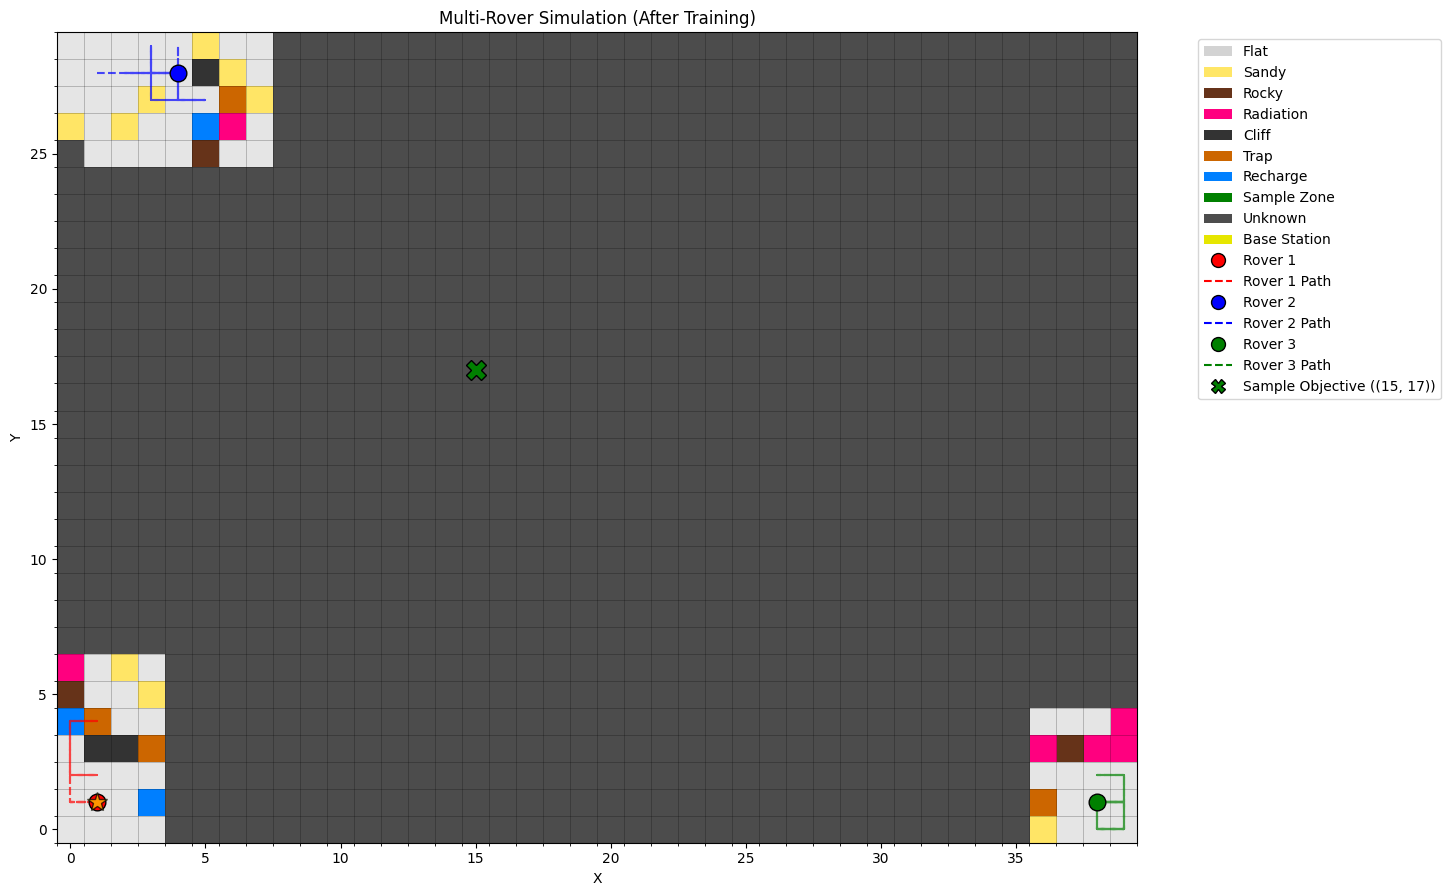


--- Q-Table Info for Current State ---
Current State: (0, 0, 0, 0, 4, 4, 5, 1)
  Action move_N: -0.01
  Action move_E: -10.01
  Action move_S: 0.00
  Action move_W: 0.00
  Action use_radiation_shield: -305.10
  Action use_repair_kit: -310.10
  Action seek_recharge: -290.10
  Action collect_sample: -300.10
  Action objective_completed: -300.10
  Action mission_completed: -300.10
  Action backtrack_radiation: -265.32
  Action backtrack_trap: -286.05
  Action explore_unknown: -300.10
  Action move_towards_recharge: -300.10
  Optimal Action: move_S


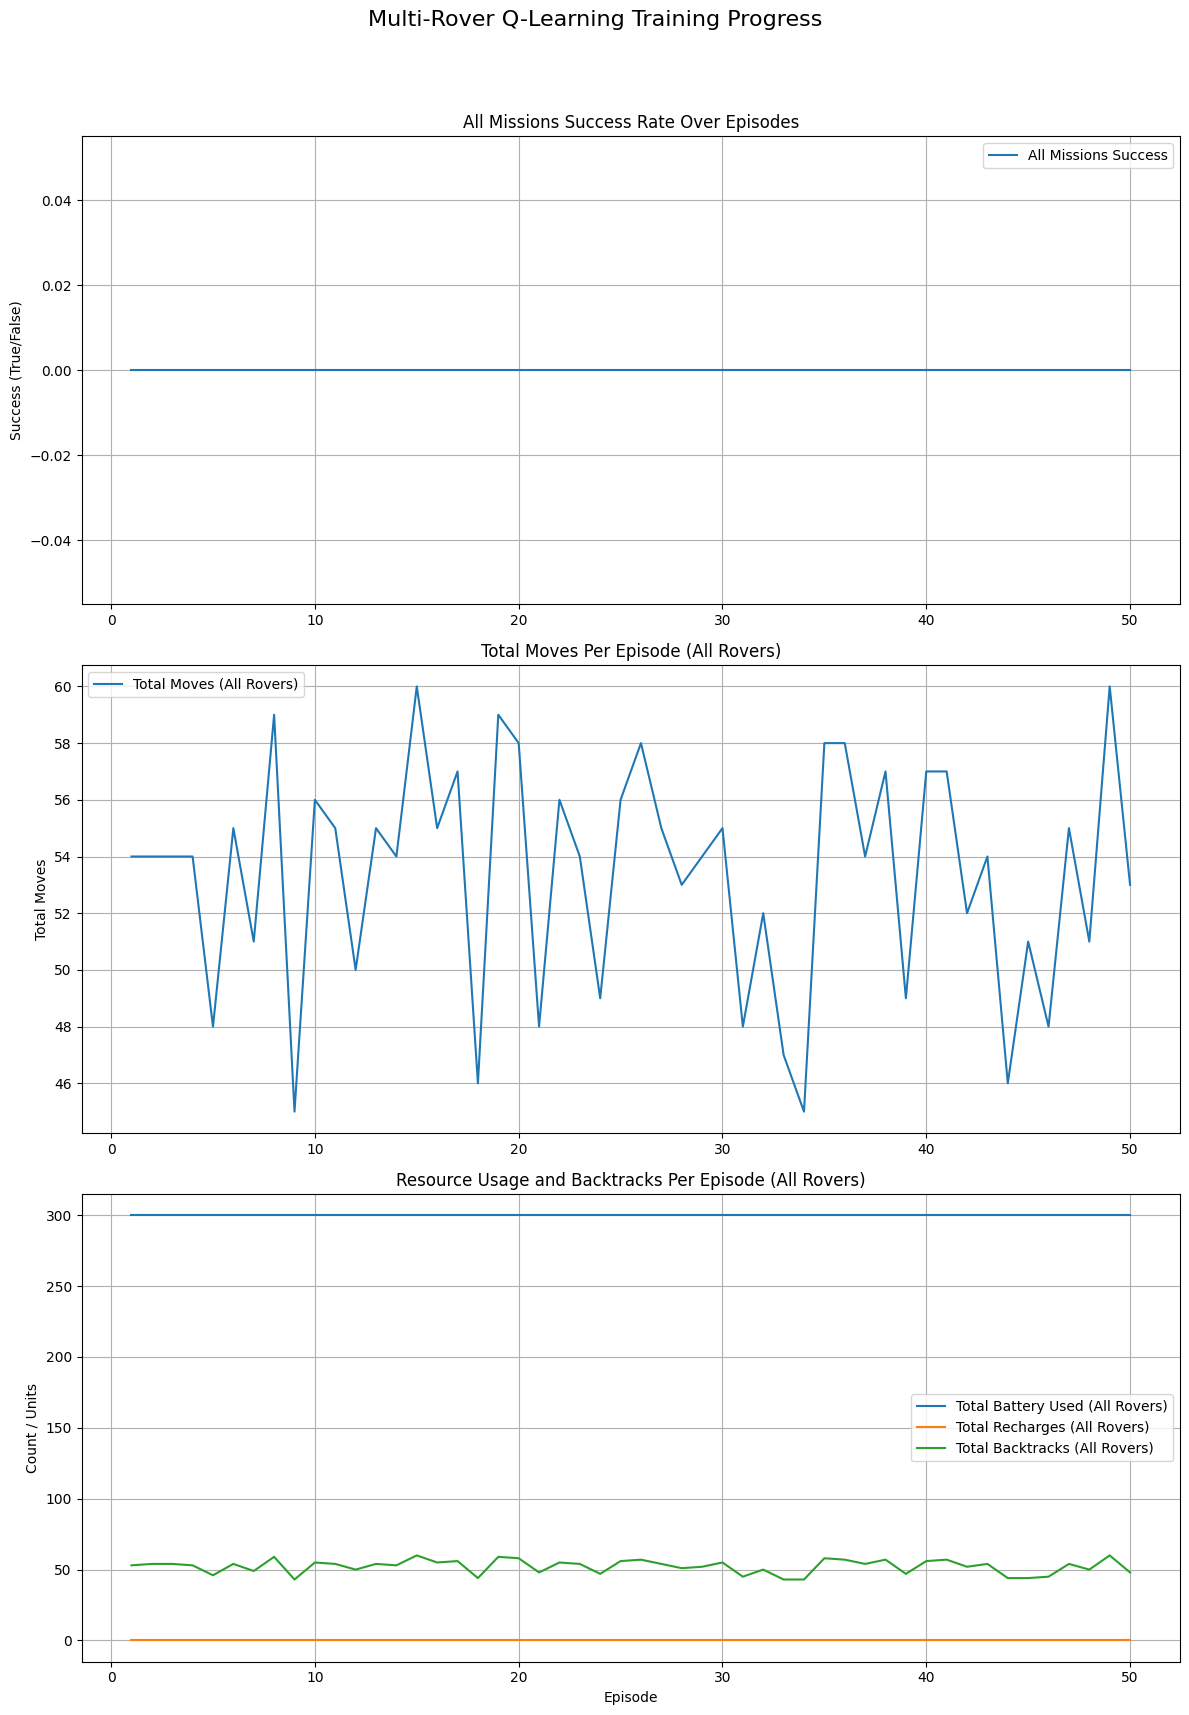

In [14]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from enum import Enum
import random
from typing import List, Tuple, Dict, Optional, Set, Any
import math
import collections

class TerrainType(Enum):
    FLAT = 0
    SANDY = 1
    ROCKY = 2
    RADIATION = 3
    RECHARGE_STATION = 4
    SAMPLE_ZONE = 5
    CLIFF = 6  # Impassable terrain
    TRAP = 7   # Dangerous terrain requiring backtracking
    UNKNOWN = 8 # Unobserved terrain
    BASE_STATION = 9 # Rover's home base

class RoverState:
    def __init__(self, position: Tuple[int, int], battery: float = 100.0):
        self.position = position
        self.battery = battery
        self.path_history = [position]
        self.safe_positions = [position]
        self.visited_traps = set()  # Track encountered traps
        self.samples_collected = 0
        self.repair_kits: int = 2
        self.radiation_shields: int = 1
        self.mission_objectives: List[Tuple[TerrainType, Tuple[int, int]]] = []
        self.current_objective_index: int = 0
        self.visit_points_visited: Set[Tuple[int, int]] = set()

class Grid:
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.actual_terrain = np.zeros((height, width), dtype=int)
        self.known_terrain = np.full((height, width), TerrainType.UNKNOWN.value, dtype=int)

        self.recharge_stations = []
        self.sample_zones = []
        self.base_stations = []

        self.movement_costs = {
            TerrainType.FLAT: 5,
            TerrainType.SANDY: 10,
            TerrainType.RADIATION: 15,
            TerrainType.ROCKY: 1000,
            TerrainType.RECHARGE_STATION: 5,
            TerrainType.SAMPLE_ZONE: 5,
            TerrainType.CLIFF: 1000,
            TerrainType.TRAP: 20,
            TerrainType.UNKNOWN: 50,
            TerrainType.BASE_STATION: 5
        }

    def set_terrain(self, x: int, y: int, terrain_type: TerrainType):
        if 0 <= x < self.width and 0 <= y < self.height:
            self.actual_terrain[y, x] = terrain_type.value
            if terrain_type == TerrainType.RECHARGE_STATION:
                if (x,y) not in self.recharge_stations:
                    self.recharge_stations.append((x, y))
            elif terrain_type == TerrainType.SAMPLE_ZONE:
                if (x,y) not in self.sample_zones:
                    self.sample_zones.append((x, y))
            elif terrain_type == TerrainType.BASE_STATION:
                if (x,y) not in self.base_stations:
                    self.base_stations.append((x, y))

    def get_actual_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.actual_terrain[y, x])
        return TerrainType.CLIFF

    def get_known_terrain(self, x: int, y: int) -> TerrainType:
        if 0 <= x < self.width and 0 <= y < self.height:
            return TerrainType(self.known_terrain[y, x])
        return TerrainType.CLIFF

    def is_valid_position(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_actual_terrain(x, y)
        return terrain not in [TerrainType.ROCKY, TerrainType.CLIFF]

    def is_valid_for_planning(self, x: int, y: int) -> bool:
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        terrain = self.get_known_terrain(x, y)
        return terrain not in [TerrainType.UNKNOWN, TerrainType.ROCKY, TerrainType.CLIFF]

    def get_movement_cost(self, x: int, y: int) -> float:
        terrain = self.get_known_terrain(x, y)
        return self.movement_costs[terrain]

    def reveal_area(self, center_x: int, center_y: int, radius: int):
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                nx, ny = center_x + dx, center_y + dy
                if 0 <= nx < self.width and 0 <= ny < self.height:
                    self.known_terrain[ny, nx] = self.actual_terrain[ny, nx]

    def generate_random_terrain(self):
        for y in range(self.height):
            for x in range(self.width):
                rand = random.random()
                if rand < 0.08:
                    self.actual_terrain[y, x] = TerrainType.ROCKY.value
                elif rand < 0.12:
                    self.actual_terrain[y, x] = TerrainType.CLIFF.value
                elif rand < 0.17:
                    self.actual_terrain[y, x] = TerrainType.TRAP.value
                elif rand < 0.22:
                    self.actual_terrain[y, x] = TerrainType.RADIATION.value
                elif rand < 0.42:
                    self.actual_terrain[y, x] = TerrainType.SANDY.value
                else:
                    self.actual_terrain[y, x] = TerrainType.FLAT.value

        num_stations = max(3, (self.width * self.height) // 80)
        for _ in range(num_stations):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.RECHARGE_STATION)
                    break

        num_samples = max(2, (self.width * self.height) // 120)
        for _ in range(num_samples):
            for attempt in range(50):
                x, y = random.randint(0, self.width-1), random.randint(0, self.height-1)
                if self.get_actual_terrain(x, y) == TerrainType.FLAT:
                    self.set_terrain(x, y, TerrainType.SAMPLE_ZONE)
                    break

class AStarHeuristics:
    @staticmethod
    def manhattan_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    @staticmethod
    def euclidean_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    @staticmethod
    def chebyshev_distance(pos1: Tuple[int, int], pos2: Tuple[int, int]) -> float:
        return max(abs(pos1[0] - pos2[0]), abs(pos1[1] - pos2[1]))

    @staticmethod
    def weighted_euclidean(pos1: Tuple[int, int], pos2: Tuple[int, int], weight: float = 1.1) -> float:
        return weight * math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

class AStar:
    def __init__(self, grid: Grid, heuristic_func):
        self.grid = grid
        self.heuristic = heuristic_func
        self.nodes_expanded = 0

    def get_neighbors(self, pos: Tuple[int, int]) -> List[Tuple[int, int]]:
        x, y = pos
        neighbors = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]: # 4-directional movement
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_for_planning(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors

    def search(self, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        if start == goal:
            return [start]

        self.nodes_expanded = 0
        open_set = [(0, start)]  # f_score, current_node
        came_from = {}  # current_node -> previous_node
        g_score = {start: 0}  # cost from start to current_node
        f_score = {start: self.heuristic(start, goal)}  # estimated cost from start to goal
        closed_set = set()

        if not self.grid.is_valid_for_planning(start[0], start[1]):
             return None

        while open_set:
            current_f, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.nodes_expanded += 1

            if current == goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(start)
                return path[::-1]

            for neighbor in self.get_neighbors(current):
                if neighbor in closed_set:
                    continue

                tentative_g = g_score[current] + self.grid.get_movement_cost(*neighbor)

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))

        return None

class QLearningAgent:
    def __init__(self, grid: Grid, actions: List[str], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        self.grid = grid
        self.actions = actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration-exploitation trade-off
        self.q_table = collections.defaultdict(lambda: np.zeros(len(self.actions)))

        # Action mapping for easier use
        self.action_to_index = {action: i for i, action in enumerate(actions)}
        self.index_to_action = {i: action for i, action in enumerate(actions)}

    def _discretize_battery(self, battery: float) -> int:
        if battery < 15: return 0  # Critical
        if battery < 25: return 1  # Low
        if battery < 50: return 2  # Medium
        return 3  # High

    def _discretize_distance(self, dist: float) -> int:
        if dist == float('inf'): return 4 # No known path
        if dist == 0: return 0 # At location
        if dist < 5: return 1 # Near
        if dist < 15: return 2 # Medium
        return 3 # Far

    def _get_state(self, rover_state: RoverState, current_objective_type: TerrainType,
                   current_objective_pos: Tuple[int, int], heuristic_func) -> Tuple[Any, ...]:
        # Rover's current position terrain
        current_terrain = self.grid.get_actual_terrain(*rover_state.position).value

        # Battery level
        battery_bin = self._discretize_battery(rover_state.battery)

        # Repair kits and radiation shields
        repair_kits_count = min(rover_state.repair_kits, 2) # Cap at 2 to keep state space small
        radiation_shields_count = min(rover_state.radiation_shields, 1) # Cap at 1

        # Distance to current objective (Manhattan distance for simplicity, use A* path cost for accuracy if feasible)
        dist_to_obj = float('inf')
        if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*current_objective_pos):
            path_to_obj = AStar(self.grid, heuristic_func).search(rover_state.position, current_objective_pos)
            if path_to_obj: dist_to_obj = len(path_to_obj) - 1
        obj_dist_bin = self._discretize_distance(dist_to_obj)

        # Distance to nearest recharge station
        dist_to_recharge = float('inf')
        if self.grid.recharge_stations:
            min_recharge_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.is_valid_for_planning(*rover_state.position) and self.grid.is_valid_for_planning(*station):
                    path_to_station = AStar(self.grid, heuristic_func).search(rover_state.position, station)
                    if path_to_station: min_recharge_dist = min(min_recharge_dist, len(path_to_station) - 1)
            dist_to_recharge = min_recharge_dist
        recharge_dist_bin = self._discretize_distance(dist_to_recharge)

        # Current objective type (numerical representation)
        obj_type_value = current_objective_type.value

        # Has rover encountered a trap recently at current position?
        is_at_known_trap = 1 if rover_state.position in rover_state.visited_traps else 0

        # Combine into a state tuple
        state_tuple = (
            current_terrain,
            battery_bin,
            repair_kits_count,
            radiation_shields_count,
            obj_dist_bin,
            recharge_dist_bin,
            obj_type_value,
            is_at_known_trap
        )
        return state_tuple

    def choose_action(self, state_tuple: Tuple[Any, ...]) -> str:
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)  # Explore
        else:
            q_values = self.q_table[state_tuple]
            # Handle cases where all Q-values are equal (e.g., all zeros initially)
            if np.all(q_values == q_values[0]):
                return random.choice(self.actions)
            action_index = np.argmax(q_values) # Exploit
            return self.index_to_action[action_index]

    def learn(self, state: Tuple[Any, ...], action: str, reward: float,
              next_state: Tuple[Any, ...], done: bool):
        # Ensure the action is known to the agent before trying to access its index
        if action not in self.action_to_index:
            # This case should ideally not happen if q_actions are comprehensive
            # For robustness, we can handle it by ignoring this learning step or logging an error
            print(f"Warning: Unknown action '{action}' passed to QLearningAgent.learn. Ignoring.")
            return

        action_index = self.action_to_index[action]
        current_q = self.q_table[state][action_index]

        if done:
            new_q = reward
        else:
            max_next_q = np.max(self.q_table[next_state])
            new_q = reward + self.gamma * max_next_q

        self.q_table[state][action_index] += self.alpha * (new_q - current_q)

class PlanetaryRover:
    def __init__(self, grid: Grid, start_position: Tuple[int, int], heuristic_func_for_state: Any = AStarHeuristics.manhattan_distance):
        self.grid = grid
        self.state = RoverState(start_position)

        self.q_actions = [
            'move_N', 'move_E', 'move_S', 'move_W',
            'use_radiation_shield', 'use_repair_kit', 'seek_recharge',
            'collect_sample', 'objective_completed', 'mission_completed',
            'backtrack_radiation', 'backtrack_trap',
            'explore_unknown',
            'move_towards_recharge' # Added to the list of Q-actions
        ]
        self.q_agent = QLearningAgent(grid, self.q_actions)
        self.heuristic_func_for_state = heuristic_func_for_state

        self.current_path = []
        self.path_index = 0
        self.vision_radius: int = 2

        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }

    def reset(self, new_grid: Grid, start_position: Tuple[int, int]):
        # Ensure the rover references the shared grid
        self.grid = new_grid
        self.state = RoverState(start_position)
        self.current_path = []
        self.path_index = 0
        self.stats = {
            'total_moves': 0,
            'battery_used': 0,
            'recharges': 0,
            'backtracks': 0,
            'radiation_encounters': 0,
            'trap_encounters': 0,
            'nodes_expanded': 0,
            'repair_kits_used': 0,
            'radiation_shields_used': 0,
            'samples_collected': 0,
            'objectives_completed': 0
        }
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

    def set_mission_objectives(self, objectives: List[Tuple[TerrainType, Tuple[int, int]]]):
        self.state.mission_objectives = objectives.copy()
        if not any(obj_type == TerrainType.BASE_STATION for obj_type, _ in objectives):
             self.state.mission_objectives.append((TerrainType.BASE_STATION, self.state.path_history[0]))

        self.state.current_objective_index = 0
        self.current_path = []
        self.path_index = 0

    def plan_path(self, heuristic_func, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
        astar = AStar(self.grid, heuristic_func)
        path = astar.search(start, goal)
        self.stats['nodes_expanded'] += astar.nodes_expanded
        return path

    def move_to_position(self, target: Tuple[int, int]) -> bool:
        if not self.grid.is_valid_position(*target): # Check actual validity
            return False

        # Use actual terrain cost for the move being executed
        cost = self.grid.movement_costs[self.grid.get_actual_terrain(*target)]
        if self.state.battery < cost:
            return False

        self.state.position = target
        self.state.battery -= cost
        self.state.path_history.append(target)

        terrain = self.grid.get_actual_terrain(*target)
        if terrain not in [TerrainType.RADIATION, TerrainType.TRAP]:
            # Only add to safe positions if not a hazardous terrain. If it was hazard and dealt with, it's now safe.
            self.state.safe_positions.append(target)

        self.stats['total_moves'] += 1
        self.stats['battery_used'] += cost

        return True

    def backtrack(self, reason: str = "hazard") -> bool:
        if len(self.state.safe_positions) > 1: # Ensure there's a safe position to go back to
            # Pop the current, potentially hazardous position if it was added
            if self.state.safe_positions and self.state.safe_positions[-1] == self.state.position:
                self.state.safe_positions.pop()

            if not self.state.safe_positions: # If no safe positions left (e.g. only start was safe, and it was popped)
                return False # Cannot backtrack effectively

            safe_pos = self.state.safe_positions[-1]
            self.state.position = safe_pos
            self.state.path_history.append(safe_pos)
            self.stats['backtracks'] += 1

            if reason == "radiation":
                self.stats['radiation_encounters'] += 1
            elif reason == "trap":
                self.stats['trap_encounters'] += 1
                self.state.visited_traps.add(self.state.position) # Mark current pos as visited trap
            return True
        return False # Failed to backtrack

    def recharge(self) -> bool:
        terrain = self.grid.get_actual_terrain(*self.state.position)
        if terrain == TerrainType.RECHARGE_STATION:
            self.state.battery = 100.0
            self.stats['recharges'] += 1
            return True
        return False

    def collect_sample(self) -> bool:
        if self.grid.get_actual_terrain(*self.state.position) == TerrainType.SAMPLE_ZONE:
            self.stats['samples_collected'] += 1
            return True
        return False

    def use_radiation_shield(self) -> bool:
        if self.state.radiation_shields > 0:
            self.state.radiation_shields -= 1
            self.stats['radiation_shields_used'] += 1
            return True
        return False

    def use_repair_kit(self) -> bool:
        if self.state.repair_kits > 0:
            self.state.repair_kits -= 1
            self.stats['repair_kits_used'] += 1
            # Neutralize the trap by updating the known terrain and removing it from visited_traps
            self.grid.known_terrain[self.state.position[1], self.state.position[0]] = TerrainType.FLAT.value
            if self.state.position in self.state.visited_traps:
                self.state.visited_traps.remove(self.state.position)
            return True
        return False

    def get_reward(self, prev_state_obj_idx: int, current_action: str, current_terrain_actual: TerrainType,
                   mission_success_flag: bool, simulation_stuck: bool) -> float:
        reward = -0.1 # Small penalty for each step/move to encourage efficiency

        # Reward for completing an objective
        if self.state.current_objective_index > prev_state_obj_idx:
            if current_action == 'collect_sample':
                reward += 100 # High reward for samples
            elif current_action == 'objective_completed':
                reward += 50 # Medium reward for generic objectives
            elif current_action == 'mission_completed':
                reward += 1000 # Very high reward for completing the entire mission

        # Rewards/Penalties related to hazards and resources
        if current_action == 'use_radiation_shield':
            reward -= 5 # Cost for using a shield, but avoids larger penalty
        elif current_action == 'use_repair_kit':
            reward -= 10 # Cost for using a kit, higher as it modifies terrain
        elif current_action == 'backtrack_radiation' or current_action == 'backtrack_trap':
            reward -= 50 # High penalty for forced backtrack

        # Penalties for negative state conditions
        if self.state.battery <= 0: # Ran out of battery
            reward -= 100

        if simulation_stuck:
            reward -= 200 # Major penalty for getting stuck

        # Penalty if rover is on a hazardous terrain and doesn't use mitigation (or can't)
        if current_terrain_actual == TerrainType.TRAP and self.state.position not in self.state.visited_traps and current_action not in ['use_repair_kit', 'backtrack_trap']:
            reward -= 30 # Penalty for entering new trap without using kit
        if current_terrain_actual == TerrainType.RADIATION and current_action not in ['use_radiation_shield', 'backtrack_radiation']:
            reward -= 20 # Penalty for entering radiation without shield

        if current_action == 'seek_recharge' and self.state.battery < 25:
             reward += 10 # Small reward for trying to recharge when low
        if current_action == 'recharge':
            reward += 20 # Reward for actually recharging

        return reward


    def simulate_step(self, heuristic_func: Any) -> Tuple[bool, str, float]: # Returns (success of step, action_taken, reward)
        current_pos = self.state.position
        current_terrain_actual = self.grid.get_actual_terrain(*current_pos)

        # Check for mission completion before starting the step
        if self.state.current_objective_index >= len(self.state.mission_objectives):
            return False, "mission_completed", 0 # Signal completion

        current_objective_type, current_objective_pos = self.state.mission_objectives[self.state.current_objective_index]

        self.grid.reveal_area(current_pos[0], current_pos[1], self.vision_radius)

        # Get initial state for Q-learning for this step
        state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)
        action_chosen = self.q_agent.choose_action(state_tuple)

        # Keep track of previous objective index for reward calculation
        prev_objective_index = self.state.current_objective_index

        step_successful = False
        action_executed = action_chosen # Default, will be updated if a primitive move is executed
        original_pos = self.state.position
        original_battery = self.state.battery

        if action_chosen == 'backtrack_radiation':
            step_successful = self.backtrack("radiation")
            self.current_path = []  # Invalidate current path, replan needed

        elif action_chosen == 'backtrack_trap':
            step_successful = self.backtrack("trap")
            self.current_path = [] # Invalidate current path, replan needed

        elif action_chosen == 'use_radiation_shield':
            step_successful = self.use_radiation_shield()

        elif action_chosen == 'use_repair_kit':
            step_successful = self.use_repair_kit()

        elif action_chosen == 'recharge':
            step_successful = self.recharge()

        elif action_chosen == 'collect_sample': # Only relevant if current_pos is sample obj
            step_successful = self.collect_sample()
            if step_successful and self.state.position == current_objective_pos:
                 self.stats['objectives_completed'] += 1
                 self.state.current_objective_index += 1
                 self.current_path = [] # Force replan

        elif action_chosen == 'objective_completed': # For non-sample objectives
            if self.state.position == current_objective_pos:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1
                self.state.visit_points_visited.add(current_objective_pos)
                self.current_path = [] # Force replan
                step_successful = True
            else: # Agent tried to complete objective but wasn't there yet
                step_successful = False

        elif action_chosen == 'mission_completed': # For base station objective
            if self.state.position == current_objective_pos and current_objective_type == TerrainType.BASE_STATION:
                self.stats['objectives_completed'] += 1
                self.state.current_objective_index += 1 # This will make the mission complete in run_simulation
                step_successful = True
            else: # Agent tried to complete mission but wasn't at base or mission not over
                step_successful = False

        elif action_chosen == 'seek_recharge':
            nearest_station = None
            # find nearest station among known ones, prioritizing reachable
            current_min_dist = float('inf')
            for station in self.grid.recharge_stations:
                if self.grid.get_known_terrain(*station) != TerrainType.UNKNOWN: # Only consider known stations
                    if self.grid.is_valid_for_planning(*self.state.position) and self.grid.is_valid_for_planning(*station):
                        path = self.plan_path(heuristic_func, self.state.position, station)
                        if path and len(path) - 1 < current_min_dist:
                            current_min_dist = len(path) - 1
                            nearest_station = station

            if nearest_station:
                path = self.plan_path(heuristic_func, self.state.position, nearest_station)
                if path and len(path) > 1: # If path found, move one step
                    step_successful = self.move_to_position(path[1])
                    action_executed = 'move_towards_recharge' # Specific action name for reward
                else: # Could not move to station (e.g. blocked, or already there, handled by recharge action)
                    step_successful = False
            else:
                step_successful = False # No known recharge station to seek

        elif action_chosen.startswith('move_'): # Primitive movement actions
            dx, dy = 0, 0
            if action_chosen == 'move_N': dy = 1
            elif action_chosen == 'move_E': dx = 1
            elif action_chosen == 'move_S': dy = -1
            elif action_chosen == 'move_W': dx = -1

            target_pos = (current_pos[0] + dx, current_pos[1] + dy)
            # Before moving, check if target is currently known as an impassable actual terrain
            if self.grid.get_known_terrain(*target_pos) in [TerrainType.ROCKY, TerrainType.CLIFF]:
                step_successful = False # Cannot move into known impassable
            elif self.grid.get_known_terrain(*target_pos) == TerrainType.TRAP and target_pos in self.state.visited_traps:
                step_successful = False # Cannot move into a known trap that hasn't been repaired
            else:
                step_successful = self.move_to_position(target_pos)
                action_executed = action_chosen # Action executed is the chosen move action

        elif action_chosen == 'explore_unknown': # Explicit exploration action
            step_successful = self._explore_unknown_area(current_terrain_actual)
            action_executed = 'explore_unknown'

        # If a high-level action failed to execute into a primitive move or wasn't explicitly handled yet
        if not step_successful and action_executed not in self.q_actions[4:] and action_executed not in ['mission_completed', 'objective_completed', 'collect_sample'] and action_executed != 'explore_unknown':
            # If agent chose a move action or 'explore' but couldn't move, try generic exploration
            step_successful = self._explore_unknown_area(current_terrain_actual)
            action_executed = 'explore_unknown'

        # Check if rover got stuck (didn't move or change battery/objectives despite trying a primitive action)
        simulation_stuck = (self.state.position == original_pos and self.state.battery == original_battery and not step_successful and self.state.current_objective_index == prev_objective_index)

        # Get next state after action (even if action failed or stuck)
        next_state_tuple = self.q_agent._get_state(self.state, current_objective_type, current_objective_pos, heuristic_func)

        # Determine reward
        reward = self.get_reward(prev_objective_index, action_executed, current_terrain_actual,
                                 mission_success_flag=False, simulation_stuck=simulation_stuck)

        # Q-learning update
        self.q_agent.learn(state_tuple, action_executed, reward, next_state_tuple, done=not step_successful or simulation_stuck)

        return step_successful, action_executed, reward

    def _explore_unknown_area(self, current_terrain_actual: TerrainType) -> bool:
        x, y = self.state.position
        possible_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if 0 <= new_x < self.grid.width and 0 <= new_y < self.grid.height:
                # Prioritize moving to an UNKNOWN cell that is actually valid
                if self.grid.get_known_terrain(new_x, new_y) == TerrainType.UNKNOWN and \
                   self.grid.is_valid_position(new_x, new_y):
                    possible_moves.append((new_x, new_y))

        if possible_moves:
            target = random.choice(possible_moves)
            return self.move_to_position(target)

        # Fallback to moving to a random *known* valid adjacent cell if no unknown cells directly visible
        fallback_moves = []
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.grid.is_valid_position(new_x, new_y): # Check actual validity
                actual_terrain_neighbor = self.grid.get_actual_terrain(new_x, new_y)
                # Avoid moving into known traps (unless current pos is trap being repaired) or unshielded radiation during fallback exploration
                if (new_x, new_y) in self.state.visited_traps: continue
                if actual_terrain_neighbor == TerrainType.RADIATION and self.state.radiation_shields == 0: continue
                if actual_terrain_neighbor == TerrainType.CLIFF or actual_terrain_neighbor == TerrainType.ROCKY: continue
                fallback_moves.append((new_x, new_y))

        if fallback_moves:
            target = random.choice(fallback_moves)
            return self.move_to_position(target)

        return False # No valid moves left for exploration

    def run_simulation(self, heuristic_func, max_steps: int = 1000) -> bool:
        steps = 0
        episode_reward = 0

        # Initial reveal at starting position
        self.grid.reveal_area(self.state.position[0], self.state.position[1], self.vision_radius)

        while steps < max_steps and self.state.current_objective_index < len(self.state.mission_objectives):
            step_successful, action_taken, reward = self.simulate_step(heuristic_func)
            episode_reward += reward

            if not step_successful and self.state.current_objective_index < len(self.state.mission_objectives): # If not successful and mission not yet complete
                # print(f"❌ Simulation halted: Rover stuck or no valid moves at step {steps}. Action: {action_taken}")
                break

            steps += 1

        mission_success = self.state.current_objective_index >= len(self.state.mission_objectives)

        # Final reward and learning update for the terminal state
        # This needs to be done carefully as simulate_step already does a learn call.
        # The final reward should reflect the outcome of the entire episode.
        # For simplicity, we can log episode_reward and rely on the step-wise learning.

        if mission_success:
            # print(f"✅ Mission completed in {steps} steps! Total Reward: {episode_reward:.2f}")
            pass
        else:
            # print(f"❌ Simulation ended after {steps} steps. Mission not completed. Total Reward: {episode_reward:.2f}")
            pass
        return mission_success

def create_sample_grid(width=25, height=20, num_rovers=1) -> Grid:
    grid = Grid(width, height)
    grid.generate_random_terrain()

    # Ensure start and base station are accessible and visible initially
    # For multi-rover, we define a common base station for all to return to
    base_pos = (width - 2, height - 2)
    grid.set_terrain(base_pos[0], base_pos[1], TerrainType.BASE_STATION)

    # Ensure surrounding area of base are flat
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            if 0 <= base_pos[0] + dx < grid.width and 0 <= base_pos[1] + dy < grid.height:
                grid.set_terrain(base_pos[0] + dx, base_pos[1] + dy, TerrainType.FLAT)

    # We'll set rover start positions and their immediate surroundings separately in the manager
    return grid

def visualize_grid(grid: Grid,
                  rover_data: List[Dict[str, Any]] = None, # List of {'pos': (x,y), 'path': [...], 'color': 'red'}
                  title: str = "Planetary Rover Grid",
                  mission_objectives: Optional[List[Tuple[TerrainType, Tuple[int, int]]]] = None,
                  current_objective_idx: int = 0,
                  visit_points_visited: Optional[Set[Tuple[int, int]]] = None,
                  show_q_table_info: bool = False,
                  q_agent: Optional[QLearningAgent] = None,
                  heuristic_func: Optional[Any] = None,
                  rover_state: Optional[RoverState] = None):
    """Visualize the grid with rover position, path, fog of war, and mission objectives"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    color_map = {
        TerrainType.FLAT.value: [0.9, 0.9, 0.9],
        TerrainType.SANDY.value: [1.0, 0.9, 0.4],
        TerrainType.ROCKY.value: [0.4, 0.2, 0.1],
        TerrainType.RADIATION.value: [1.0, 0.0, 0.5],
        TerrainType.RECHARGE_STATION.value: [0.0, 0.5, 1.0],
        TerrainType.SAMPLE_ZONE.value: [0.0, 0.8, 0.0],
        TerrainType.CLIFF.value: [0.2, 0.2, 0.2],
        TerrainType.TRAP.value: [0.8, 0.4, 0.0],
        TerrainType.UNKNOWN.value: [0.3, 0.3, 0.3],
        TerrainType.BASE_STATION.value: [0.9, 0.9, 0.0]
    }

    color_array = np.zeros((grid.height, grid.width, 3))
    for y in range(grid.height):
        for x in range(grid.width):
            terrain_type_value = grid.known_terrain[y, x]
            color_array[y, x] = color_map.get(terrain_type_value, [0.5, 0.5, 0.5])

    ax.imshow(color_array, origin='lower')

    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='lightgray', label='Flat'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.9, 0.4], label='Sandy'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.4, 0.2, 0.1], label='Rocky'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[1.0, 0.0, 0.5], label='Radiation'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.2, 0.2, 0.2], label='Cliff'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.8, 0.4, 0.0], label='Trap'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.0, 0.5, 1.0], label='Recharge'),
        patches.Rectangle((0, 0), 1, 1, facecolor='green', label='Sample Zone'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.3, 0.3, 0.3], label='Unknown'),
        patches.Rectangle((0, 0), 1, 1, facecolor=[0.9, 0.9, 0.0], label='Base Station')
    ]

    # Draw multiple rovers and their paths
    if rover_data:
        for i, r_data in enumerate(rover_data):
            rover_pos = r_data['pos']
            path = r_data['path']
            color = r_data.get('color', 'black')
            label = r_data.get('label', f'Rover {i+1}')

            if path:
                known_path_x, known_path_y = [], []
                for p_x, p_y in path:
                    if grid.get_known_terrain(p_x, p_y) != TerrainType.UNKNOWN or (p_x,p_y) == rover_pos:
                        known_path_x.append(p_x)
                        known_path_y.append(p_y)
                    else:
                        break
                ax.plot(known_path_x, known_path_y, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=f'{label} Path')

            if rover_pos:
                ax.plot(rover_pos[0], rover_pos[1], marker='o', color='w', markerfacecolor=color, markersize=12, markeredgecolor='black', label=label)

            # Add rover legend element
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='black', label=label))
            legend_elements.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=1.5, label=f'{label} Path'))

    # Draw mission objectives (only for the *first* rover's mission or a unified mission if applicable)
    # This part assumes a single mission is visualized or missions are similar enough
    if mission_objectives:
        for i, (obj_type, obj_pos) in enumerate(mission_objectives):
            marker = 's'
            color = 'cyan'
            label_prefix = "Visit"

            if obj_type == TerrainType.SAMPLE_ZONE:
                marker = 'X'
                color = 'green'
                label_prefix = "Sample"
            elif obj_type == TerrainType.BASE_STATION:
                marker = '*'
                color = 'gold'
                label_prefix = "Base"
            elif obj_type == TerrainType.RECHARGE_STATION:
                marker = 'o'
                color = 'blue'
                label_prefix = "Recharge"

            if i < current_objective_idx: # Completed objectives
                alpha = 0.3
                facecolor = 'gray'
                edgecolor = 'darkgray'
                zorder = 1
            elif i == current_objective_idx: # Current objective
                alpha = 1.0
                facecolor = color
                edgecolor = 'black'
                zorder = 3
            else: # Pending objectives
                alpha = 0.7
                facecolor = color
                edgecolor = 'black'
                zorder = 2

            # Only draw if objective position is known or it's the current one
            if grid.get_known_terrain(*obj_pos) != TerrainType.UNKNOWN or i == current_objective_idx:
                ax.plot(obj_pos[0], obj_pos[1], marker=marker, markersize=15,
                        markerfacecolor=facecolor, markeredgecolor=edgecolor,
                        alpha=alpha, zorder=zorder,
                        label=f'{label_prefix} Objective {i+1} at {obj_pos}')

            # Add objective legend element (only once for each objective type, or current one)
            if i == current_objective_idx: # Only show label for current objective in legend
                legend_elements.append(plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=facecolor, markersize=10, markeredgecolor=edgecolor, label=f'{label_prefix} Objective ({obj_pos})'))

    ax.set_xticks(np.arange(-0.5, grid.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.3)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    if show_q_table_info and q_agent and rover_state and heuristic_func:
        print("\n--- Q-Table Info for Current State ---")
        if rover_state.current_objective_index < len(rover_state.mission_objectives):
            current_obj_type, current_obj_pos = rover_state.mission_objectives[rover_state.current_objective_index]
        else: # If mission complete, use dummy objective data for state representation
            current_obj_type = TerrainType.BASE_STATION
            current_obj_pos = rover_state.position # Or some other default

        current_q_state = q_agent._get_state(rover_state, current_obj_type, current_obj_pos, heuristic_func)
        q_values_at_state = q_agent.q_table[current_q_state]
        if np.any(q_values_at_state != 0):
            print(f"Current State: {current_q_state}")
            for i, q_val in enumerate(q_values_at_state):
                print(f"  Action {q_agent.index_to_action[i]}: {q_val:.2f}")
            print(f"  Optimal Action: {q_agent.index_to_action[np.argmax(q_values_at_state)]}")
        else:
            print(f"Current State: {current_q_state} (No Q-values learned yet for this state)")



# Existing single rover Q-learning simulation, now a function
def single_rover_q_learning_simulation():
    print("=== Q-Learning Planetary Rover Simulation (Single Rover) ===\n")

    num_training_episodes = 200
    max_steps_per_episode = 1000
    epsilon_decay_rate = 0.995
    min_epsilon = 0.01

    grid_width, grid_height = 30, 25
    start_pos_initial = (1, 1)
    base_pos_initial = (grid_width - 2, grid_height - 2)

    rover = PlanetaryRover(Grid(grid_width, grid_height), start_pos_initial, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
    initial_epsilon = rover.q_agent.epsilon

    overall_results = {
        'episode': [],
        'epsilon': [],
        'mission_success': [],
        'total_moves': [],
        'battery_used': [],
        'recharges': [],
        'backtracks': [],
        'samples_collected': [],
        'objectives_completed': [],
        'nodes_expanded': []
    }

    for episode in range(num_training_episodes):
        current_grid = create_sample_grid(grid_width, grid_height)
        current_grid.set_terrain(base_pos_initial[0], base_pos_initial[1], TerrainType.BASE_STATION)

        rover.reset(current_grid, start_pos_initial)

        mission_objectives_list_episode = [
            (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[0] if current_grid.sample_zones else (5,5)),
            (TerrainType.FLAT, (random.randint(5, grid_width-5), random.randint(5, grid_height-5))),
            (TerrainType.SAMPLE_ZONE, current_grid.sample_zones[1] if len(current_grid.sample_zones) > 1 else (20,8)),
            (TerrainType.RECHARGE_STATION, current_grid.recharge_stations[0] if current_grid.recharge_stations else (1,1))
        ]
        rover.set_mission_objectives(mission_objectives_list_episode)

        mission_success = rover.run_simulation(AStarHeuristics.weighted_euclidean, max_steps=max_steps_per_episode)

        overall_results['episode'].append(episode + 1)
        overall_results['epsilon'].append(rover.q_agent.epsilon)
        overall_results['mission_success'].append(mission_success)
        overall_results['total_moves'].append(rover.stats['total_moves'])
        overall_results['battery_used'].append(rover.stats['battery_used'])
        overall_results['recharges'].append(rover.stats['recharges'])
        overall_results['backtracks'].append(rover.stats['backtracks'])
        overall_results['samples_collected'].append(rover.stats['samples_collected'])
        overall_results['objectives_completed'].append(rover.stats['objectives_completed'])
        overall_results['nodes_expanded'].append(rover.stats['nodes_expanded'])

        rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

        if (episode + 1) % 20 == 0:
            print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {rover.q_agent.epsilon:.3f}, Success: {mission_success}, Moves: {rover.stats['total_moves']}")

    print(f"\n--- Training Completed ---")
    print(f"Final Epsilon: {rover.q_agent.epsilon:.3f}")

    print(f"\n{'='*50}")
    print(f"Final Simulation Statistics (Last Episode):")
    print(f"{'='*50}")
    print(f"Mission Success: {overall_results['mission_success'][-1]}")
    print(f"Total objectives completed: {overall_results['objectives_completed'][-1]}")
    print(f"Total moves: {overall_results['total_moves'][-1]}")
    print(f"Battery used: {overall_results['battery_used'][-1]:.2f}")
    print(f"Recharges: {overall_results['recharges'][-1]}")
    print(f"Backtracks: {overall_results['backtracks'][-1]}")
    print(f"Samples collected: {overall_results['samples_collected'][-1]}")
    print(f"Nodes expanded: {overall_results['nodes_expanded'][-1]}")
    print(f"Final battery: {rover.state.battery:.2f}%")
    print(f"Remaining repair kits: {rover.state.repair_kits}")
    print(f"Remaining radiation shields: {rover.state.radiation_shields}")
    print(f"{'='*50}\n")

    visualize_grid(rover.grid,
                   rover_data=[{'pos': rover.state.position, 'path': rover.state.path_history, 'color': 'black', 'label': 'Rover'}],
                   title=f"Q-Learning Rover Simulation (Final Episode)",
                   mission_objectives=rover.state.mission_objectives,
                   current_objective_idx=rover.state.current_objective_index,
                   visit_points_visited=rover.state.visit_points_visited,
                   show_q_table_info=True, q_agent=rover.q_agent, heuristic_func=AStarHeuristics.weighted_euclidean,
                   rover_state=rover.state)

    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle('Q-Learning Training Progress', fontsize=16)

    axes[0].plot(overall_results['episode'], overall_results['mission_success'], label='Mission Success')
    axes[0].set_ylabel('Success (True/False)')
    axes[0].set_title('Mission Success Rate Over Episodes')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(overall_results['episode'], overall_results['total_moves'], label='Total Moves')
    axes[1].set_ylabel('Moves')
    axes[1].set_title('Total Moves Per Episode')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(overall_results['episode'], overall_results['battery_used'], label='Battery Used')
    axes[2].plot(overall_results['episode'], overall_results['recharges'], label='Recharges')
    axes[2].plot(overall_results['episode'], overall_results['backtracks'], label='Backtracks')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Count / Units')
    axes[2].set_title('Resource Usage and Backtracks Per Episode')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



class MultiRoverMissionManager:
    def __init__(self, grid_width: int, grid_height: int,
                 start_positions: List[Tuple[int, int]],
                 missions_objectives: List[List[Tuple[TerrainType, Tuple[int, int]]]],
                 q_learning_params: Dict[str, Any]):

        self.grid_width = grid_width
        self.grid_height = grid_height
        self.start_positions = start_positions
        self.missions_objectives = missions_objectives
        self.q_learning_params = q_learning_params

        self.shared_grid: Grid = create_sample_grid(grid_width, grid_height, num_rovers=len(start_positions))
        self.rovers: List[PlanetaryRover] = []

        # Initialize rovers
        for i, start_pos in enumerate(self.start_positions):
            # Ensure each rover's starting position is flat and clear
            self.shared_grid.set_terrain(start_pos[0], start_pos[1], TerrainType.FLAT)
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if 0 <= start_pos[0] + dx < self.shared_grid.width and 0 <= start_pos[1] + dy < self.shared_grid.height:
                        self.shared_grid.set_terrain(start_pos[0] + dx, start_pos[1] + dy, TerrainType.FLAT)

            rover = PlanetaryRover(self.shared_grid, start_pos, heuristic_func_for_state=AStarHeuristics.weighted_euclidean)
            rover.q_agent.alpha = q_learning_params.get('alpha', 0.1)
            rover.q_agent.gamma = q_learning_params.get('gamma', 0.9)
            rover.q_agent.epsilon = q_learning_params.get('epsilon', 0.1) # Initial epsilon for all rovers

            # Assign missions
            if i < len(self.missions_objectives):
                rover.set_mission_objectives(self.missions_objectives[i])
            else:
                # If not enough missions, assign a default empty mission or raise error
                rover.set_mission_objectives([(TerrainType.BASE_STATION, rover.state.path_history[0])]) # Return to base

            self.rovers.append(rover)

        # Store base station position from the shared grid, assuming it's the same for all rovers
        # Or, each rover might have its own base station in its mission objectives
        self.common_base_station_pos = self.shared_grid.base_stations[0] if self.shared_grid.base_stations else (grid_width - 2, grid_height - 2)


    def run_multi_rover_simulation(self, num_training_episodes: int = 100, max_steps_per_episode: int = 1000,
                                 epsilon_decay_rate: float = 0.995, min_epsilon: float = 0.01) -> Dict[str, Any]:

        aggregated_results = collections.defaultdict(list)

        print("\n=== Multi-Rover Q-Learning Simulation ===")

        for episode in range(num_training_episodes):
            # Reset the shared grid for each episode
            self.shared_grid = create_sample_grid(self.grid_width, self.grid_height, num_rovers=len(self.start_positions))
            self.shared_grid.set_terrain(self.common_base_station_pos[0], self.common_base_station_pos[1], TerrainType.BASE_STATION)
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if 0 <= self.common_base_station_pos[0] + dx < self.shared_grid.width and 0 <= self.common_base_station_pos[1] + dy < self.shared_grid.height:
                        self.shared_grid.set_terrain(self.common_base_station_pos[0] + dx, self.common_base_station_pos[1] + dy, TerrainType.FLAT)

            # Reset each rover
            for i, rover in enumerate(self.rovers):
                # Ensure start positions are clear in the new grid too
                self.shared_grid.set_terrain(self.start_positions[i][0], self.start_positions[i][1], TerrainType.FLAT)
                for dy in range(-1, 2):
                    for dx in range(-1, 2):
                        if 0 <= self.start_positions[i][0] + dx < self.shared_grid.width and 0 <= self.start_positions[i][1] + dy < self.shared_grid.height:
                            self.shared_grid.set_terrain(self.start_positions[i][0] + dx, self.start_positions[i][1] + dy, TerrainType.FLAT)

                rover.reset(self.shared_grid, self.start_positions[i])
                rover.set_mission_objectives(self.missions_objectives[i]) # Re-assign mission for fresh start

            total_steps_this_episode = 0
            all_rovers_completed = False

            for step in range(max_steps_per_episode):
                rovers_still_active = 0
                for i, rover in enumerate(self.rovers):
                    if rover.state.current_objective_index < len(rover.state.mission_objectives):
                        rovers_still_active += 1
                        rover.simulate_step(AStarHeuristics.weighted_euclidean) # Each rover takes a step

                total_steps_this_episode += 1

                if rovers_still_active == 0: # All rovers have completed their missions
                    all_rovers_completed = True
                    break

            # Aggregate statistics for the episode
            aggregated_results['episode'].append(episode + 1)
            aggregated_results['epsilon'].append(self.rovers[0].q_agent.epsilon) # Assuming all rovers have same epsilon
            aggregated_results['all_missions_completed'].append(all_rovers_completed)
            aggregated_results['total_moves'].append(sum(r.stats['total_moves'] for r in self.rovers))
            aggregated_results['total_battery_used'].append(sum(r.stats['battery_used'] for r in self.rovers))
            aggregated_results['total_recharges'].append(sum(r.stats['recharges'] for r in self.rovers))
            aggregated_results['total_backtracks'].append(sum(r.stats['backtracks'] for r in self.rovers))
            aggregated_results['total_samples_collected'].append(sum(r.stats['samples_collected'] for r in self.rovers))
            aggregated_results['total_objectives_completed'].append(sum(r.stats['objectives_completed'] for r in self.rovers))
            aggregated_results['total_nodes_expanded'].append(sum(r.stats['nodes_expanded'] for r in self.rovers))
            aggregated_results['total_steps_taken'].append(total_steps_this_episode)

            # Decay epsilon for all rovers' Q-learning agents
            for rover in self.rovers:
                rover.q_agent.epsilon = max(min_epsilon, rover.q_agent.epsilon * epsilon_decay_rate)

            if (episode + 1) % 10 == 0:
                print(f"Episode {episode + 1}/{num_training_episodes}, Epsilon: {self.rovers[0].q_agent.epsilon:.3f}, All Missions Completed: {all_rovers_completed}, Total Steps: {total_steps_this_episode}")

        print("\n--- Multi-Rover Training Completed ---")
        return aggregated_results



# Main execution block
if __name__ == "__main__":
    # Run single rover Q-learning simulation (original behavior)
    # single_rover_q_learning_simulation()

    # Multi-Rover Simulation Setup
    grid_width, grid_height = 40, 30
    rover_start_positions = [(1, 1), (1, grid_height - 2), (grid_width - 2, 1)]

    # Ensure sample zones and recharge stations exist in the grid for mission assignments
    # create_sample_grid will generate these, but we need to fetch them from the shared grid object
    # when initializing MultiRoverMissionManager
    temp_grid = create_sample_grid(grid_width, grid_height)

    # Define missions for each rover
    rover_missions = [
        # Rover 1's Mission
        [
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)),
            (TerrainType.FLAT, (15, 10)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[0] if len(temp_grid.recharge_stations) > 0 else (10,10))
        ],
        # Rover 2's Mission
        [
            (TerrainType.FLAT, (10, grid_height - 5)),
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[1] if len(temp_grid.sample_zones) > 1 else (grid_width - 5, 5)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[1] if len(temp_grid.recharge_stations) > 1 else (20,20))
        ],
        # Rover 3's Mission
        [
            (TerrainType.FLAT, (grid_width - 5, 5)),
            (TerrainType.RECHARGE_STATION, temp_grid.recharge_stations[2] if len(temp_grid.recharge_stations) > 2 else (grid_width // 2, grid_height // 2)),
            (TerrainType.SAMPLE_ZONE, temp_grid.sample_zones[0] if len(temp_grid.sample_zones) > 0 else (5,5)) # Can revisit previous locations
        ]
    ]

    q_params = {
        'alpha': 0.1,
        'gamma': 0.9,
        'epsilon': 0.2 # Start with higher epsilon for exploration in multi-rover
    }

    manager = MultiRoverMissionManager(grid_width, grid_height,
                                       rover_start_positions, rover_missions,
                                       q_params)

    num_training_episodes_multi = 50
    max_steps_multi = 1500
    epsilon_decay_multi = 0.99
    min_epsilon_multi = 0.05

    aggregated_results_df = manager.run_multi_rover_simulation(
        num_training_episodes=num_training_episodes_multi,
        max_steps_per_episode=max_steps_multi,
        epsilon_decay_rate=epsilon_decay_multi,
        min_epsilon=min_epsilon_multi
    )

    print("\n--- Final Aggregated Statistics ---")
    print(f"Total episodes: {len(aggregated_results_df['episode'])}")
    print(f"Overall Mission Completion Rate: {sum(aggregated_results_df['all_missions_completed']) / len(aggregated_results_df['episode']) * 100:.2f}%")
    print(f"Average Total Moves per episode: {np.mean(aggregated_results_df['total_moves']):.2f}")
    print(f"Average Total Battery Used per episode: {np.mean(aggregated_results_df['total_battery_used']):.2f}")
    print(f"Average Total Recharges per episode: {np.mean(aggregated_results_df['total_recharges']):.2f}")
    print(f"Average Total Backtracks per episode: {np.mean(aggregated_results_df['total_backtracks']):.2f}")
    print(f"Average Total Samples Collected per episode: {np.mean(aggregated_results_df['total_samples_collected']):.2f}")
    print(f"Average Total Objectives Completed per episode: {np.mean(aggregated_results_df['total_objectives_completed']):.2f}")


    # Visualize the state of the rovers after the last training episode
    print("\nVisualizing state after training...")
    last_episode_rover_data = []
    for i, rover in enumerate(manager.rovers):
        color = ['red', 'blue', 'green'][i % 3] # Assign unique colors
        last_episode_rover_data.append({
            'pos': rover.state.position,
            'path': rover.state.path_history,
            'color': color,
            'label': f'Rover {i+1}'
        })

    # For visualization, pick one rover's mission to display objectives, or aggregate them.
    # Here, we'll display the first rover's current mission progress for context.
    first_rover = manager.rovers[0]
    visualize_grid(manager.shared_grid,
                   rover_data=last_episode_rover_data,
                   title="Multi-Rover Simulation (After Training)",
                   mission_objectives=first_rover.state.mission_objectives,
                   current_objective_idx=first_rover.state.current_objective_index,
                   visit_points_visited=first_rover.state.visit_points_visited,
                   show_q_table_info=True,
                   q_agent=first_rover.q_agent,
                   heuristic_func=AStarHeuristics.weighted_euclidean,
                   rover_state=first_rover.state
                   )

    # Plot learning progress for multi-rover
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle('Multi-Rover Q-Learning Training Progress', fontsize=16)

    axes[0].plot(aggregated_results_df['episode'], aggregated_results_df['all_missions_completed'], label='All Missions Success')
    axes[0].set_ylabel('Success (True/False)')
    axes[0].set_title('All Missions Success Rate Over Episodes')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(aggregated_results_df['episode'], aggregated_results_df['total_moves'], label='Total Moves (All Rovers)')
    axes[1].set_ylabel('Total Moves')
    axes[1].set_title('Total Moves Per Episode (All Rovers)')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_battery_used'], label='Total Battery Used (All Rovers)')
    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_recharges'], label='Total Recharges (All Rovers)')
    axes[2].plot(aggregated_results_df['episode'], aggregated_results_df['total_backtracks'], label='Total Backtracks (All Rovers)')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Count / Units')
    axes[2].set_title('Resource Usage and Backtracks Per Episode (All Rovers)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
